# DES Y3 weak lensing：逐步计算与对比

按原 notebook 的阅读方式组织：**设置参数 → 计算一个基准点 → P(k) → Cℓ → 关联函数 → Weyl 开关 → χ²**。每类图各占一个单元格，直接使用 `fig, axes` 和 bin 循环。

后半部分保留 **13 组 LCDM 检测、JAX/JIT/梯度、速度与完整 likelihood 总耗时**。首次可从头运行；之后只改绘图代码时，重跑对应画图单元格即可。若修改基准参数，需要先重跑基准点计算，再重画图。

物理设置仍为 NLA、standard cuts、Legendre、non-Limber、点质量边缘化和 shear ratios。参考代码不作数值修改；数据路径随包位置解析，外部参考位置可通过 `DES_Y3_REFERENCE` / `DES_Y3_REFERENCE_DATA` 指定。

检测阈值保持原样：P(k) 最大归一化误差 < 5×10⁻⁵；Cℓ/关联函数 < 10⁻⁵；|Δχ²| < 10⁻³；残差模型 Δχ² < 10⁻⁶。原版和本次整理前版本保存在 `bak/`。

## 0. 环境和数据位置

In [1]:
from pathlib import Path
import sys, os, json, hashlib, platform, time, gc

# Find the checkout from the notebook working directory, or the installed package.
ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "desilike" / "__init__.py").is_file()),
    None,
)
if ROOT is None:
    from importlib.util import find_spec

    spec = find_spec("desilike")
    if spec is None:
        raise RuntimeError(
            "Open this notebook in the desilike checkout, or install desilike first."
        )
    ROOT = Path(spec.origin).resolve().parent.parent
os.chdir(ROOT)
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(name, "4")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/desilike-mpl")
# 本机旧 cosmoprimo 不兼容 refactor-jax；优先使用显式指定路径，或本次隔离验证版本。
# 正常安装兼容依赖后可以移除这些临时路径；JAX 使用已更新的本机环境。
for variable, fallback in [
    ("DESILIKE_LSSTYPES_PATH", "/private/tmp/desilike-refactor-lsstypes"),
    ("DESILIKE_COSMOPRIMO_PATH", "/private/tmp/desilike-refactor-cosmoprimo"),
]:
    candidate = Path(os.environ.get(variable, fallback))
    if candidate.exists():
        sys.path.insert(0, str(candidate))
sys.path.insert(0, str(ROOT))
import cosmoprimo  # 在 Installer.setenv() 之前锁定测试依赖
import numpy as np, pandas as pd, scipy, jax, jax.numpy as jnp
from matplotlib import pyplot as plt
from IPython.display import display
from desilike import Calculator, build
from desilike.parameter import VariableCollection
from desilike.theories.primordial_cosmology import CosmoprimoCosmology
from desilike.theories.weak_lensing.des import DESWeakLensing3x2pt, _parameters, spline
from desilike.likelihoods.weak_lensing import BaseDESY3Likelihood

OUT = ROOT / "diagnostics/weak_lensing_consistency"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 16)
print("Python:", sys.executable)
print("cosmoprimo:", cosmoprimo.__file__)
print("JAX:", jax.__version__, "x64:", jax.config.jax_enable_x64, "path:", jax.__file__)
from importlib.metadata import version

VERSIONS = {
    name: version(name)
    for name in ("jax", "jaxlib", "interpax", "equinox", "numpy", "scipy", "camb")
}
print("Versions:", VERSIONS)


Python: /opt/anaconda3/bin/python
cosmoprimo: /private/tmp/desilike-refactor-cosmoprimo/cosmoprimo/__init__.py
JAX: 0.6.2 x64: True path: /Users/illyasviel/.local/lib/python3.12/site-packages/jax/__init__.py
Versions: {'jax': '0.6.2', 'jaxlib': '0.6.2', 'interpax': '0.3.15', 'equinox': '0.13.8', 'numpy': '1.26.4', 'scipy': '1.14.0', 'camb': '1.5.8'}


### 参考代码接口准备

这些单元格只负责加载原始参考实现和提取结果；物理参数在下一节设置。

In [2]:
from pathlib import Path

import ast, sys, types, hashlib, os

import numpy as np

import pandas as pd

import camb

from getdist import IniFile

REFERENCE = (
    Path(
        os.environ.get(
            "DES_Y3_REFERENCE", str(ROOT.parent / "des-y3" / "des-y3" / "des_y3" / "des.py")
        )
    )
    .expanduser()
    .resolve()
)

DATA = (
    Path(os.environ.get("DES_Y3_REFERENCE_DATA", str(REFERENCE.parent.parent / "des3")))
    .expanduser()
    .resolve()
)

SOURCE = REFERENCE.read_text()

tree = ast.parse(SOURCE, filename=str(REFERENCE))

tree.body = [
    n
    for n in tree.body
    if not (isinstance(n, ast.Import) and any(a.name.startswith("fastpt") for a in n.names))
]

reference_module = types.ModuleType("des_y3_reference_nla")

reference_module.__file__ = str(REFERENCE)

exec(compile(tree, str(REFERENCE), "exec"), reference_module.__dict__)

reference_module.numba = None  # use the source's original NumPy path

DES = reference_module.DES


#### 创建原始 NumPy/SciPy likelihood

In [3]:
def make_reference(weyl=False, sr=True):
    ref = object.__new__(DES)
    for name, value in dict(
        acc=1.0,
        l_max=40000,
        use_hankel=False,
        use_legendre=True,
        binned_bessels=False,
        use_Weyl=weyl,
        use_TATT=False,
        use_sr=sr,
    ).items():
        setattr(ref, name, value)
    ref.init_params(IniFile(str(DATA / "DES_3YR_final.dataset")))
    ref.initialize_postload()
    return ref


#### 把独立 CAMB 结果交给参考 likelihood

In [4]:
class CAMBProvider:
    def __init__(self, results):
        self.results = results
        self.pk = {}
        for nl, pair in [
            (False, ("delta_tot", "delta_tot")),
            (True, ("delta_tot", "delta_tot")),
            (False, ("Weyl", "Weyl")),
            (False, ("delta_tot", "Weyl")),
        ]:
            from cobaya.theories.cosmo.boltzmannbase import PowerSpectrumInterpolator

            k, z, pk = results.get_linear_matter_power_spectrum(
                var1=pair[0],
                var2=pair[1],
                hubble_units=False,
                k_hunit=False,
                have_power_spectra=True,
                nonlinear=nl,
            )
            sign = -1 if np.all(pk < 0) else 1
            self.pk[nl, pair] = PowerSpectrumInterpolator(
                z, k, np.log(sign * pk), logP=True, logsign=sign, extrap_kmax=8000.0
            )

    def get_param(self, name):
        if name == "H0":
            return self.results.Params.H0
        if name == "omegam":
            return sum(self.results.get_Omega(x) for x in ["baryon", "cdm", "nu"])
        raise KeyError(name)

    def get_comoving_radial_distance(self, z):
        return self.results.comoving_radial_distance(z)

    def get_Hubble(self, z, units="1/Mpc"):
        return self.results.h_of_z(z)

    def get_Pk_interpolator(self, pair, nonlinear=False, **kwargs):
        return self.pk[nonlinear, tuple(pair)]


#### 读取参考 Cℓ、关联函数和 χ²

In [5]:
def evaluate_reference(ref, provider, nuisance):
    ref.provider = provider
    # Observe original function locals only: do not rewrite any numerical formula.
    spectra = {name: {} for name in ["xip", "xim", "gammat", "wtheta"]}
    record_lines = {}
    for i, line in enumerate(SOURCE.splitlines(), 1):
        for short, name in [("p", "xip"), ("m", "xim"), ("t", "gammat"), ("w", "wtheta")]:
            if f"corrs_th_{short}[f1, f2] = np.dot(cl," in line:
                record_lines[i] = name
    captured = {}
    code = DES.get_theory.__code__

    def trace(frame, event, arg):
        if frame.f_code is not code:
            return None
        if event == "line" and frame.f_lineno in record_lines:
            loc = frame.f_locals
            spectra[record_lines[frame.f_lineno]][int(loc["f1"]), int(loc["f2"])] = np.array(
                loc["cl"], copy=True
            )
        if event == "return":
            captured["corrs"] = arg
            for name in ["D_growth", "nz_lens", "nz_source", "qs", "qsw", "qgal"]:
                captured[name] = np.array(frame.f_locals[name], copy=True)
        return trace

    old = sys.gettrace()
    try:
        sys.settrace(trace)
        logp = ref.logp(**nuisance)
    finally:
        sys.settrace(old)
    captured.update(
        logp=float(logp),
        chi2=-2 * float(logp),
        cls=spectra,
        precision=ref.covinv.copy(),
        sigma_crit_inv=ref.sigma_crit_inv.copy(),
    )
    captured["vector"] = ref.make_vector(captured["corrs"])
    return captured


#### 误差定义

In [6]:
def relative_metrics(a, b):
    a, b = np.asarray(a), np.asarray(b)
    scale = max(float(np.max(np.abs(b))), 1e-300)
    valid = np.abs(b) > scale * 1e-6
    return dict(
        max_scaled=float(np.max(np.abs(a - b)) / scale),
        rms_scaled=float(np.linalg.norm(a - b) / max(np.linalg.norm(b), 1e-300)),
        max_relative=float(np.max(np.abs((a - b)[valid] / b[valid]))) if valid.any() else 0.0,
        finite=bool(np.isfinite(a).all() and np.isfinite(b).all()),
    )


In [7]:
print("Reference SHA256:", hashlib.sha256(REFERENCE.read_bytes()).hexdigest())

print("CAMB:", camb.__version__)

data_checks = []

for path in sorted(DATA.glob("DES_3YR_final*.dat")):
    from desilike.theories.weak_lensing.data import resolve_data_dir

    bundled = resolve_data_dir() / path.name
    equal = np.array_equal(np.loadtxt(path, dtype=str), np.loadtxt(bundled, dtype=str))
    data_checks.append({"file": path.name, "identical": equal})

display(pd.DataFrame(data_checks))

assert all(row["identical"] for row in data_checks)

ref_no, ref_yes = make_reference(False), make_reference(True)

a = [item[1] for item in ref_no.used_items if item[0] == 2]

print("原参考 bin 类型:", type(a[0]), "列表比较返回形状:", np.shape(a == a[0]))


Reference SHA256: d997f6a7d49ac677fd8b687e362e18e0e241c56f807f31002a7836659a9efeeb
CAMB: 1.5.8


,file,identical
0,DES_3YR_final_aggressive_cut.dat,True
1,DES_3YR_final_cov.dat,True
2,DES_3YR_final_gammat.dat,True
3,DES_3YR_final_nz_lens.dat,True
4,DES_3YR_final_nz_source.dat,True
5,DES_3YR_final_soft_cut.dat,True
6,DES_3YR_final_standard_cut.dat,True
7,DES_3YR_final_theta_bins.dat,True
8,DES_3YR_final_wtheta.dat,True
9,DES_3YR_final_xim.dat,True


原参考 bin 类型: <class 'numpy.int64'> 列表比较返回形状: (105,)


## 1. 宇宙学与 nuisance 参数

日常修改参数从这里开始。批量扫描只变化 LCDM 六参数；其他物理设置固定。

In [8]:
BASE = dict(h=0.6736, omega_b=0.02237, omega_cdm=0.12, logA=3.036394, n_s=0.9649, tau_reio=0.0544)

SCAN = dict(
    h=(0.64, 0.71),
    omega_b=(0.0218, 0.0230),
    omega_cdm=(0.112, 0.128),
    logA=(2.96, 3.12),
    n_s=(0.94, 0.99),
    tau_reio=(0.04, 0.07),
)

CASES = [("fiducial", BASE.copy())]

for name, values in SCAN.items():
    for label, value in zip(("low", "high"), values):
        CASES.append((f"{name}_{label}", {**BASE, name: value}))

case_table = pd.DataFrame([dict(case=name, **params) for name, params in CASES])

display(case_table)

FIXED = dict(m_ncdm=0.06, N_eff=3.046, Omega_k=0.0, w0_fld=-1.0, wa_fld=0.0)

print("固定宇宙学参数:", FIXED)

NUISANCE = {p.name: float(p.value) for p in _parameters() if p.name.startswith("DES_")}

print("固定 nuisance:", NUISANCE)

PRECISION = {
    "calc_params": {"non_linear": "takahashi", "kmax_pk": 150.0, "z_pk": np.linspace(0.0, 3.0, 100)}
}

FD_STEPS = dict(h=1e-4, omega_b=1e-5, omega_cdm=1e-4, logA=1e-4, n_s=1e-4, tau_reio=1e-4)


,case,h,omega_b,omega_cdm,logA,n_s,tau_reio
0,fiducial,0.6736,0.02237,0.120,3.036394,0.9649,0.0544
1,h_low,0.6400,0.02237,0.120,3.036394,0.9649,0.0544
2,h_high,0.7100,0.02237,0.120,3.036394,0.9649,0.0544
3,omega_b_low,0.6736,0.02180,0.120,3.036394,0.9649,0.0544
4,omega_b_high,0.6736,0.02300,0.120,3.036394,0.9649,0.0544
5,omega_cdm_low,0.6736,0.02237,0.112,3.036394,0.9649,0.0544
6,omega_cdm_high,0.6736,0.02237,0.128,3.036394,0.9649,0.0544
7,logA_low,0.6736,0.02237,0.120,2.960000,0.9649,0.0544
8,logA_high,0.6736,0.02237,0.120,3.120000,0.9649,0.0544
9,n_s_low,0.6736,0.02237,0.120,3.036394,0.9400,0.0544


固定宇宙学参数: {'m_ncdm': 0.06, 'N_eff': 3.046, 'Omega_k': 0.0, 'w0_fld': -1.0, 'wa_fld': 0.0}


固定 nuisance: {'DES_DzL1': -0.035, 'DES_DzL2': -0.005, 'DES_DzL3': -0.007, 'DES_DzL4': 0.0, 'DES_DzL5': 0.0, 'DES_DzL6': 0.0, 'DES_szL1': 1.0, 'DES_szL2': 1.0, 'DES_szL3': 1.0, 'DES_szL4': 1.0, 'DES_szL5': 1.0, 'DES_szL6': 1.0, 'DES_b1': 1.5, 'DES_b2': 1.8, 'DES_b3': 1.8, 'DES_b4': 1.9, 'DES_b5': 2.3, 'DES_b6': 2.3, 'DES_DzS1': 0.0, 'DES_DzS2': 0.0, 'DES_DzS3': 0.0, 'DES_DzS4': 0.0, 'DES_m1': -0.006, 'DES_m2': -0.02, 'DES_m3': -0.024, 'DES_m4': -0.037, 'DES_AIA1': 0.7, 'DES_alphaIA1': -1.7, 'DES_z0IA': 0.62}


#### desilike 的 CAMB 参数配置

In [9]:
def make_cosmo(values):
    pars = VariableCollection(
        [
            p.clone(value=values.get(p.name, p.value), fd={"eps": FD_STEPS.get(p.name, 1e-4)})
            for p in _parameters()
            if not p.name.startswith("DES_")
        ]
    )
    return CosmoprimoCosmology(engine="camb", fiducial="DESI", params=pars, precision=PRECISION)


#### 同时计算 Weyl 关闭和开启（共享宇宙学节点）

In [10]:
class WeylPair(Calculator):
    def __init__(self, cosmo):
        self.cosmo = cosmo
        self.no = BaseDESY3Likelihood(
            theory=DESWeakLensing3x2pt(cosmo=cosmo, Weyl=False), use_sr=True
        )
        self.yes = BaseDESY3Likelihood(
            theory=DESWeakLensing3x2pt(cosmo=cosmo, Weyl=True), use_sr=True
        )

    def __post_init__(self, *args, **kwargs):
        pass

    def __call__(self):
        self.result = {}
        for mode, like in [("density", self.no), ("weyl", self.yes)]:
            th = like.theory
            self.result[mode] = {name: getattr(th, name) for name in th._outputs}
            self.result[mode].update(
                chi2=-2 * like.logpdf,
                chi2_3x2pt=like.chi2_3x2pt,
                chi2_sr=like.chi2_sr,
                vector=like.flattheory,
                precision=like.precision,
                sigma_crit_inv=like.sigma_crit_inv,
            )
        return self.result

    def tree_flatten(self):
        return [self.result], None

    @classmethod
    def tree_unflatten(cls, aux, children):
        obj = object.__new__(cls)
        obj.result = children[0]
        return obj


In [11]:
TYPES = ["xip", "xim", "gammat", "wtheta"]


#### 批量检测使用的误差统计

In [12]:
def compare_predictions(case, mode, prediction, ref, target):
    angular, correlation = [], []
    for index, name in enumerate(TYPES):
        pairs = ref.bin_pairs[index]
        a = np.array([prediction["cl_" + name][i, j] for i, j in pairs])
        b = np.array([target["cls"][name][int(i), int(j)] for i, j in pairs])
        angular.append(dict(case=case, mode=mode, observable=name, **relative_metrics(a, b)))
        a = np.array([prediction[name][i, j] for i, j in pairs])
        b = np.array([target["corrs"][index][i, j] for i, j in pairs])
        correlation.append(dict(case=case, mode=mode, observable=name, **relative_metrics(a, b)))
    residual = np.asarray(prediction["vector"]) - target["vector"]
    ref_3x2 = ref.chi_squared(target["corrs"])
    likelihood = dict(
        case=case,
        mode=mode,
        chi2_des=float(prediction["chi2"]),
        chi2_ref=target["chi2"],
        delta_chi2=float(prediction["chi2"]) - target["chi2"],
        des_3x2=float(prediction["chi2_3x2pt"]),
        ref_3x2=float(ref_3x2),
        des_sr=float(prediction["chi2_sr"]),
        ref_sr=target["chi2"] - float(ref_3x2),
        model_delta_chi2=float(residual @ target["precision"] @ residual),
        precision_relative_norm=float(
            np.linalg.norm(np.asarray(prediction["precision"]) - target["precision"])
            / np.linalg.norm(target["precision"])
        ),
        sigma_crit_relative_norm=relative_metrics(
            prediction["sigma_crit_inv"], target["sigma_crit_inv"]
        )["rms_scaled"],
    )
    return angular, correlation, likelihood


## 2. 先计算一个基准宇宙学

以下变量保持在 notebook 中，便于直接检查数组。这里仅计算 `BASE`；13 组扫描放在后面。

In [13]:
case = "fiducial"
values = BASE.copy()
power_rows, angular_rows, correlation_rows, chi2_rows, switch_rows = [], [], [], [], []
camb_template = None


### 2.1 desilike：两个 Weyl 模式

In [14]:
pair = WeylPair(make_cosmo(values))
pipe = build(pair)
predictions = jax.tree_util.tree_map(np.asarray, pair.result)  # build 已按当前参数计算整张图
if camb_template is None:
    camb_template = pair.cosmo._cosmo.engine._camb_params.copy()

# 类似原 notebook，直接查看理论对象的输出。
twopt = pair.no.theory
twopt_weyl = pair.yes.theory
ell = np.asarray(twopt.ell)
theta_bins = ref_no.theta_bins


### 2.2 独立 CAMB：重新计算相同宇宙学

不复用 desilike 的 CAMBdata。BBN 的 YHe 和物理外推上限沿用已验证的匹配设置。

In [15]:
cp = camb_template.copy()
cp.H0 = 100 * values["h"]
cp.ombh2 = values["omega_b"]
cp.omch2 = values["omega_cdm"]
cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
cp.Reion.optical_depth = values["tau_reio"]
cp.Transfer.kmax = 150 * values["h"]
# YHe is a BBN-derived quantity and must follow omega_b, not remain at the template value.
cp.YHe = camb.bbn.get_predictor().Y_He(
    values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
    FIXED["N_eff"] - camb.constants.default_nnu,
)
results = camb.get_results(cp)  # 独立计算，不使用 cosmoprimo 的 CAMBdata
provider = CAMBProvider(results)


### 2.3 提取四种功率谱

`power_curves` 中每项是 `(desilike, CAMB)`；k 使用物理单位 1/Mpc。

In [16]:
kernels = pair.yes.theory.kernels
iz = np.array([0, 1, 50, 100, 200, len(kernels.z_pk) - 1])
redshifts = kernels.z_pk[iz]
physical_k = np.geomspace(1e-4, 7999.0, 501)
power_curves = {}
for label, of, nl, camb_pair in [
    ("matter_linear", "delta_m", False, ("delta_tot", "delta_tot")),
    ("matter_nonlinear", "delta_m", True, ("delta_tot", "delta_tot")),
    ("weyl_linear", "phi_plus_psi", False, ("Weyl", "Weyl")),
    ("matter_weyl", ("delta_m", "phi_plus_psi"), False, ("delta_tot", "Weyl")),
]:
    table = kernels.spectrum(of, nl)[iz]
    power = (
        np.asarray(
            jnp.exp(spline(jnp.log(physical_k / values["h"]), jnp.log(kernels.k), jnp.log(table).T))
        ).T
        / values["h"] ** 3
    )
    if label == "weyl_linear":
        power = power * physical_k**4 / 4
    if label == "matter_weyl":
        power = -power * physical_k**2 / 2
    target = provider.pk[nl, camb_pair].P(redshifts, physical_k)
    for region, mask in [("sampled", physical_k <= 100), ("extrapolated", physical_k > 100)]:
        power_rows.append(
            dict(
                case=case,
                spectrum=label,
                region=region,
                **relative_metrics(power[:, mask], target[:, mask])
            )
        )
    power_curves[label] = (power, target)


### 2.4 原始参考实现：Cℓ、关联函数与 χ²

In [17]:
references = {}
for mode, ref in [("density", ref_no), ("weyl", ref_yes)]:
    target = evaluate_reference(ref, provider, NUISANCE)
    references[mode] = target
    aa, xx, cc = compare_predictions(case, mode, predictions[mode], ref, target)
    angular_rows.extend(aa)
    correlation_rows.extend(xx)
    chi2_rows.append(cc)


### 2.5 保存基准结果并比较 Weyl 开关响应

In [18]:
for index, name in enumerate(TYPES):
    pairs = ref_no.bin_pairs[index]
    for space, key in [("Cl", "cl_" + name), ("xi", name)]:
        no = np.array([predictions["density"][key][i, j] for i, j in pairs])
        yes = np.array([predictions["weyl"][key][i, j] for i, j in pairs])
        if space == "Cl":
            rn = np.array([references["density"]["cls"][name][int(i), int(j)] for i, j in pairs])
            ry = np.array([references["weyl"]["cls"][name][int(i), int(j)] for i, j in pairs])
        else:
            rn = np.array([references["density"]["corrs"][index][i, j] for i, j in pairs])
            ry = np.array([references["weyl"]["corrs"][index][i, j] for i, j in pairs])
        switch_rows.append(
            dict(
                case=case,
                space=space,
                observable=name,
                des_switch=relative_metrics(yes, no)["max_scaled"],
                ref_switch=relative_metrics(ry, rn)["max_scaled"],
                switch_residual=float(np.max(np.abs((yes - no) - (ry - rn))) / np.max(np.abs(rn))),
            )
        )
if case == "fiducial":
    fiducial = dict(
        predictions=predictions,
        references=references,
        power=power_curves,
        k=physical_k,
        z=redshifts,
    )


In [19]:
power_df = pd.DataFrame(power_rows)
angular_df = pd.DataFrame(angular_rows)
correlation_df = pd.DataFrame(correlation_rows)
chi2_df = pd.DataFrame(chi2_rows)
switch_df = pd.DataFrame(switch_rows)
display(
    power_df.groupby(["spectrum", "region"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert power_df.finite.all()
assert power_df.max_scaled.max() < 5e-5


max_scaled    rms_scaled  max_relative
spectrum         region                                                
matter_linear    extrapolated  7.078800e-11  3.046342e-11  1.655585e-09
                 sampled       8.999243e-09  1.617888e-09  1.258728e-07
matter_nonlinear extrapolated  4.645908e-11  2.271461e-11  2.067176e-09
                 sampled       9.236643e-09  1.671447e-09  1.118064e-07
matter_weyl      extrapolated  7.079043e-11  3.060126e-11  5.875246e-09
                 sampled       8.999764e-09  1.678244e-09  1.244665e-07
weyl_linear      extrapolated  7.469235e-11  3.105412e-11  7.643995e-09
                 sampled       9.035798e-09  1.742746e-09  1.240712e-07

In [20]:
# Plot only pairs that enter the likelihood after scale cuts.
PLOT_PAIRS = {
    name: sorted({(int(i), int(j)) for typ, i, j, _ in ref_no.used_items if typ == index})
    for index, name in enumerate(TYPES)
}
print("绘图 bin pairs:", {name: len(pairs) for name, pairs in PLOT_PAIRS.items()})


绘图 bin pairs: {'xip': 10, 'xim': 2, 'gammat': 16, 'wtheta': 4}


## 3. P(k)：每种谱单独一张上下图

### matter_linear

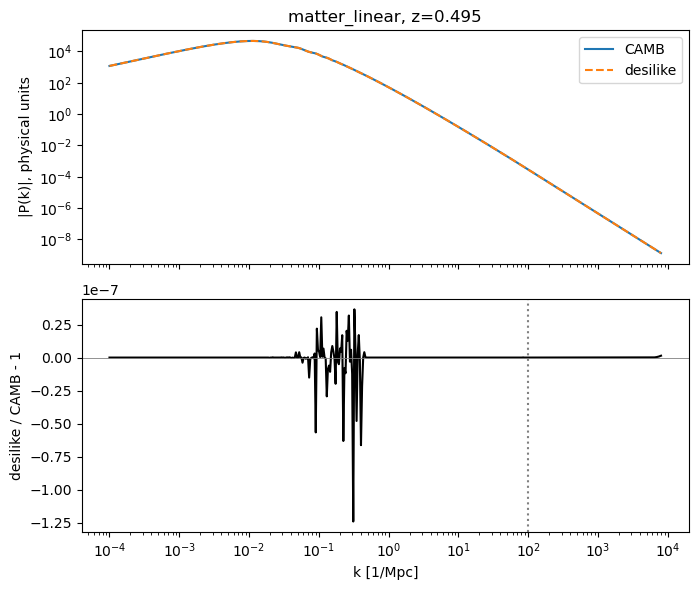

In [21]:
k = fiducial["k"]
iz = 2  # 改这里可以选择另一个已计算的 redshift
P_desilike, P_camb = fiducial["power"]["matter_linear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_linear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_linear.png", dpi=150)
plt.show()
plt.close(fig)


### matter_nonlinear

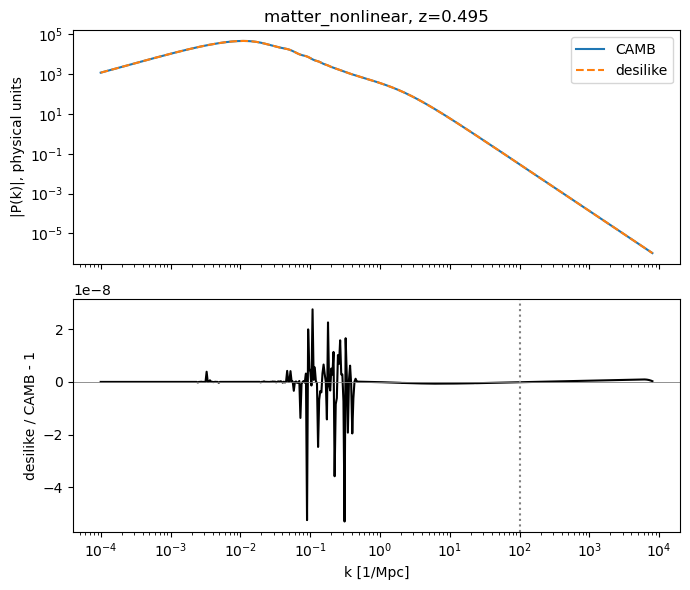

In [22]:
k = fiducial["k"]
iz = 2  # 改这里可以选择另一个已计算的 redshift
P_desilike, P_camb = fiducial["power"]["matter_nonlinear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_nonlinear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_nonlinear.png", dpi=150)
plt.show()
plt.close(fig)


### weyl_linear

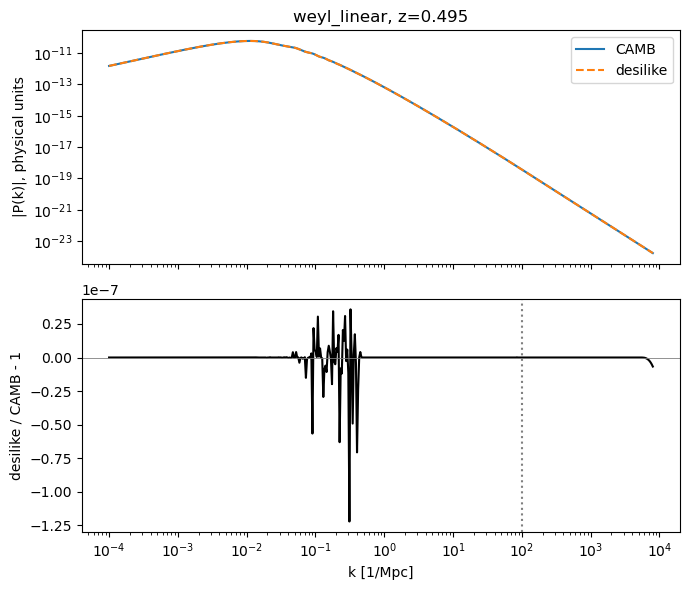

In [23]:
k = fiducial["k"]
iz = 2  # 改这里可以选择另一个已计算的 redshift
P_desilike, P_camb = fiducial["power"]["weyl_linear"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("weyl_linear" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_weyl_linear.png", dpi=150)
plt.show()
plt.close(fig)


### matter_weyl

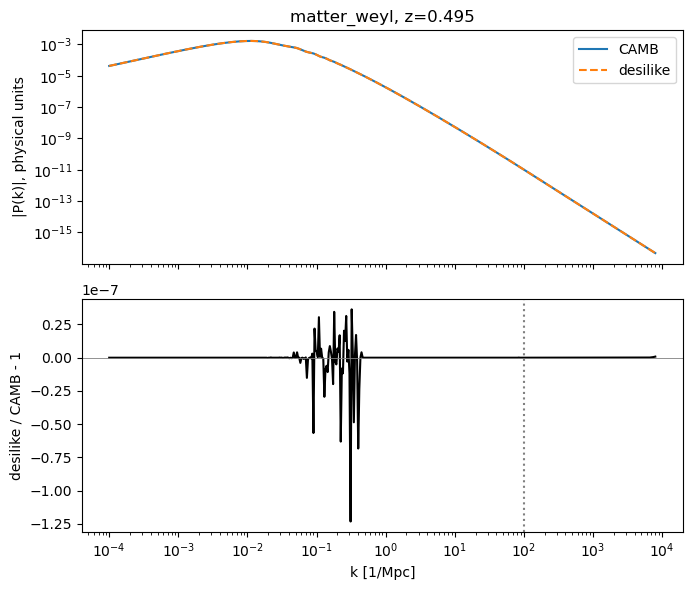

In [24]:
k = fiducial["k"]
iz = 2  # 改这里可以选择另一个已计算的 redshift
P_desilike, P_camb = fiducial["power"]["matter_weyl"]
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].loglog(k, np.abs(P_camb[iz]), label="CAMB")
axes[0].loglog(k, np.abs(P_desilike[iz]), "--", label="desilike")
axes[0].set_ylabel("|P(k)|, physical units")
axes[0].set_title("matter_weyl" + f", z={fiducial['z'][iz]:.3f}")
axes[0].legend()
axes[1].semilogx(k, P_desilike[iz] / P_camb[iz] - 1, color="black")
axes[1].axhline(0, color="gray", lw=0.6)
axes[1].axvline(100, color="gray", ls=":")
axes[1].set_xlabel("k [1/Mpc]")
axes[1].set_ylabel("desilike / CAMB - 1")
fig.tight_layout()
fig.savefig(OUT / "power_matter_weyl.png", dpi=150)
plt.show()
plt.close(fig)


## 4. 角功率谱 Cℓ

每格只对应一个 bin pair，上图为两套预测，下图为逐点相对差。每张图的代码都在其输出正上方。

### wtheta — Cl — Weyl 关闭：desilike / reference

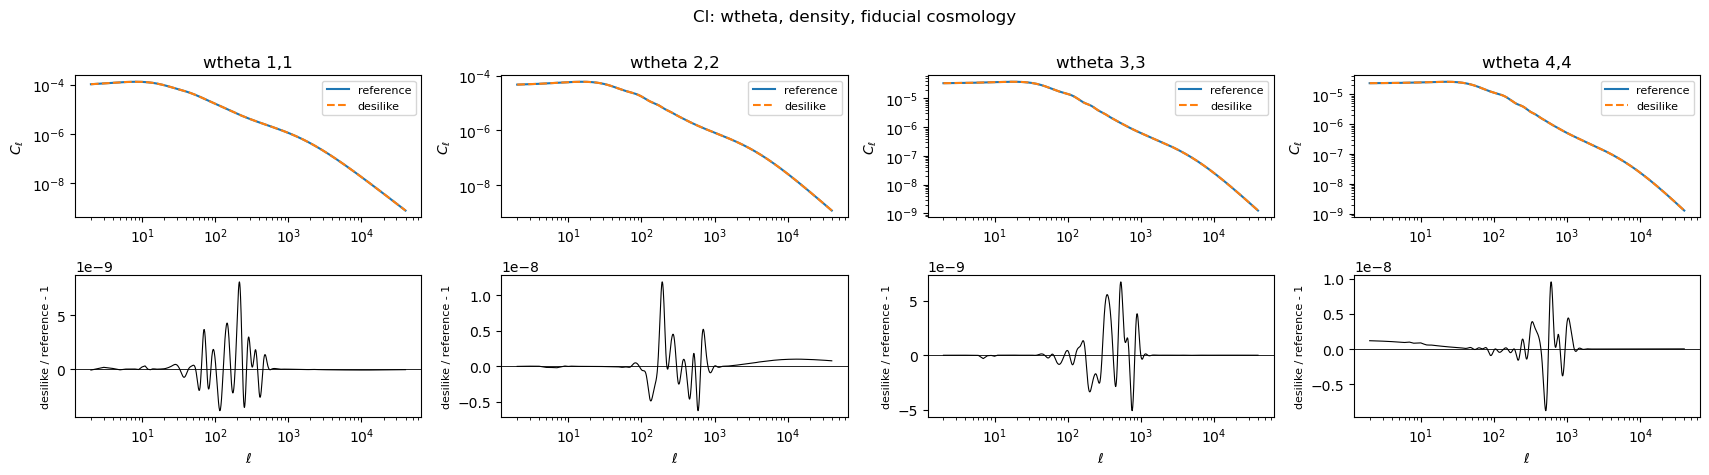

In [25]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_wtheta"]
second = fiducial["references"]["density"]["cls"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — Weyl 关闭：desilike / reference

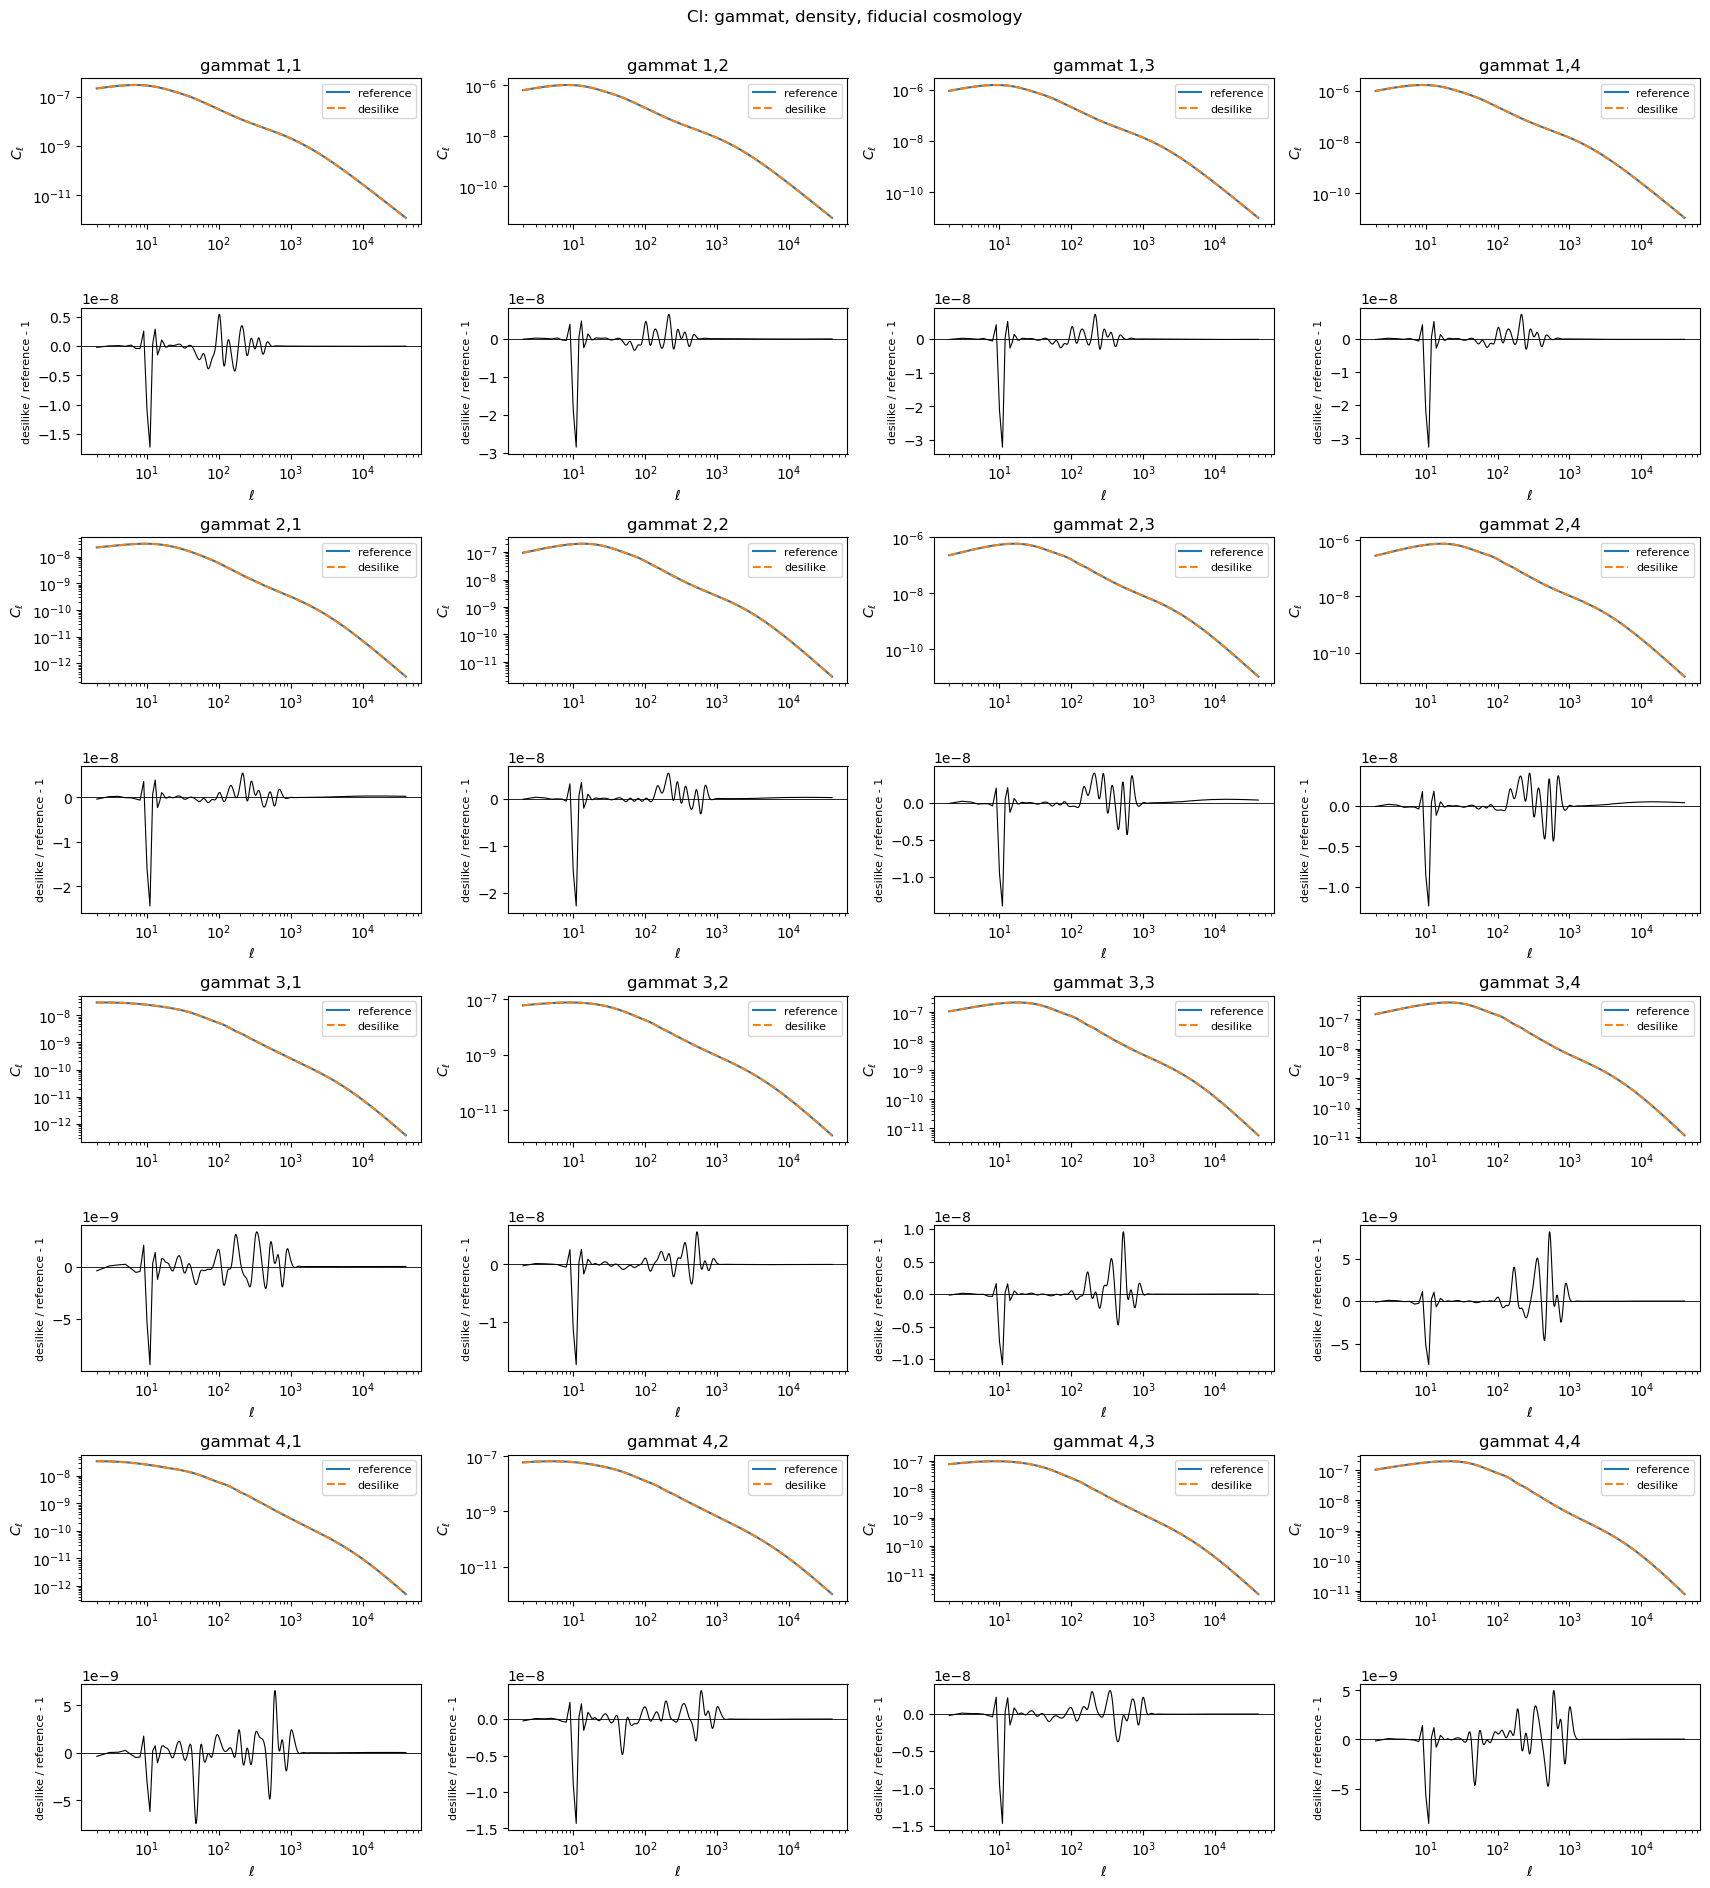

In [26]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_gammat"]
second = fiducial["references"]["density"]["cls"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — Weyl 关闭：desilike / reference

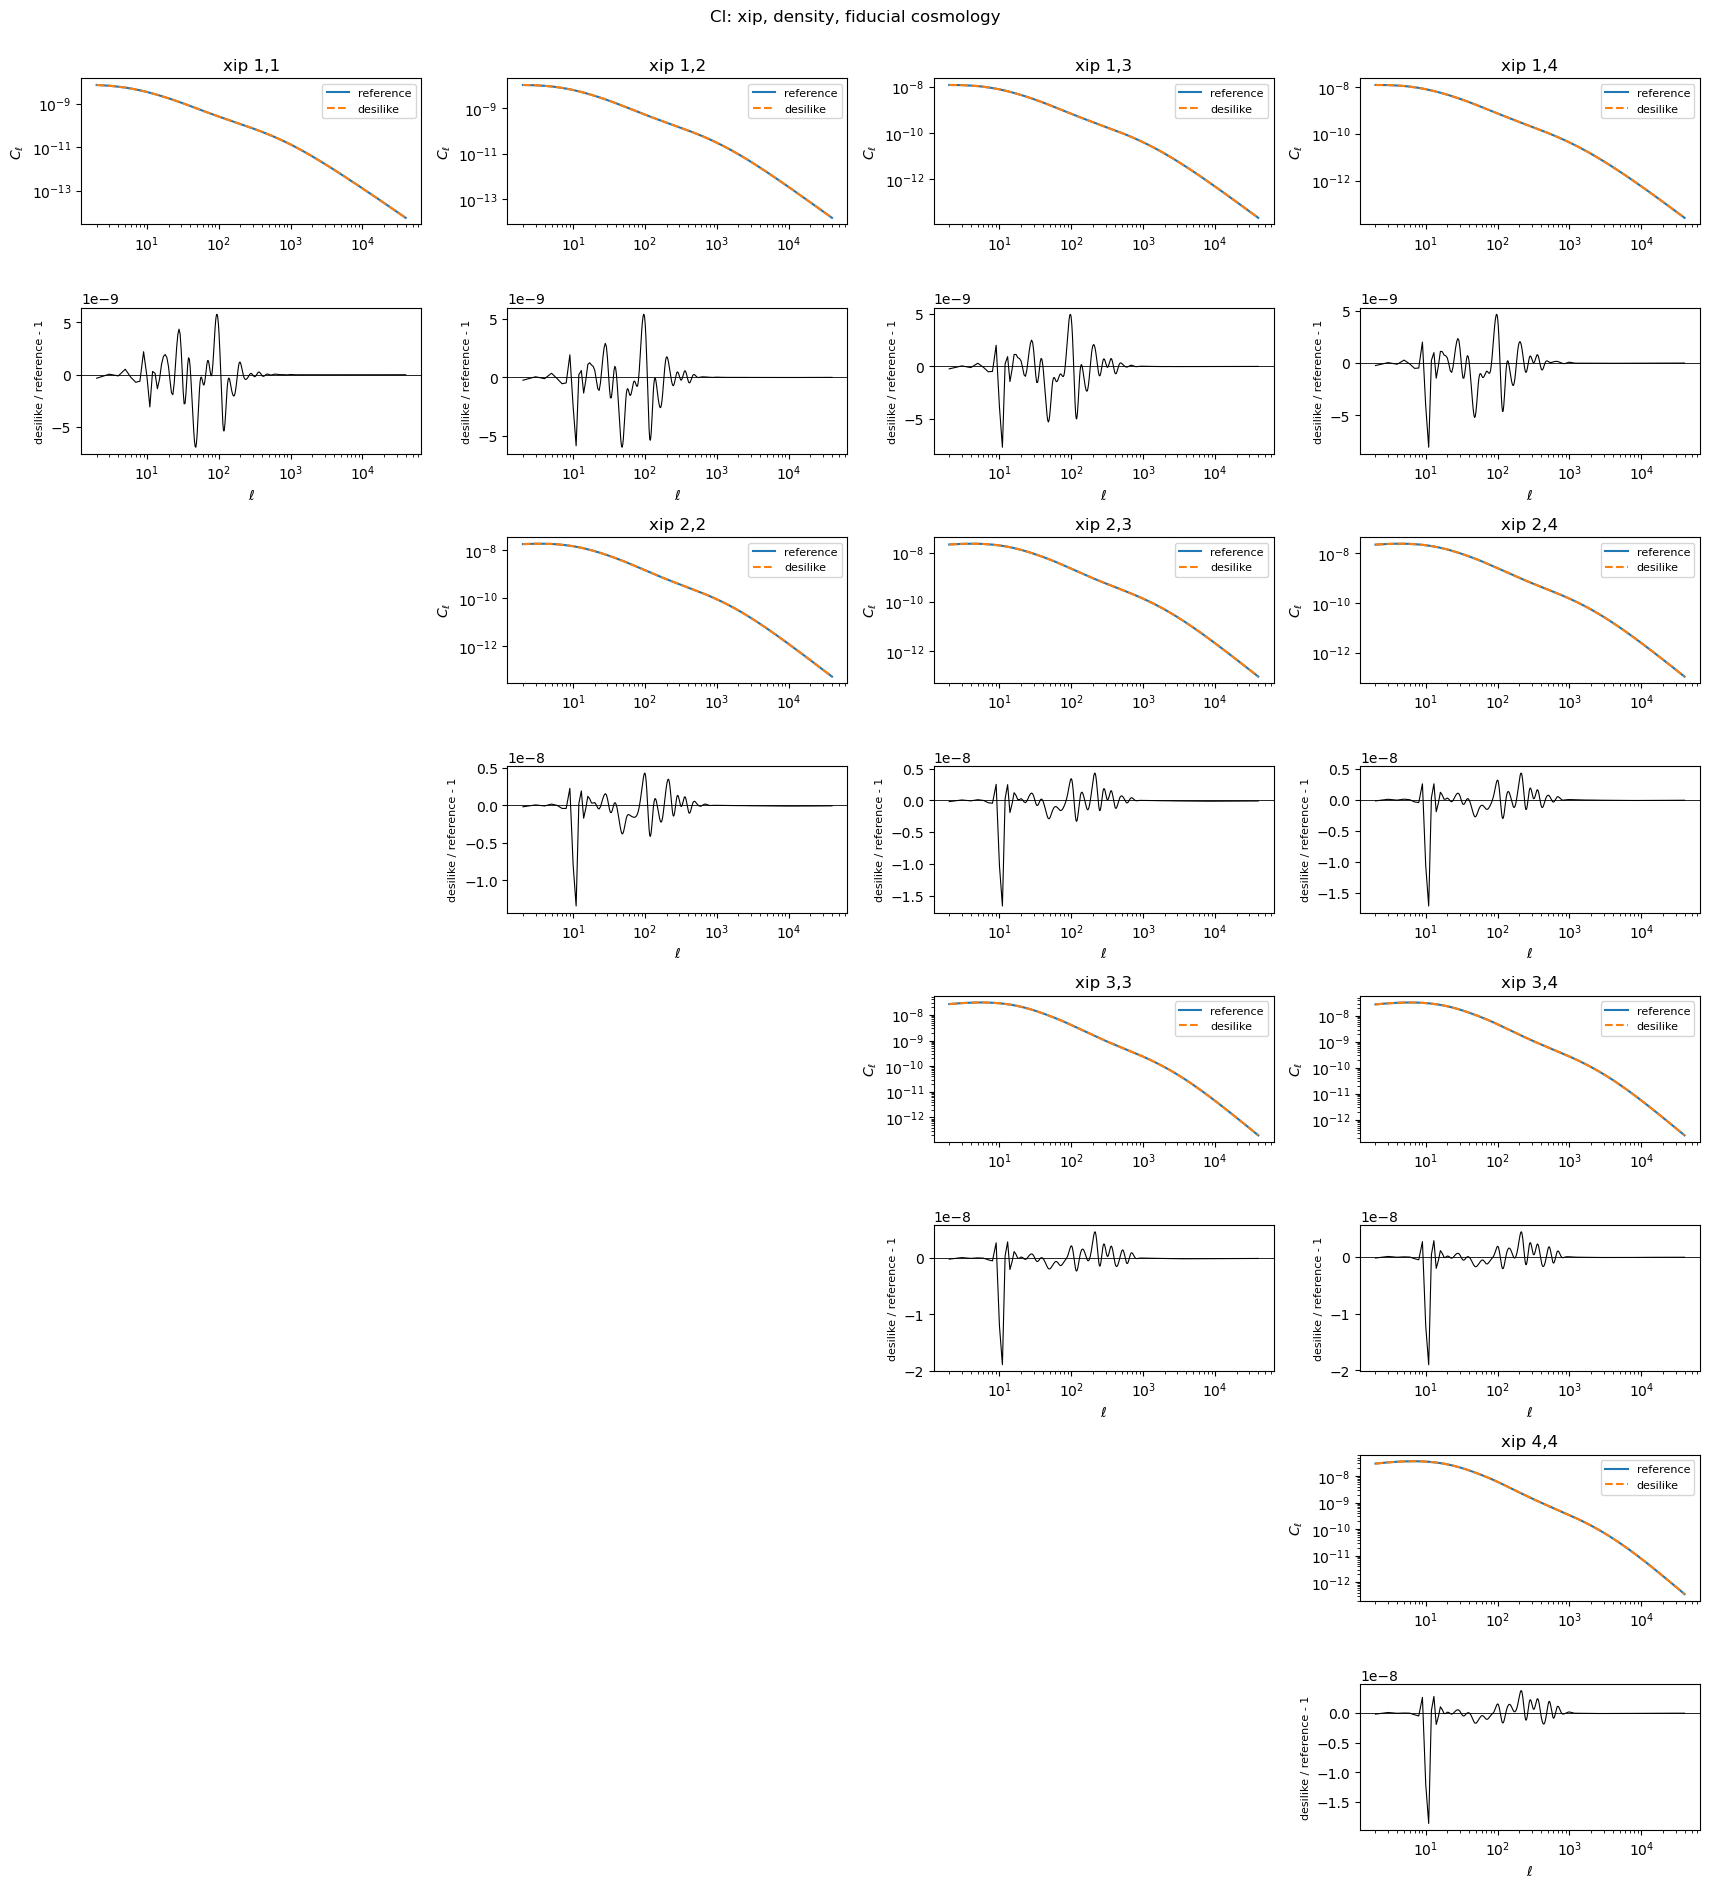

In [27]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_xip"]
second = fiducial["references"]["density"]["cls"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — Weyl 关闭：desilike / reference

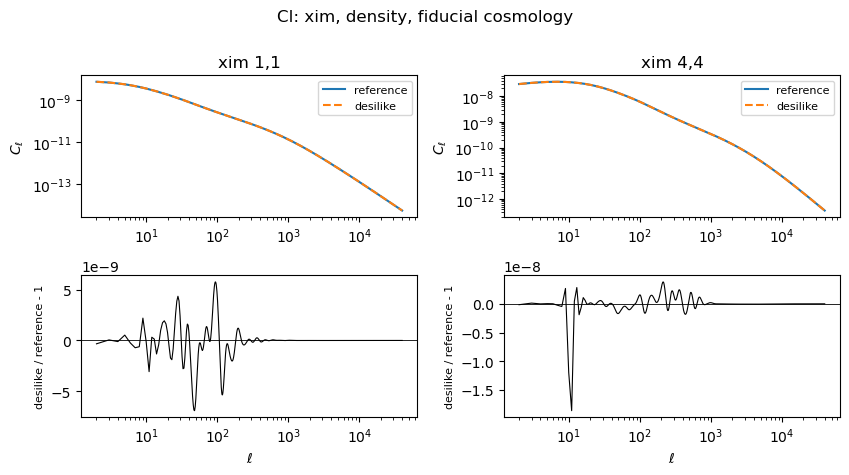

In [28]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["density"]["cl_xim"]
second = fiducial["references"]["density"]["cls"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_density_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — Cl — Weyl 开启：desilike / reference

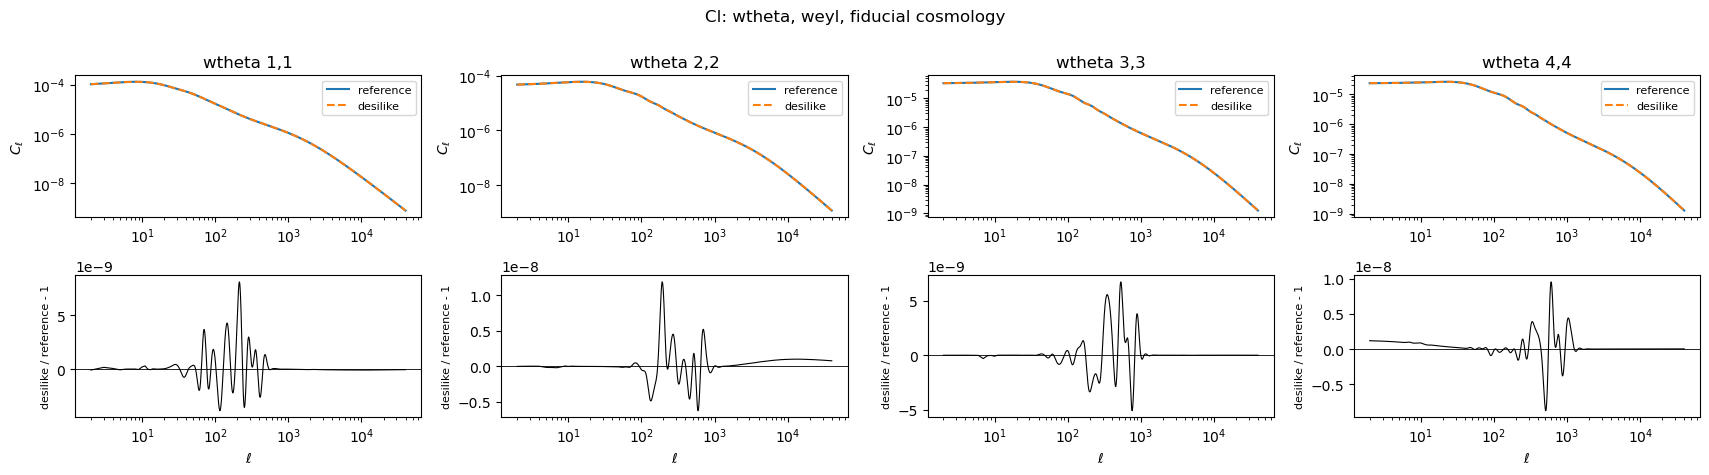

In [29]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_wtheta"]
second = fiducial["references"]["weyl"]["cls"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — Weyl 开启：desilike / reference

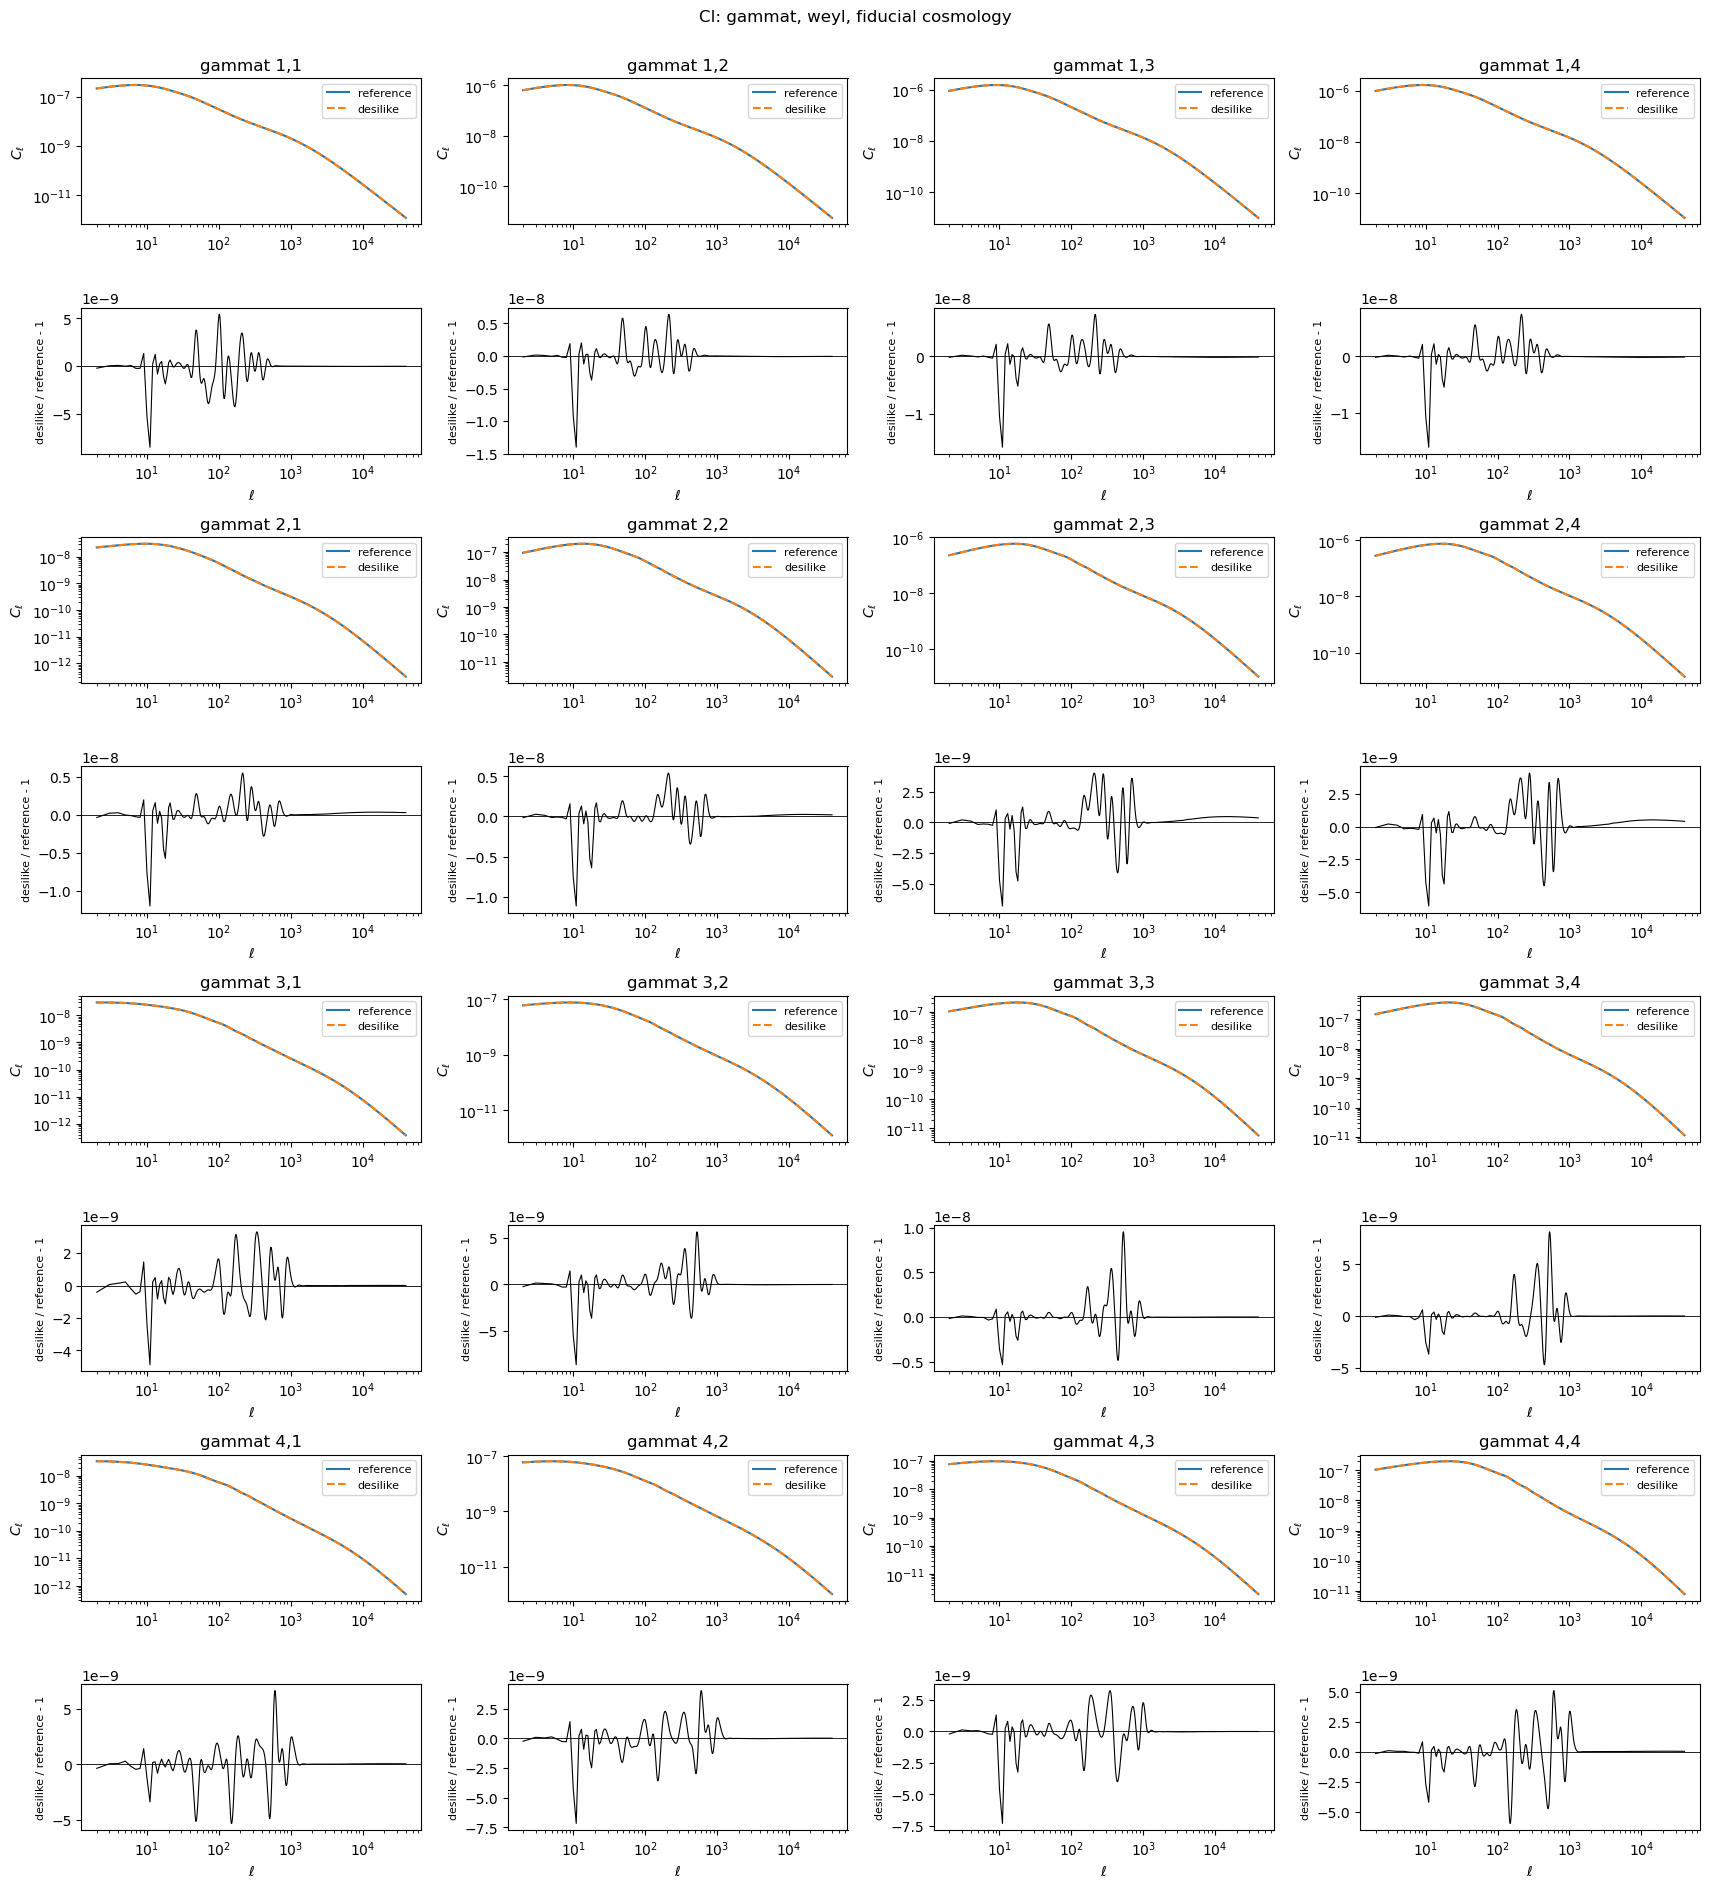

In [30]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_gammat"]
second = fiducial["references"]["weyl"]["cls"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — Weyl 开启：desilike / reference

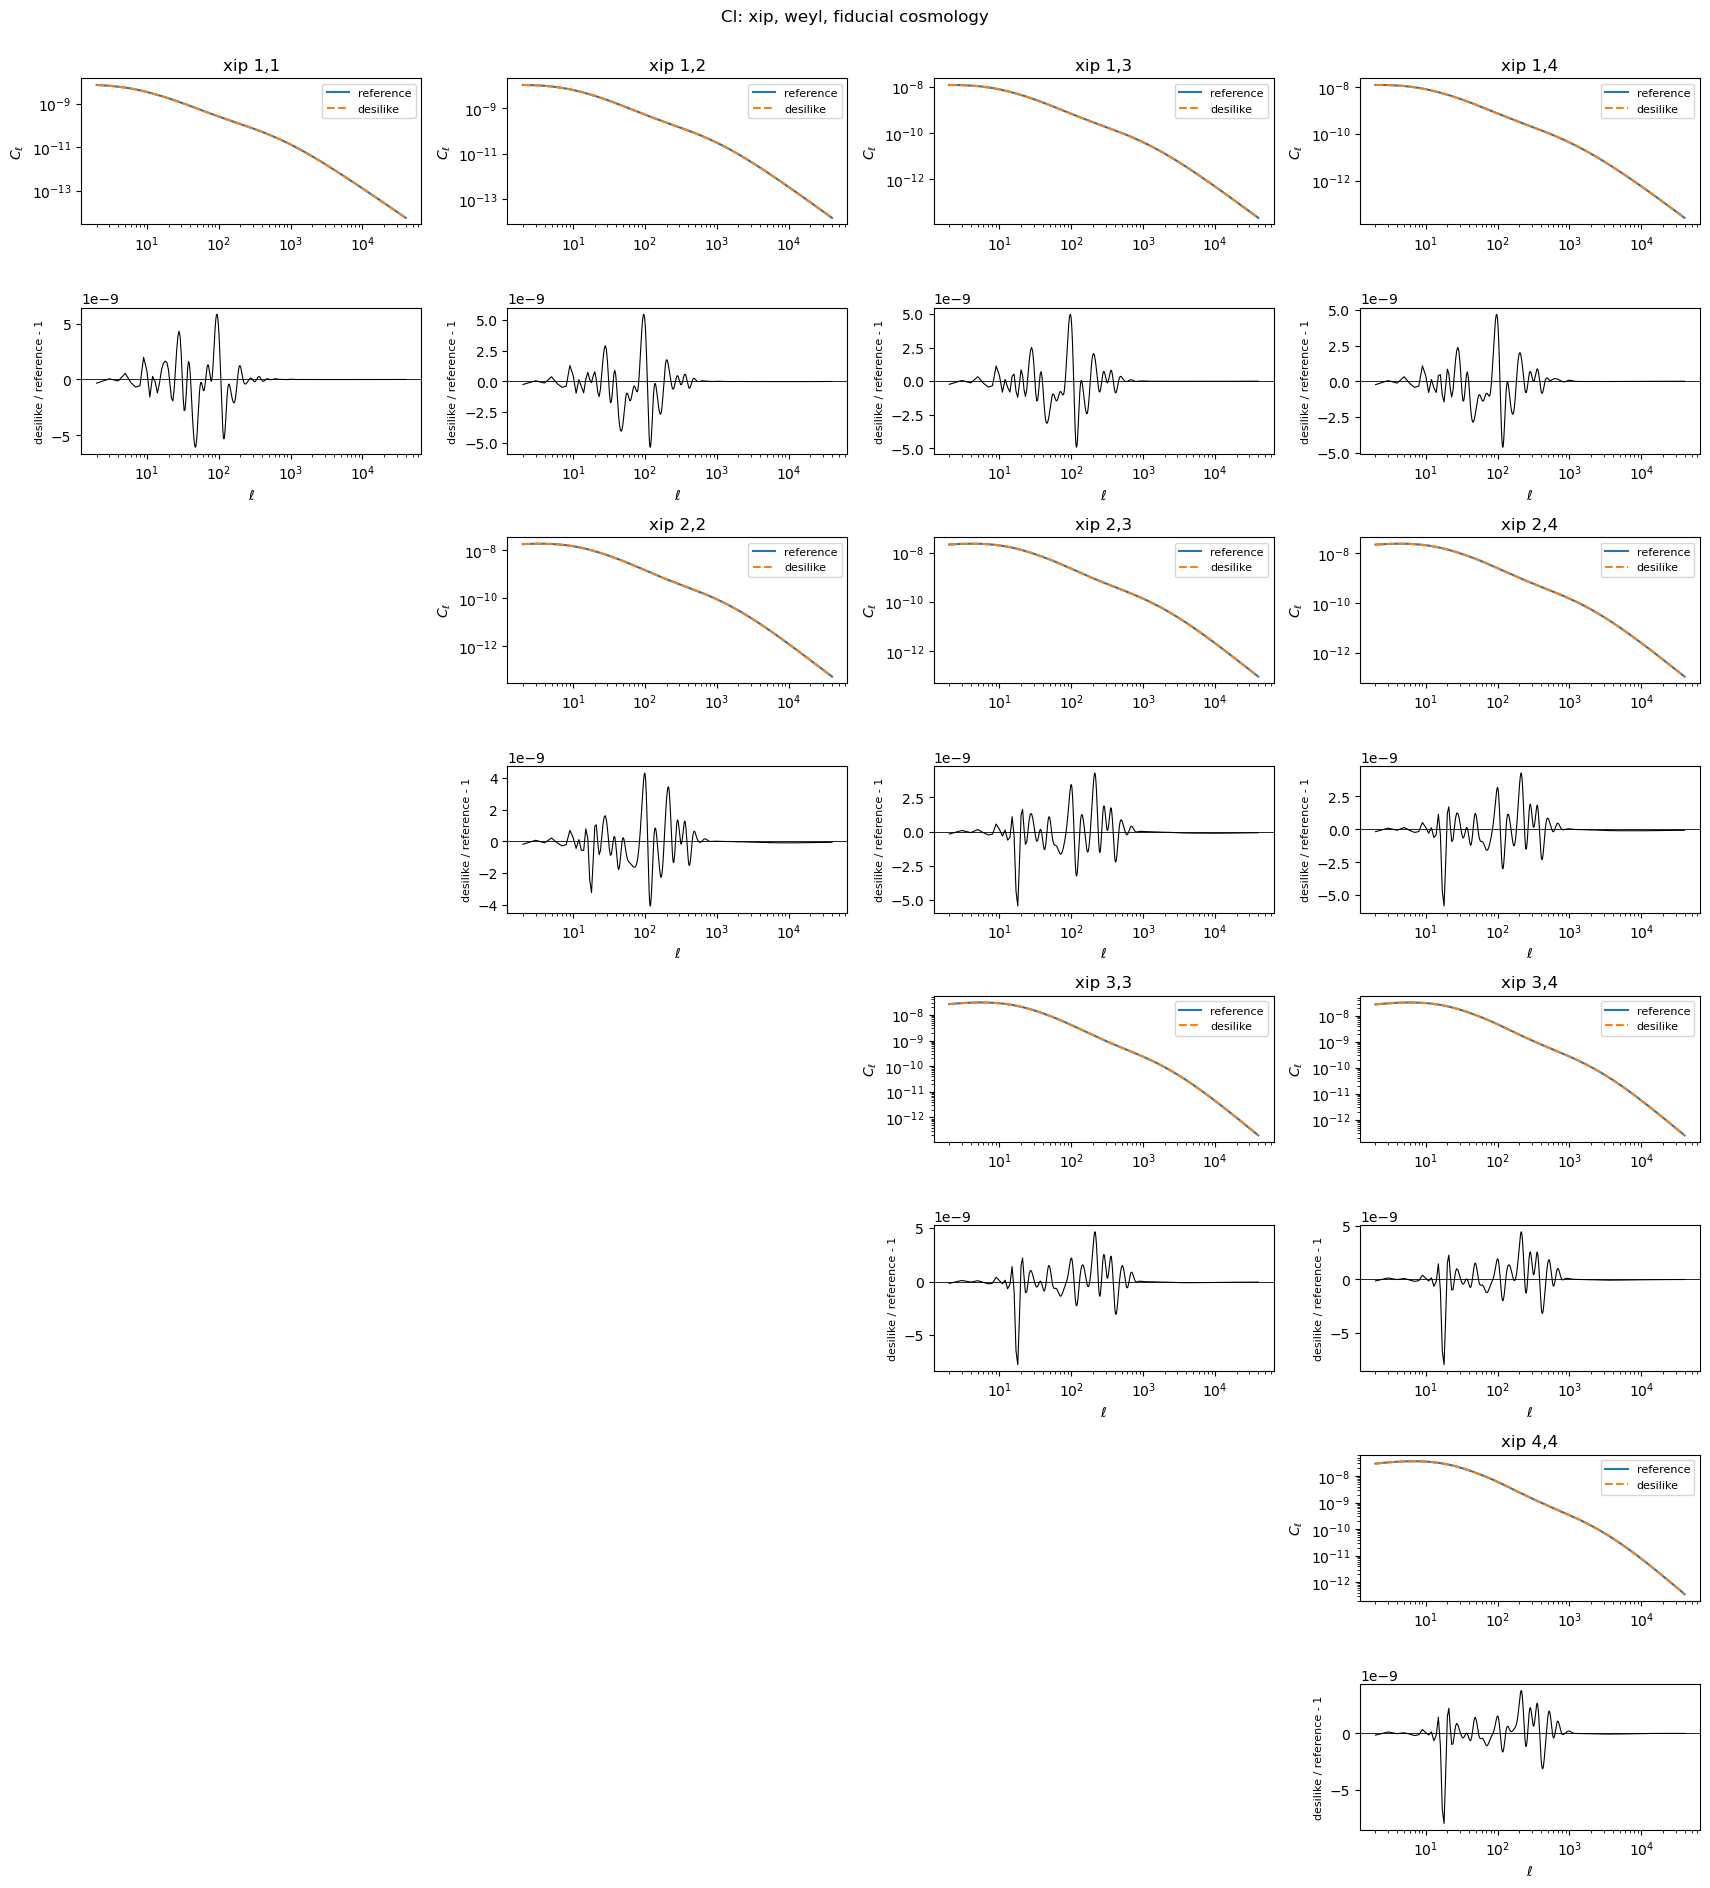

In [31]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xip"]
second = fiducial["references"]["weyl"]["cls"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — Weyl 开启：desilike / reference

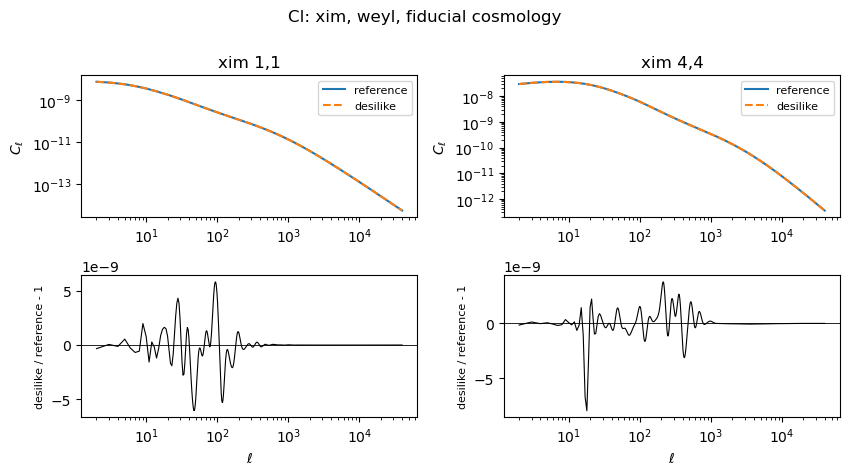

In [32]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xim"]
second = fiducial["references"]["weyl"]["cls"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5. 关联函数

全部实际使用的 bin pair；每条曲线显示 20 个角度点。likelihood 在此基础上应用角尺度 cuts。

### wtheta — xi — Weyl 关闭：desilike / reference

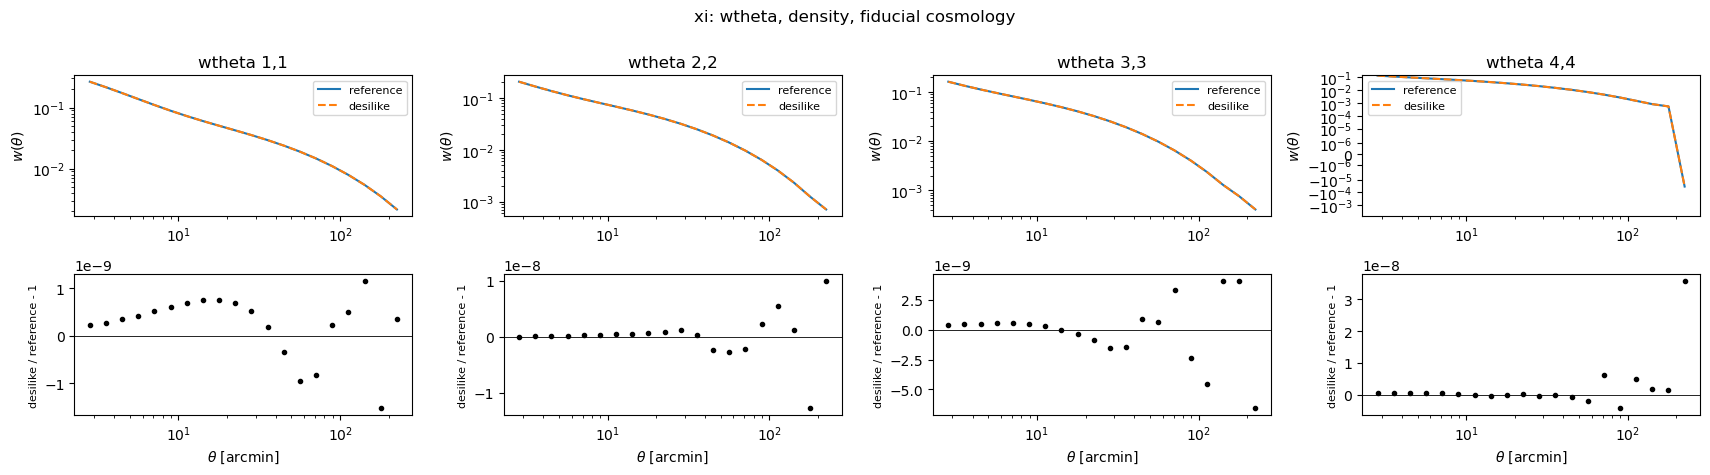

In [33]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["wtheta"]
second = fiducial["references"]["density"]["corrs"][3]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — Weyl 关闭：desilike / reference

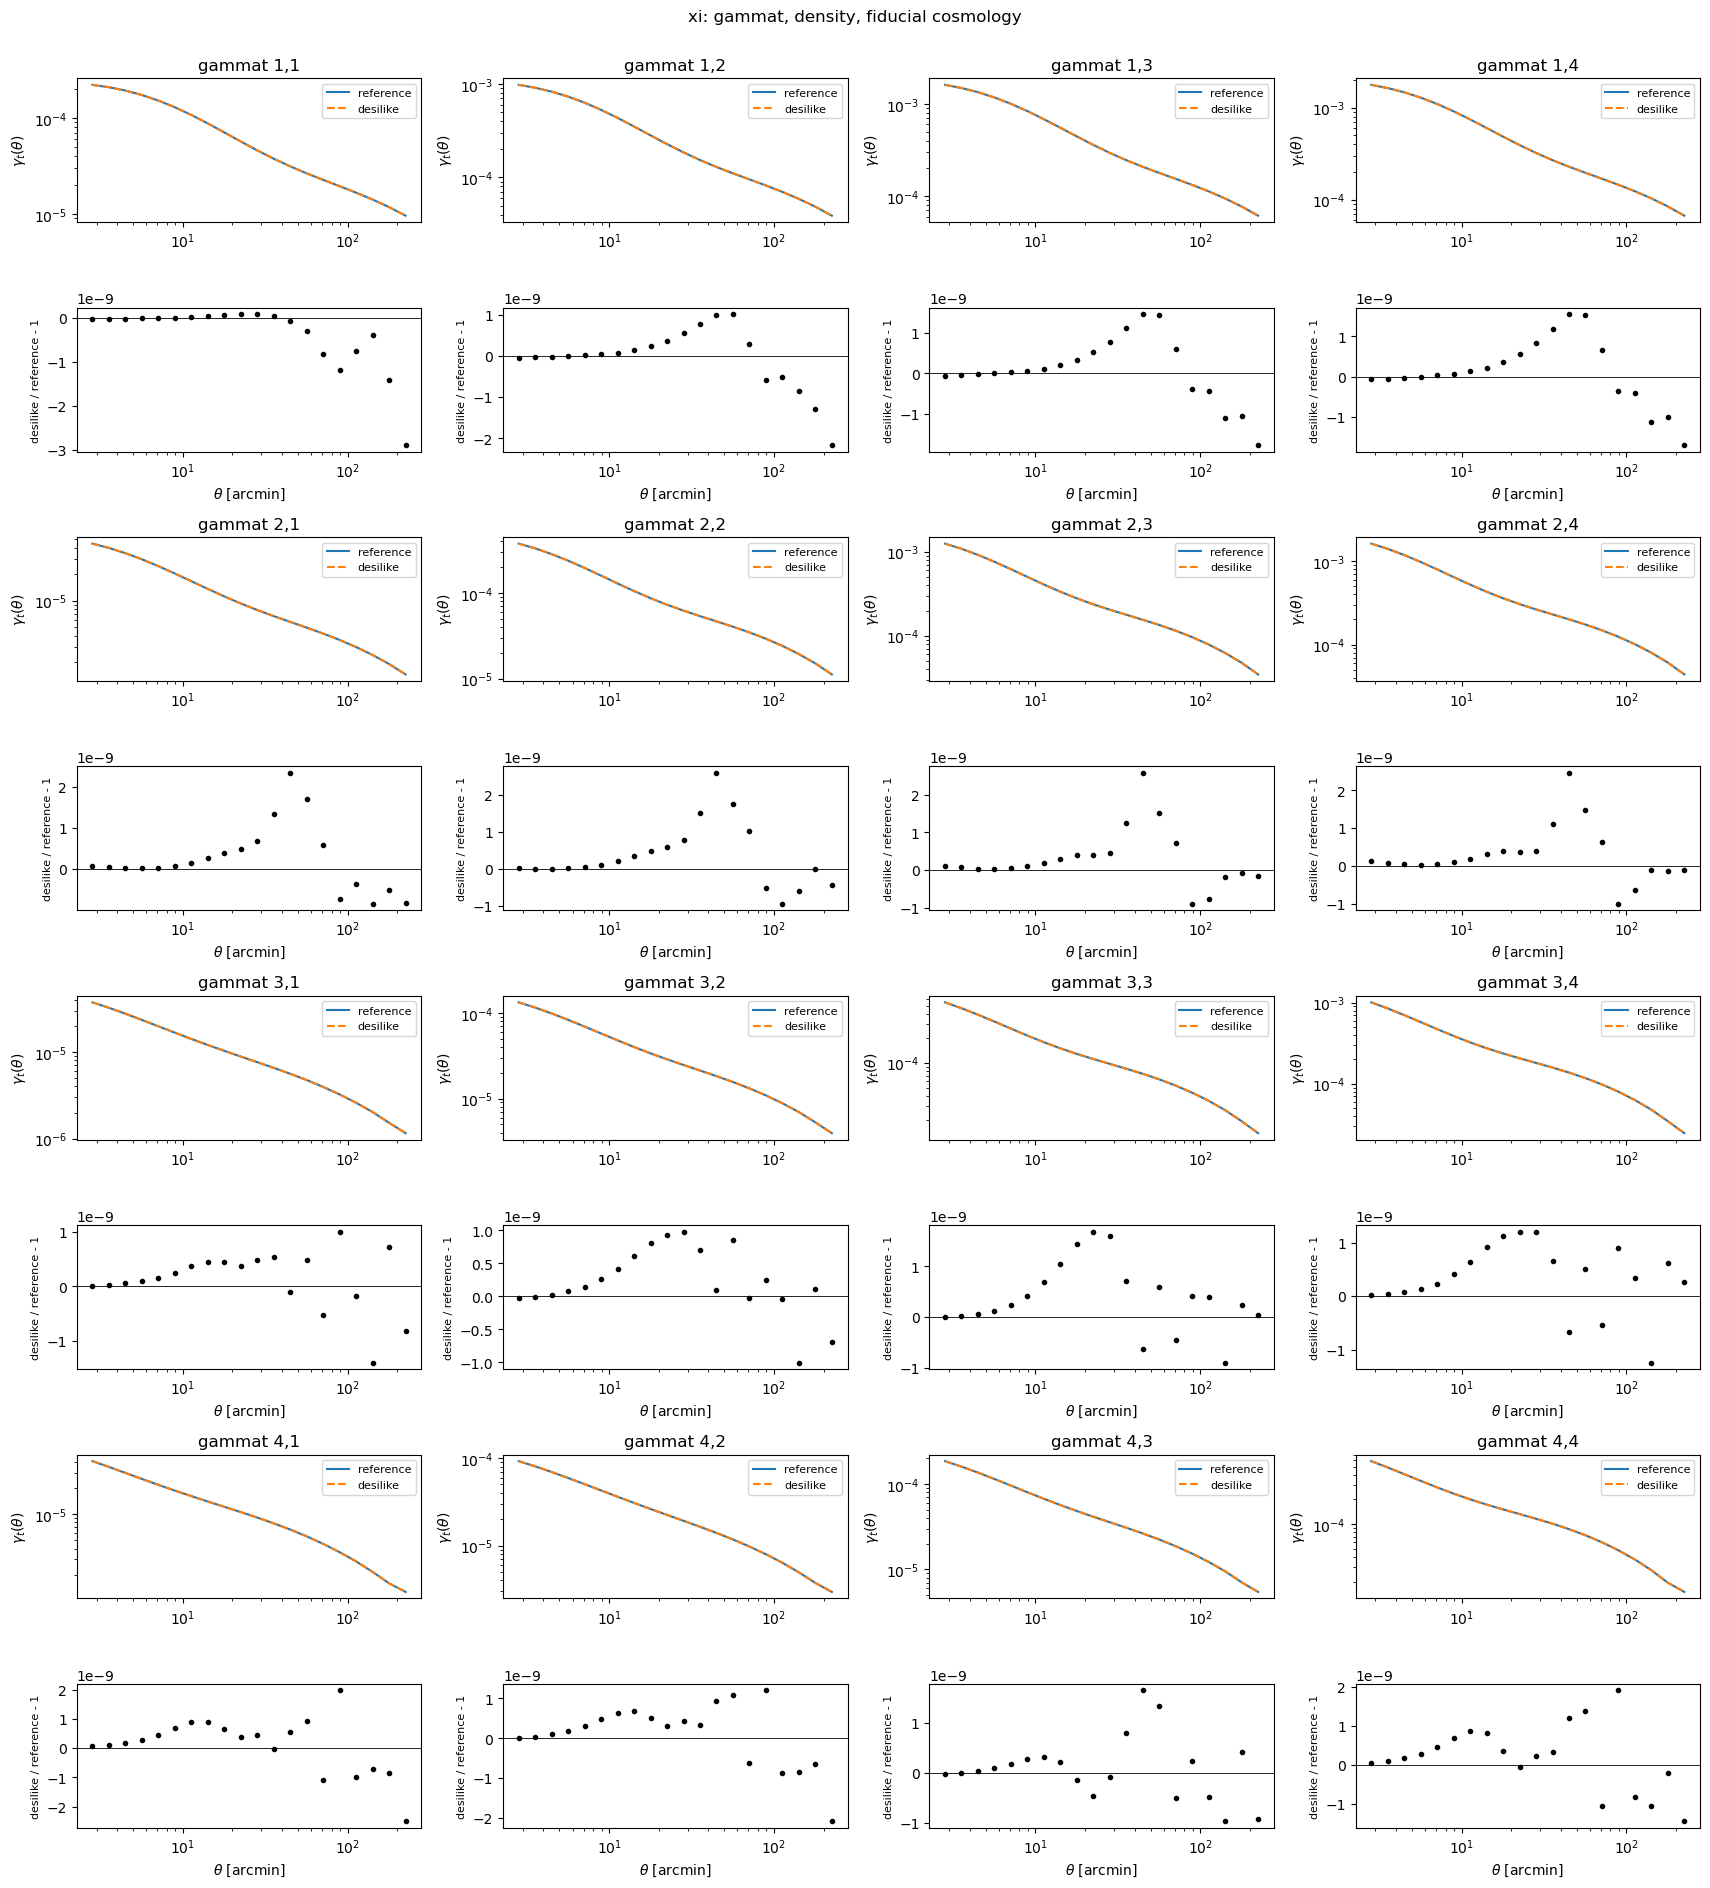

In [34]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["gammat"]
second = fiducial["references"]["density"]["corrs"][2]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — Weyl 关闭：desilike / reference

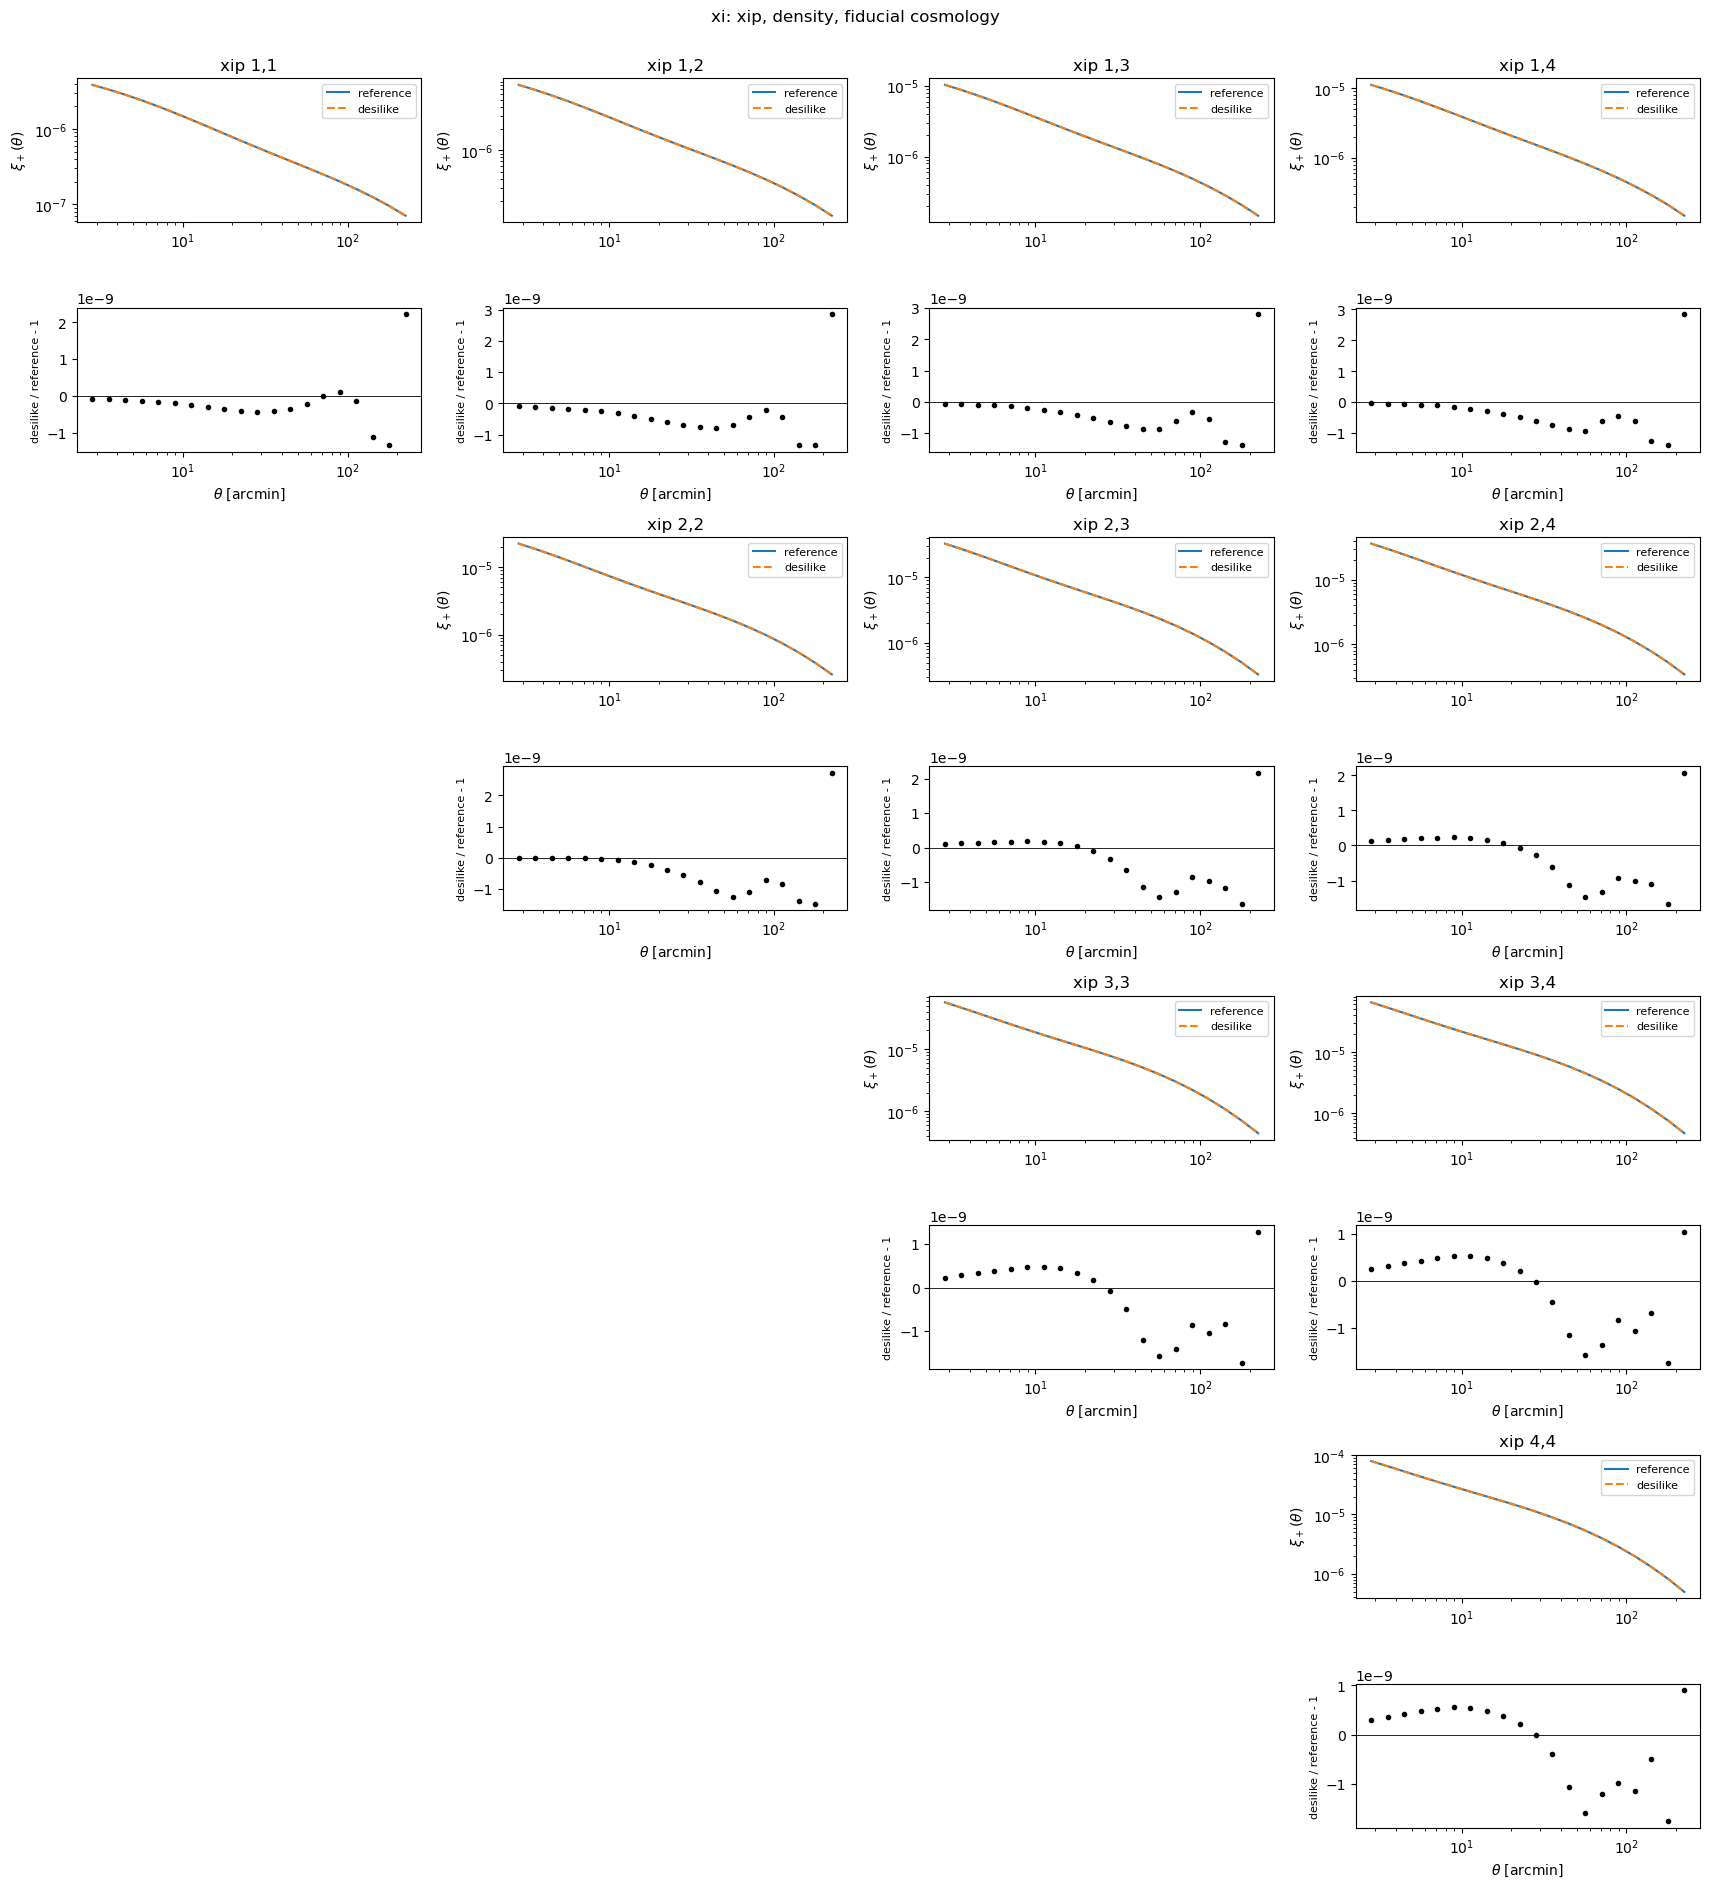

In [35]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["xip"]
second = fiducial["references"]["density"]["corrs"][0]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — Weyl 关闭：desilike / reference

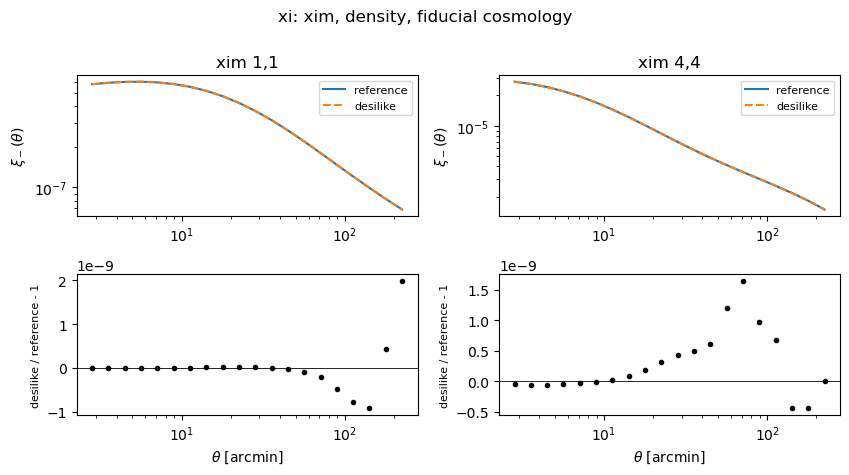

In [36]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["density"]["xim"]
second = fiducial["references"]["density"]["corrs"][1]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, density, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_density_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — xi — Weyl 开启：desilike / reference

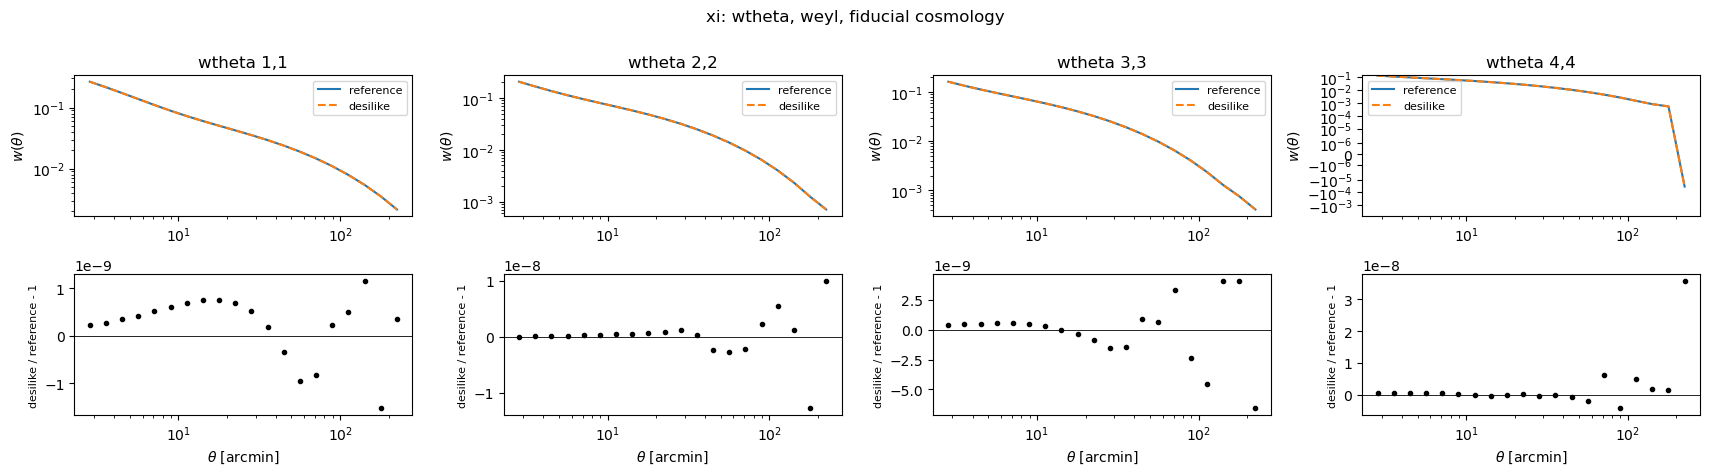

In [37]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["wtheta"]
second = fiducial["references"]["weyl"]["corrs"][3]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — Weyl 开启：desilike / reference

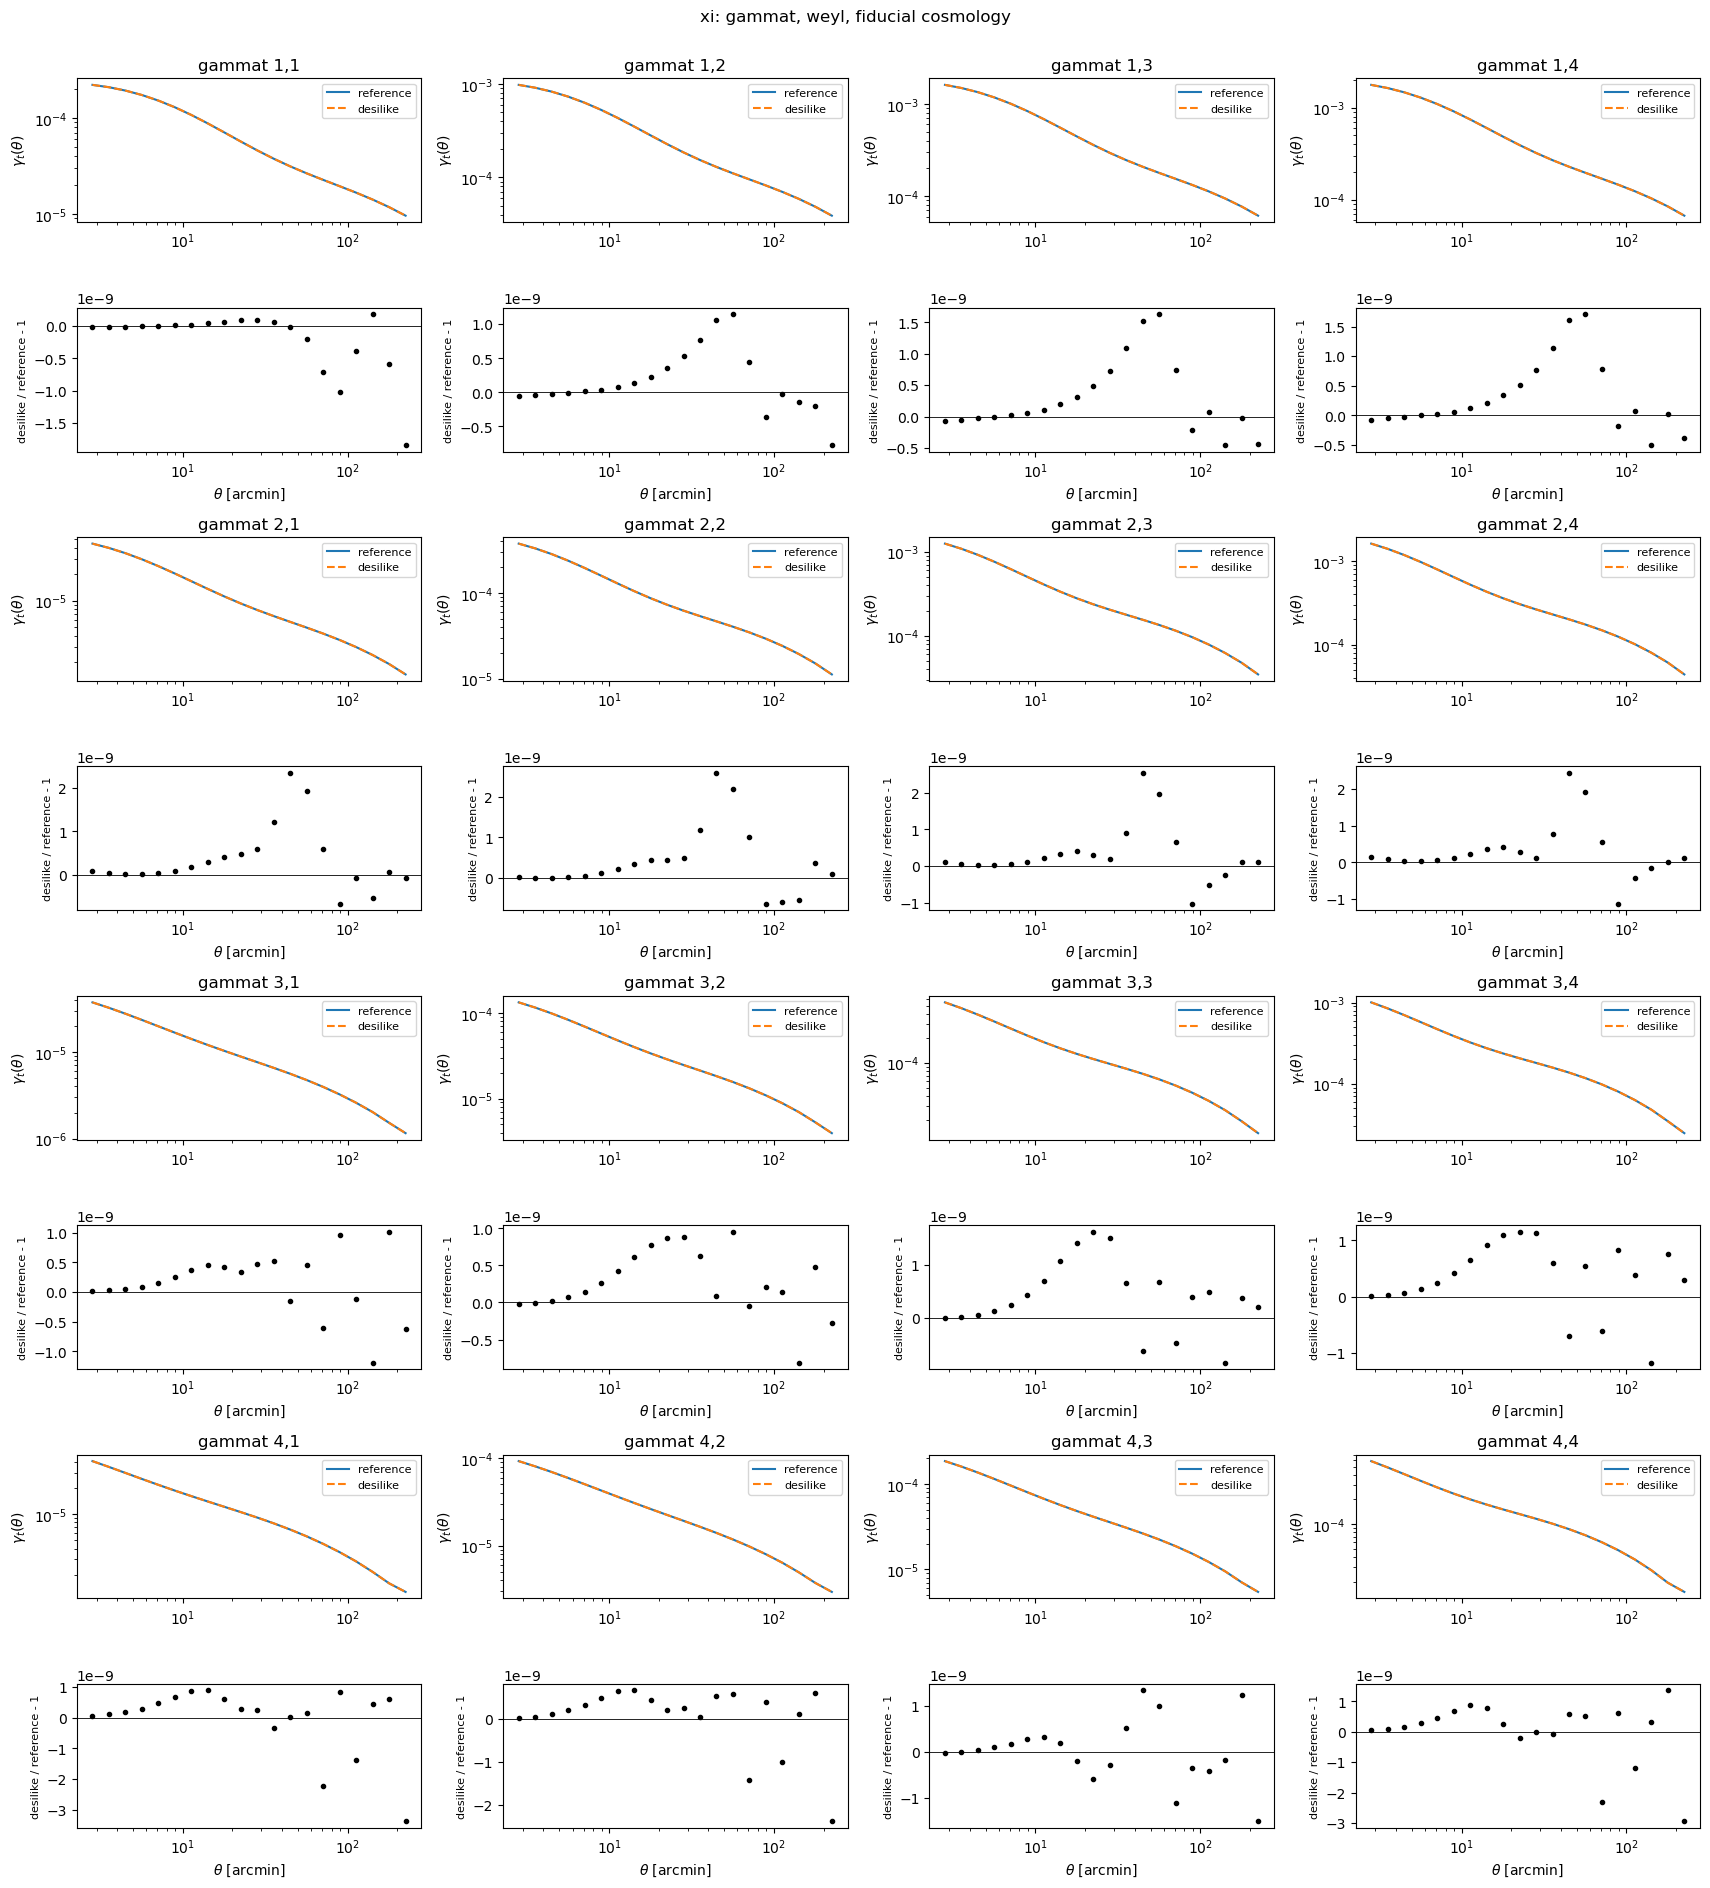

In [38]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["gammat"]
second = fiducial["references"]["weyl"]["corrs"][2]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — Weyl 开启：desilike / reference

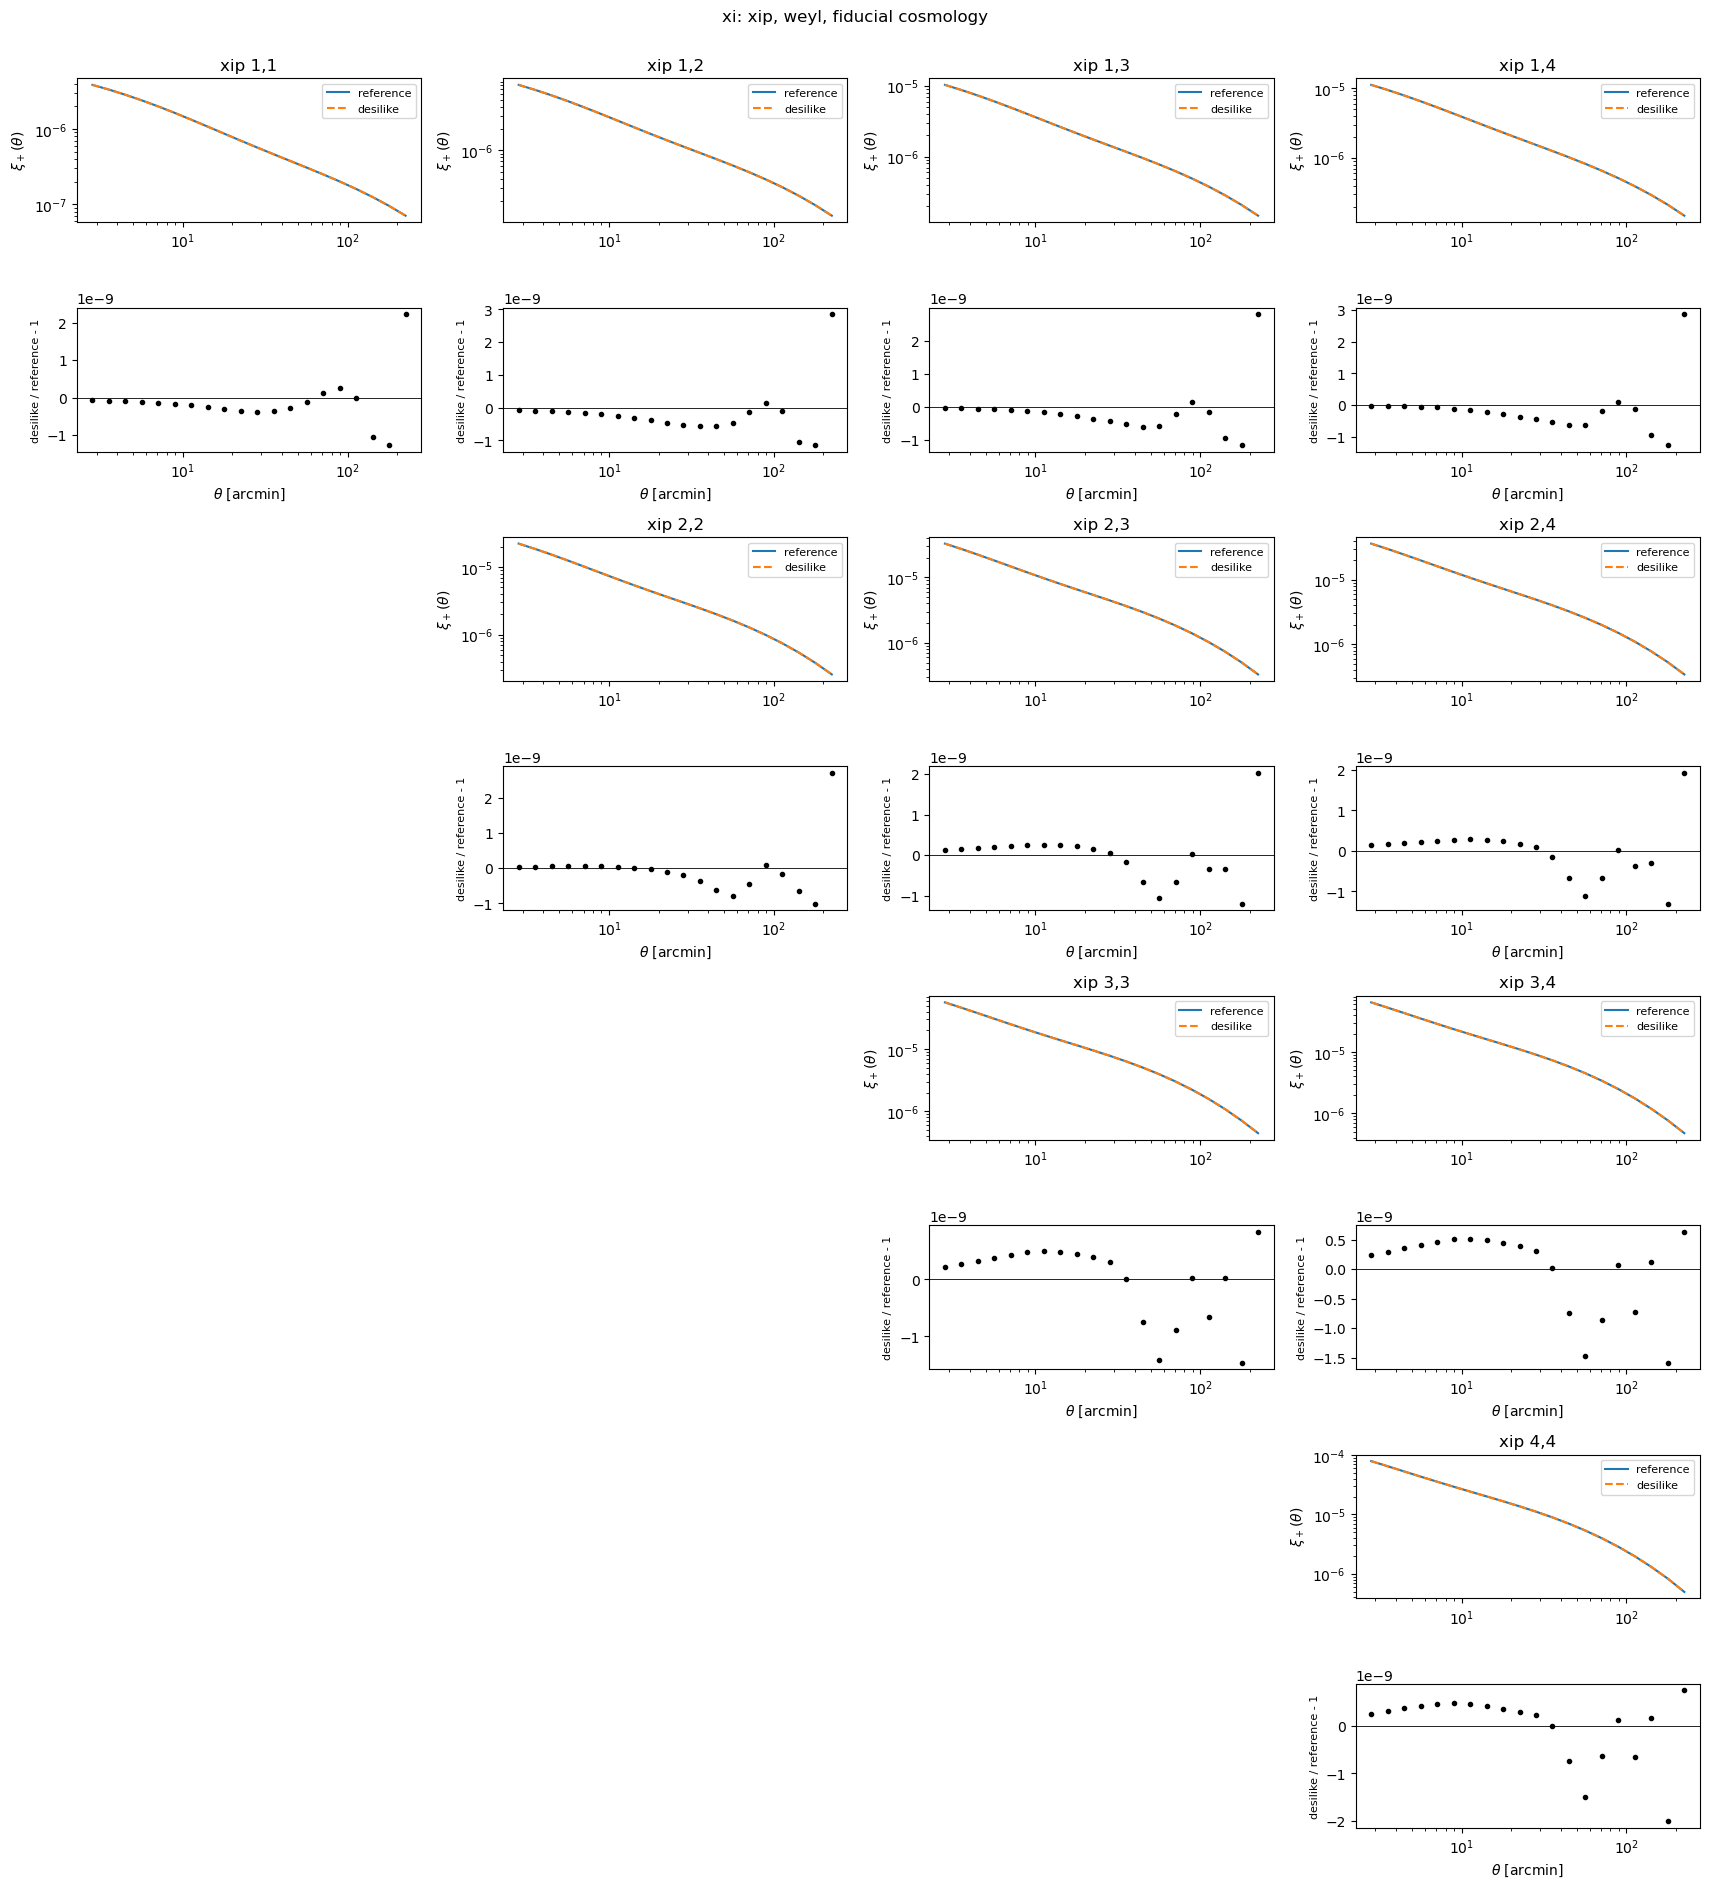

In [39]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xip"]
second = fiducial["references"]["weyl"]["corrs"][0]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — Weyl 开启：desilike / reference

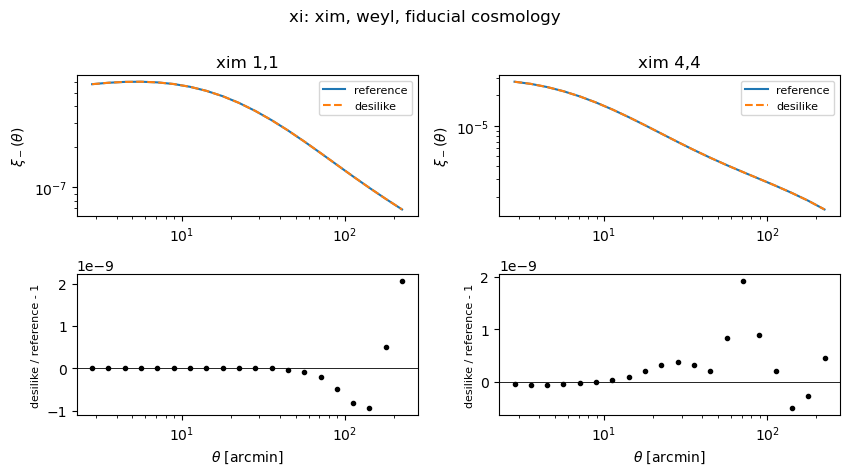

In [40]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xim"]
second = fiducial["references"]["weyl"]["corrs"][1]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="reference")
    top.plot(x[mask], a[mask], "--", label="desilike")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike / reference - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, weyl, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 6. Weyl 开 / 关

沿用同样的逐 bin-pair 布局；下图为 Weyl / density − 1。

### wtheta — Cl — desilike：Weyl 开 / 关

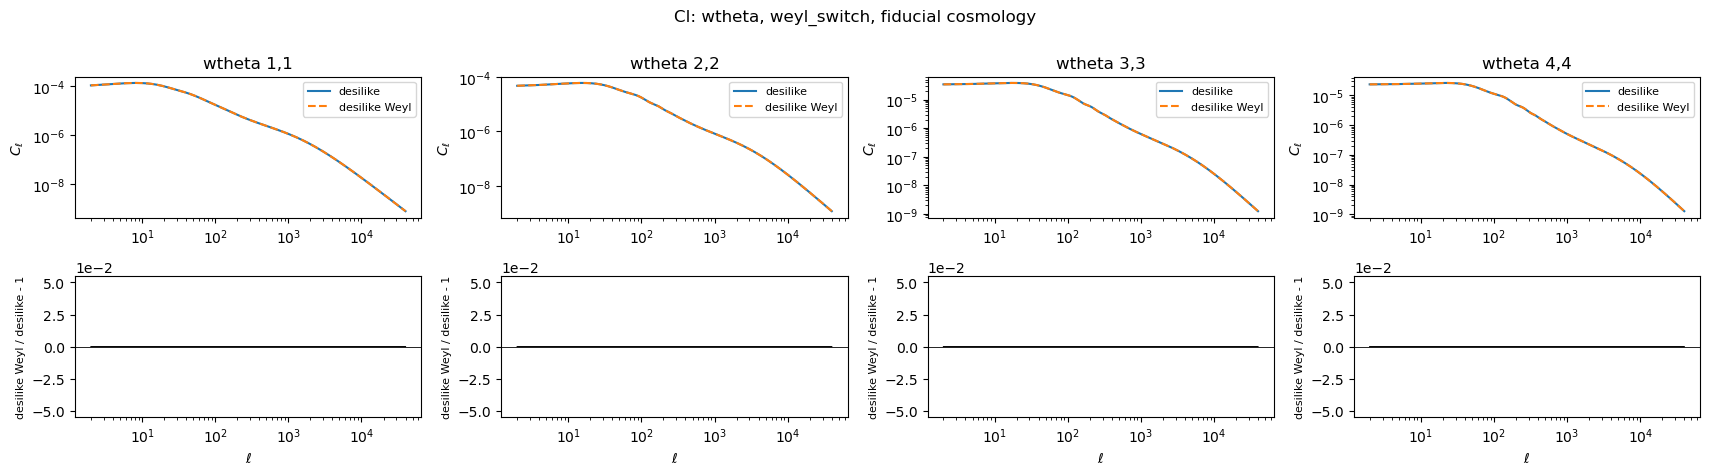

In [41]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_wtheta"]
second = fiducial["predictions"]["density"]["cl_wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: wtheta, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — Cl — desilike：Weyl 开 / 关

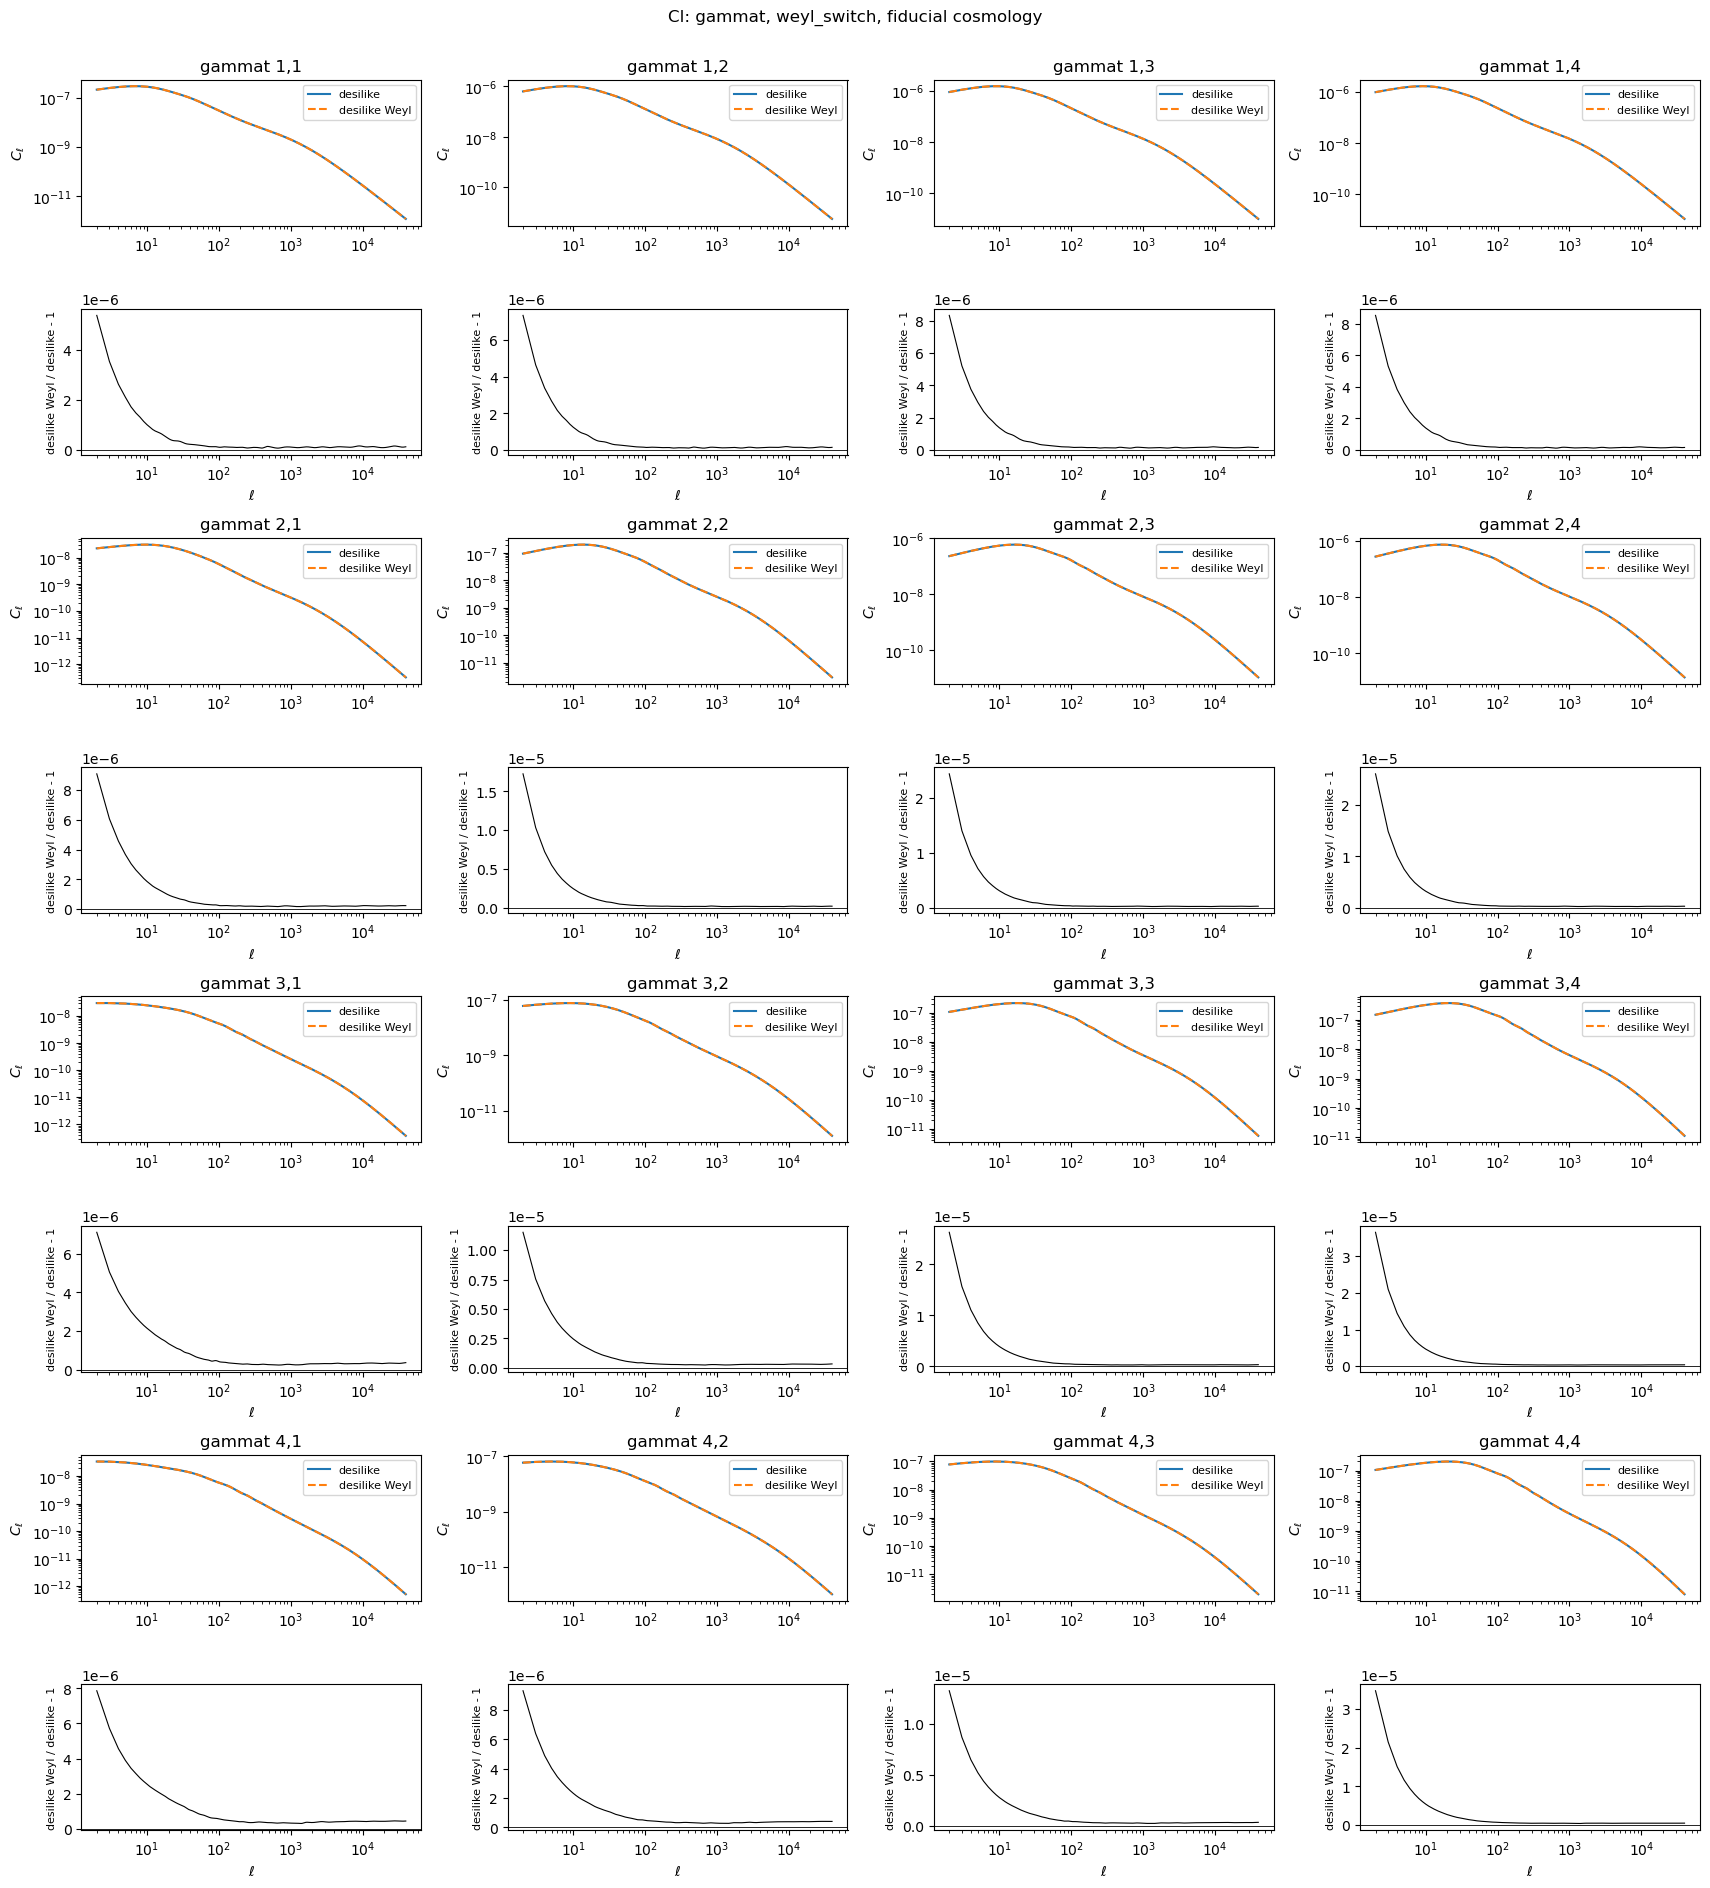

In [42]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_gammat"]
second = fiducial["predictions"]["density"]["cl_gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: gammat, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — Cl — desilike：Weyl 开 / 关

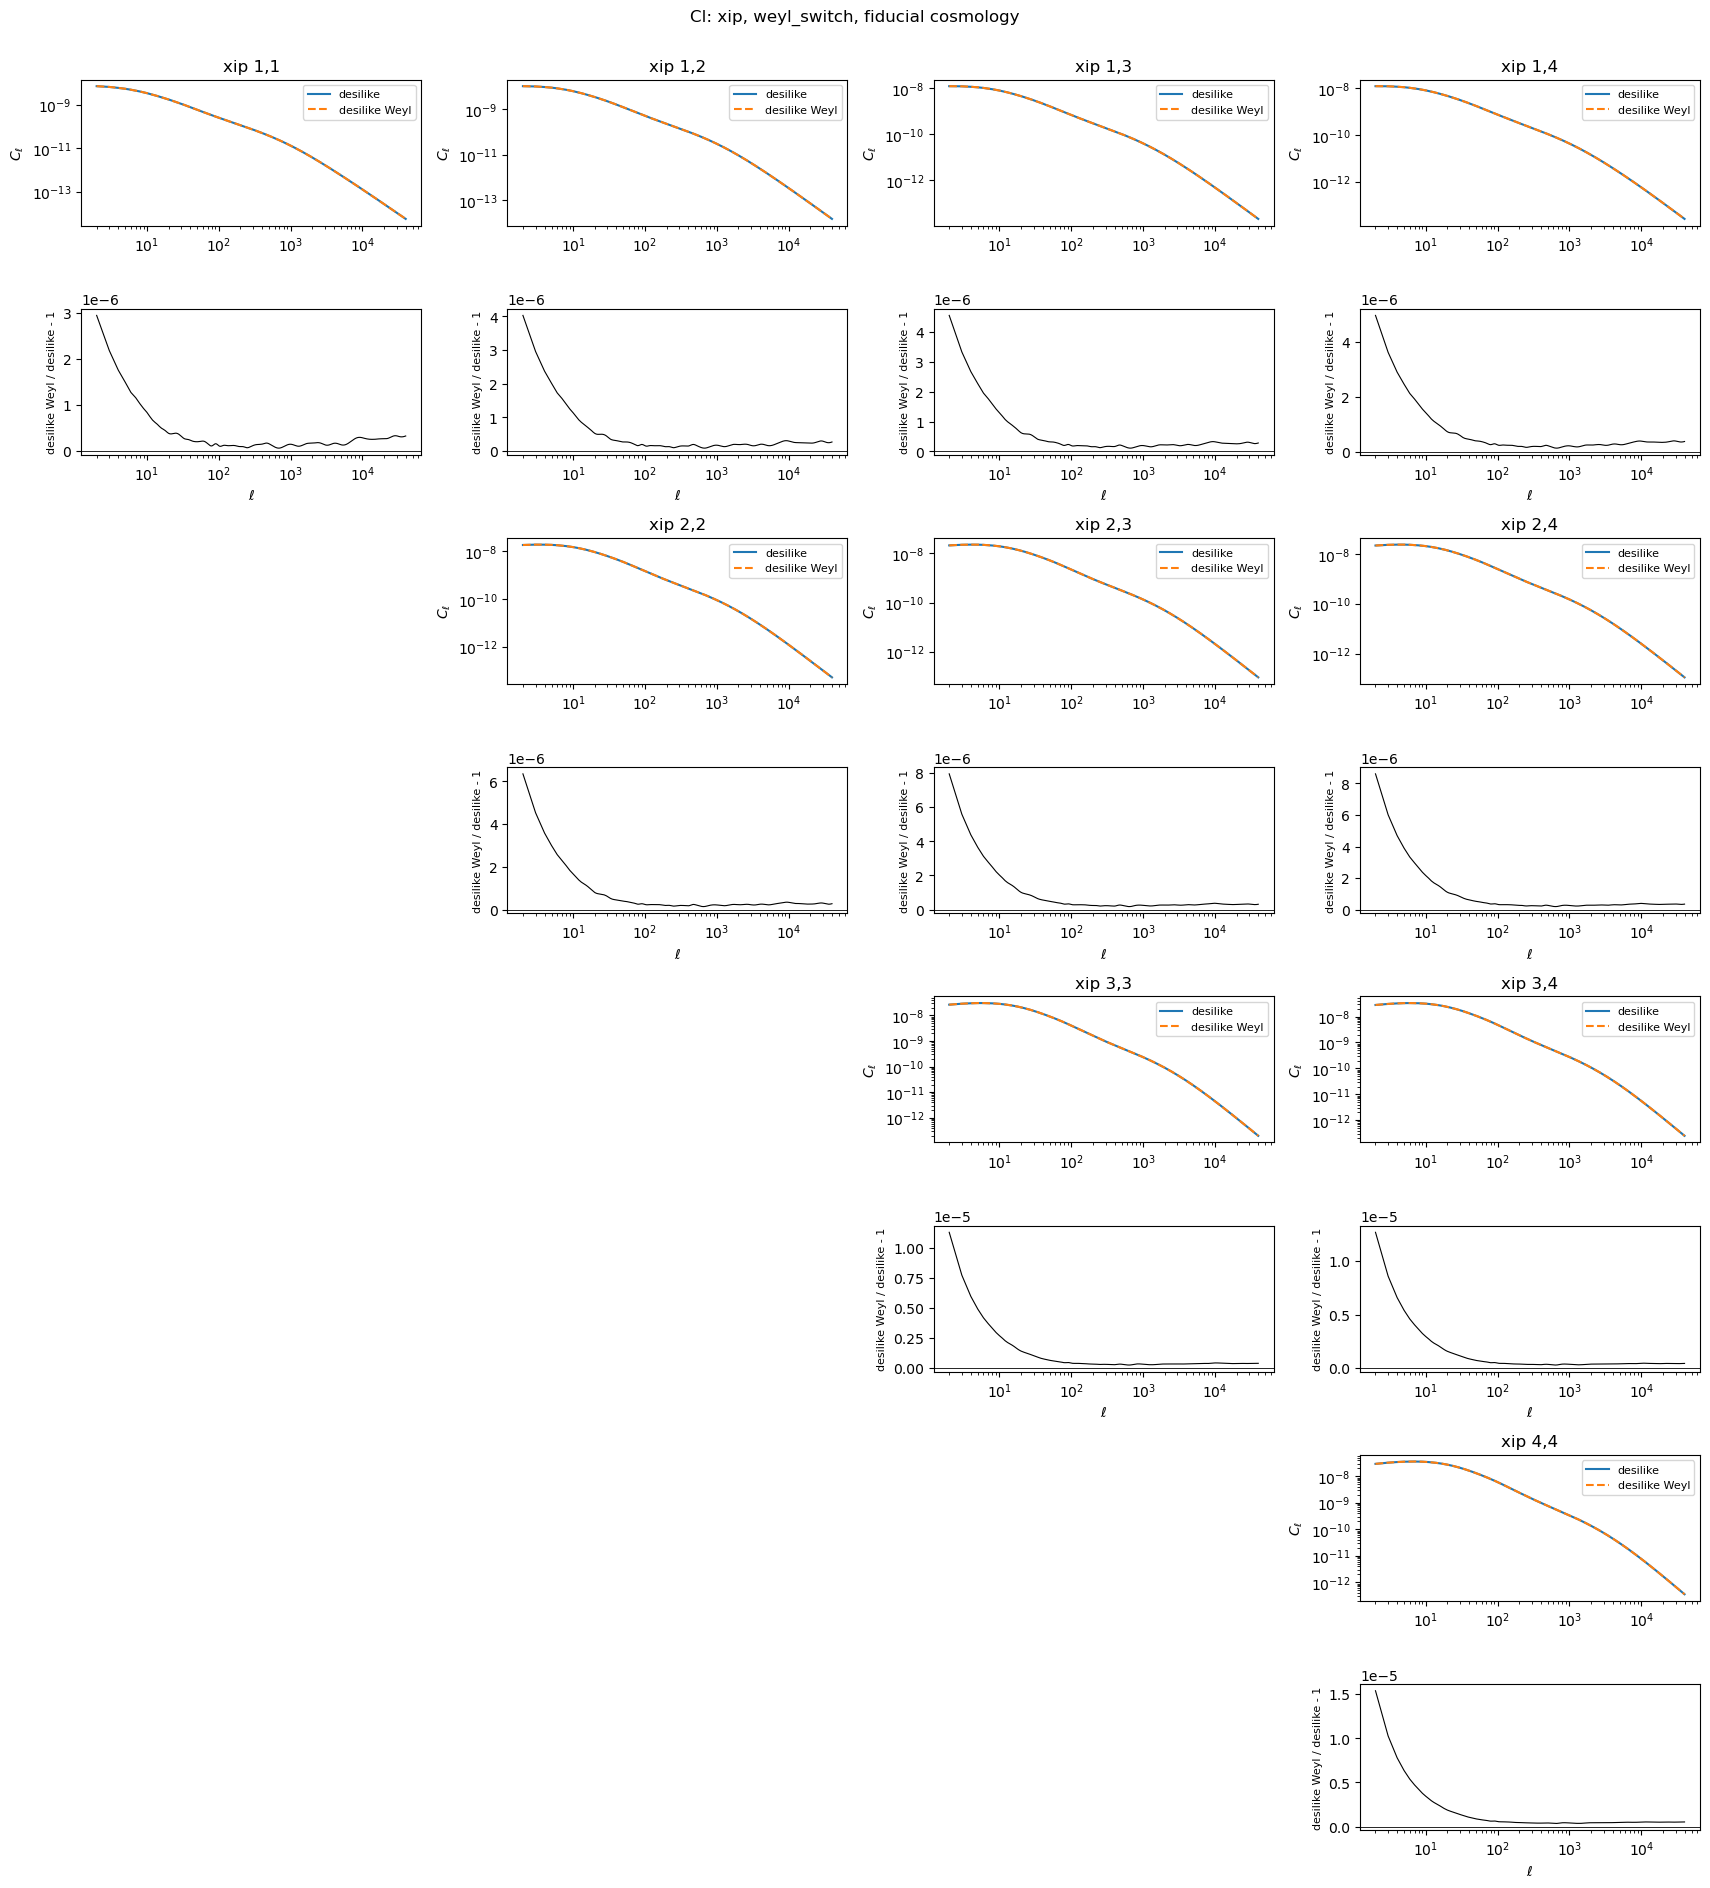

In [43]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xip"]
second = fiducial["predictions"]["density"]["cl_xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xip, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — Cl — desilike：Weyl 开 / 关

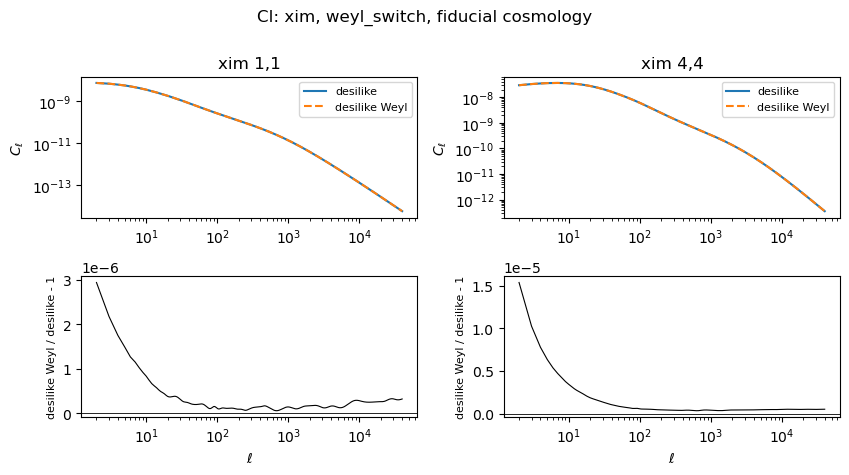

In [44]:
x = np.asarray(fiducial["predictions"]["density"]["ell"])
first = fiducial["predictions"]["weyl"]["cl_xim"]
second = fiducial["predictions"]["density"]["cl_xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = x >= 2
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$C_\ell$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], color="black", lw=0.8)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\ell$")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("Cl: xim, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "Cl_weyl_switch_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### wtheta — xi — desilike：Weyl 开 / 关

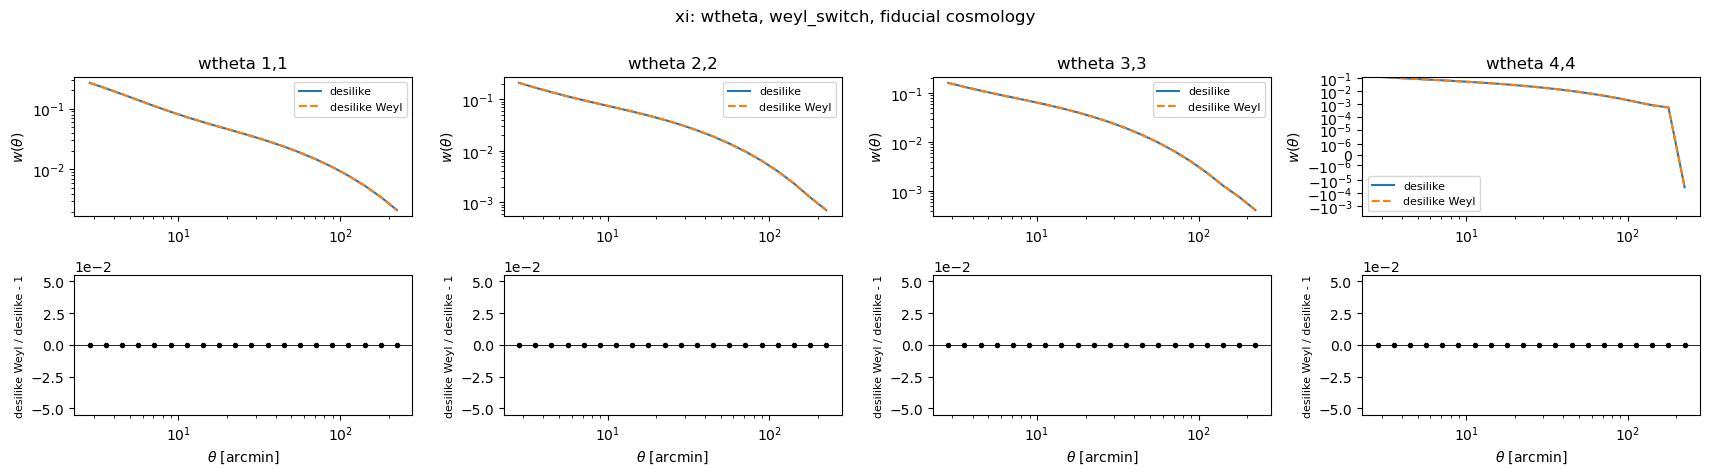

In [45]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["wtheta"]
second = fiducial["predictions"]["density"]["wtheta"]
pairs = PLOT_PAIRS["wtheta"]
fig, axes = plt.subplots(2, 4, figsize=(17.2, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"wtheta {i+1},{j+1}")
    top.set_ylabel(r"$w(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: wtheta, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_wtheta.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### gammat — xi — desilike：Weyl 开 / 关

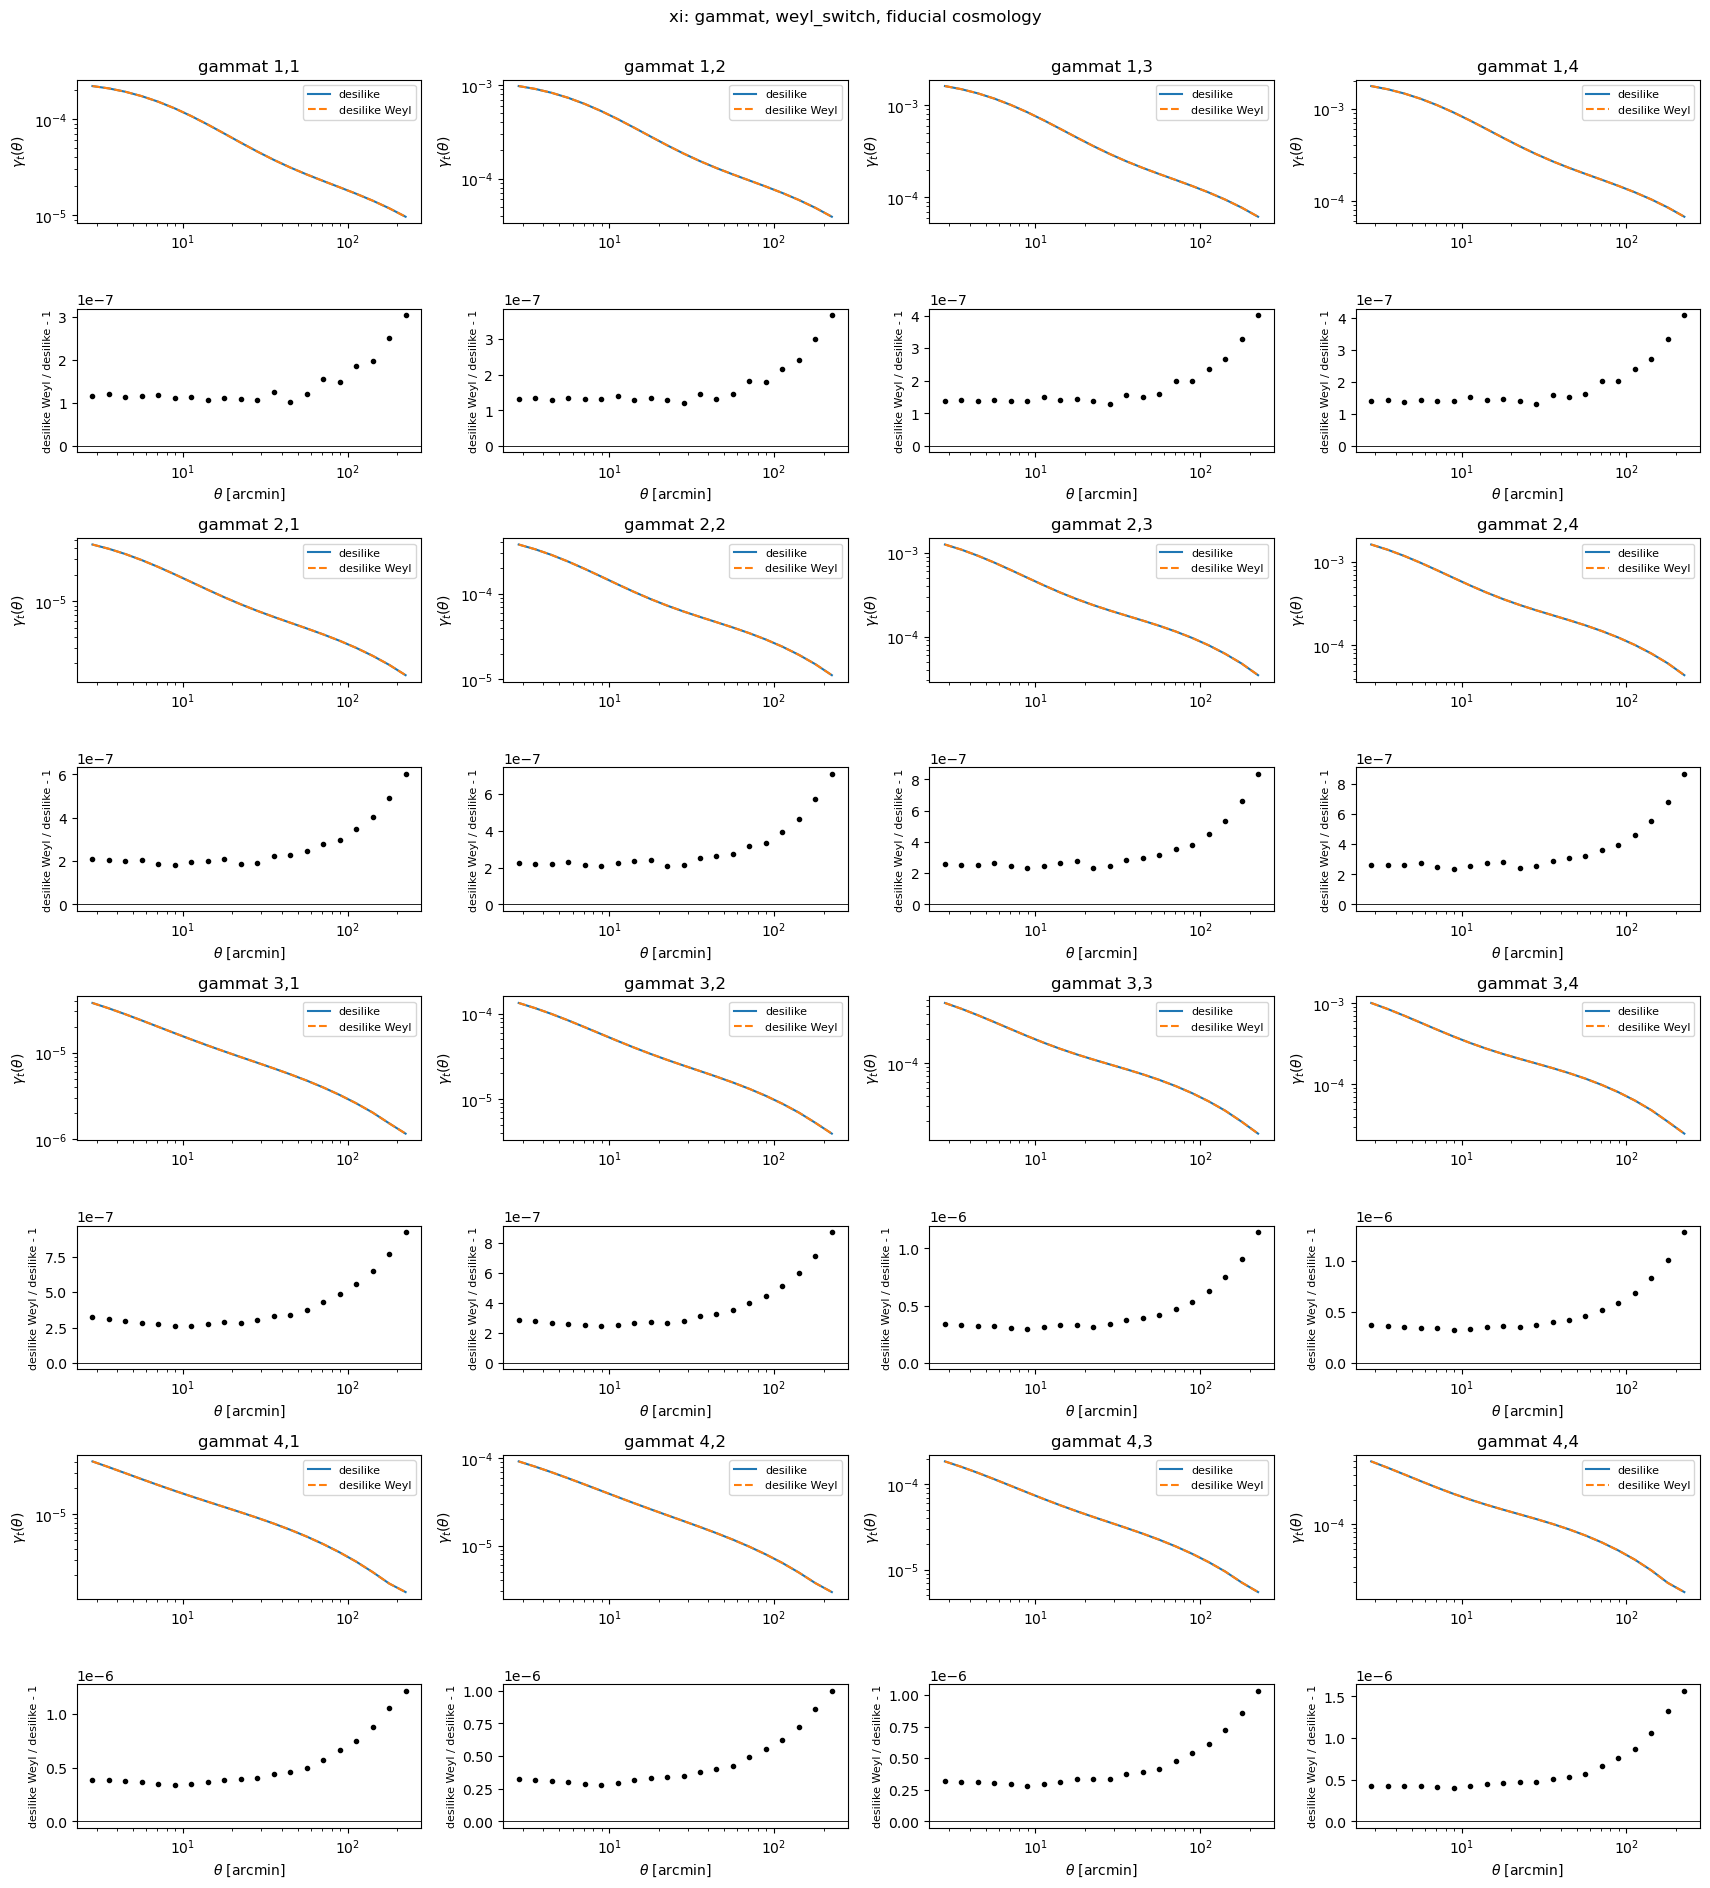

In [46]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["gammat"]
second = fiducial["predictions"]["density"]["gammat"]
pairs = PLOT_PAIRS["gammat"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"gammat {i+1},{j+1}")
    top.set_ylabel(r"$\gamma_t(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: gammat, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_gammat.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xip — xi — desilike：Weyl 开 / 关

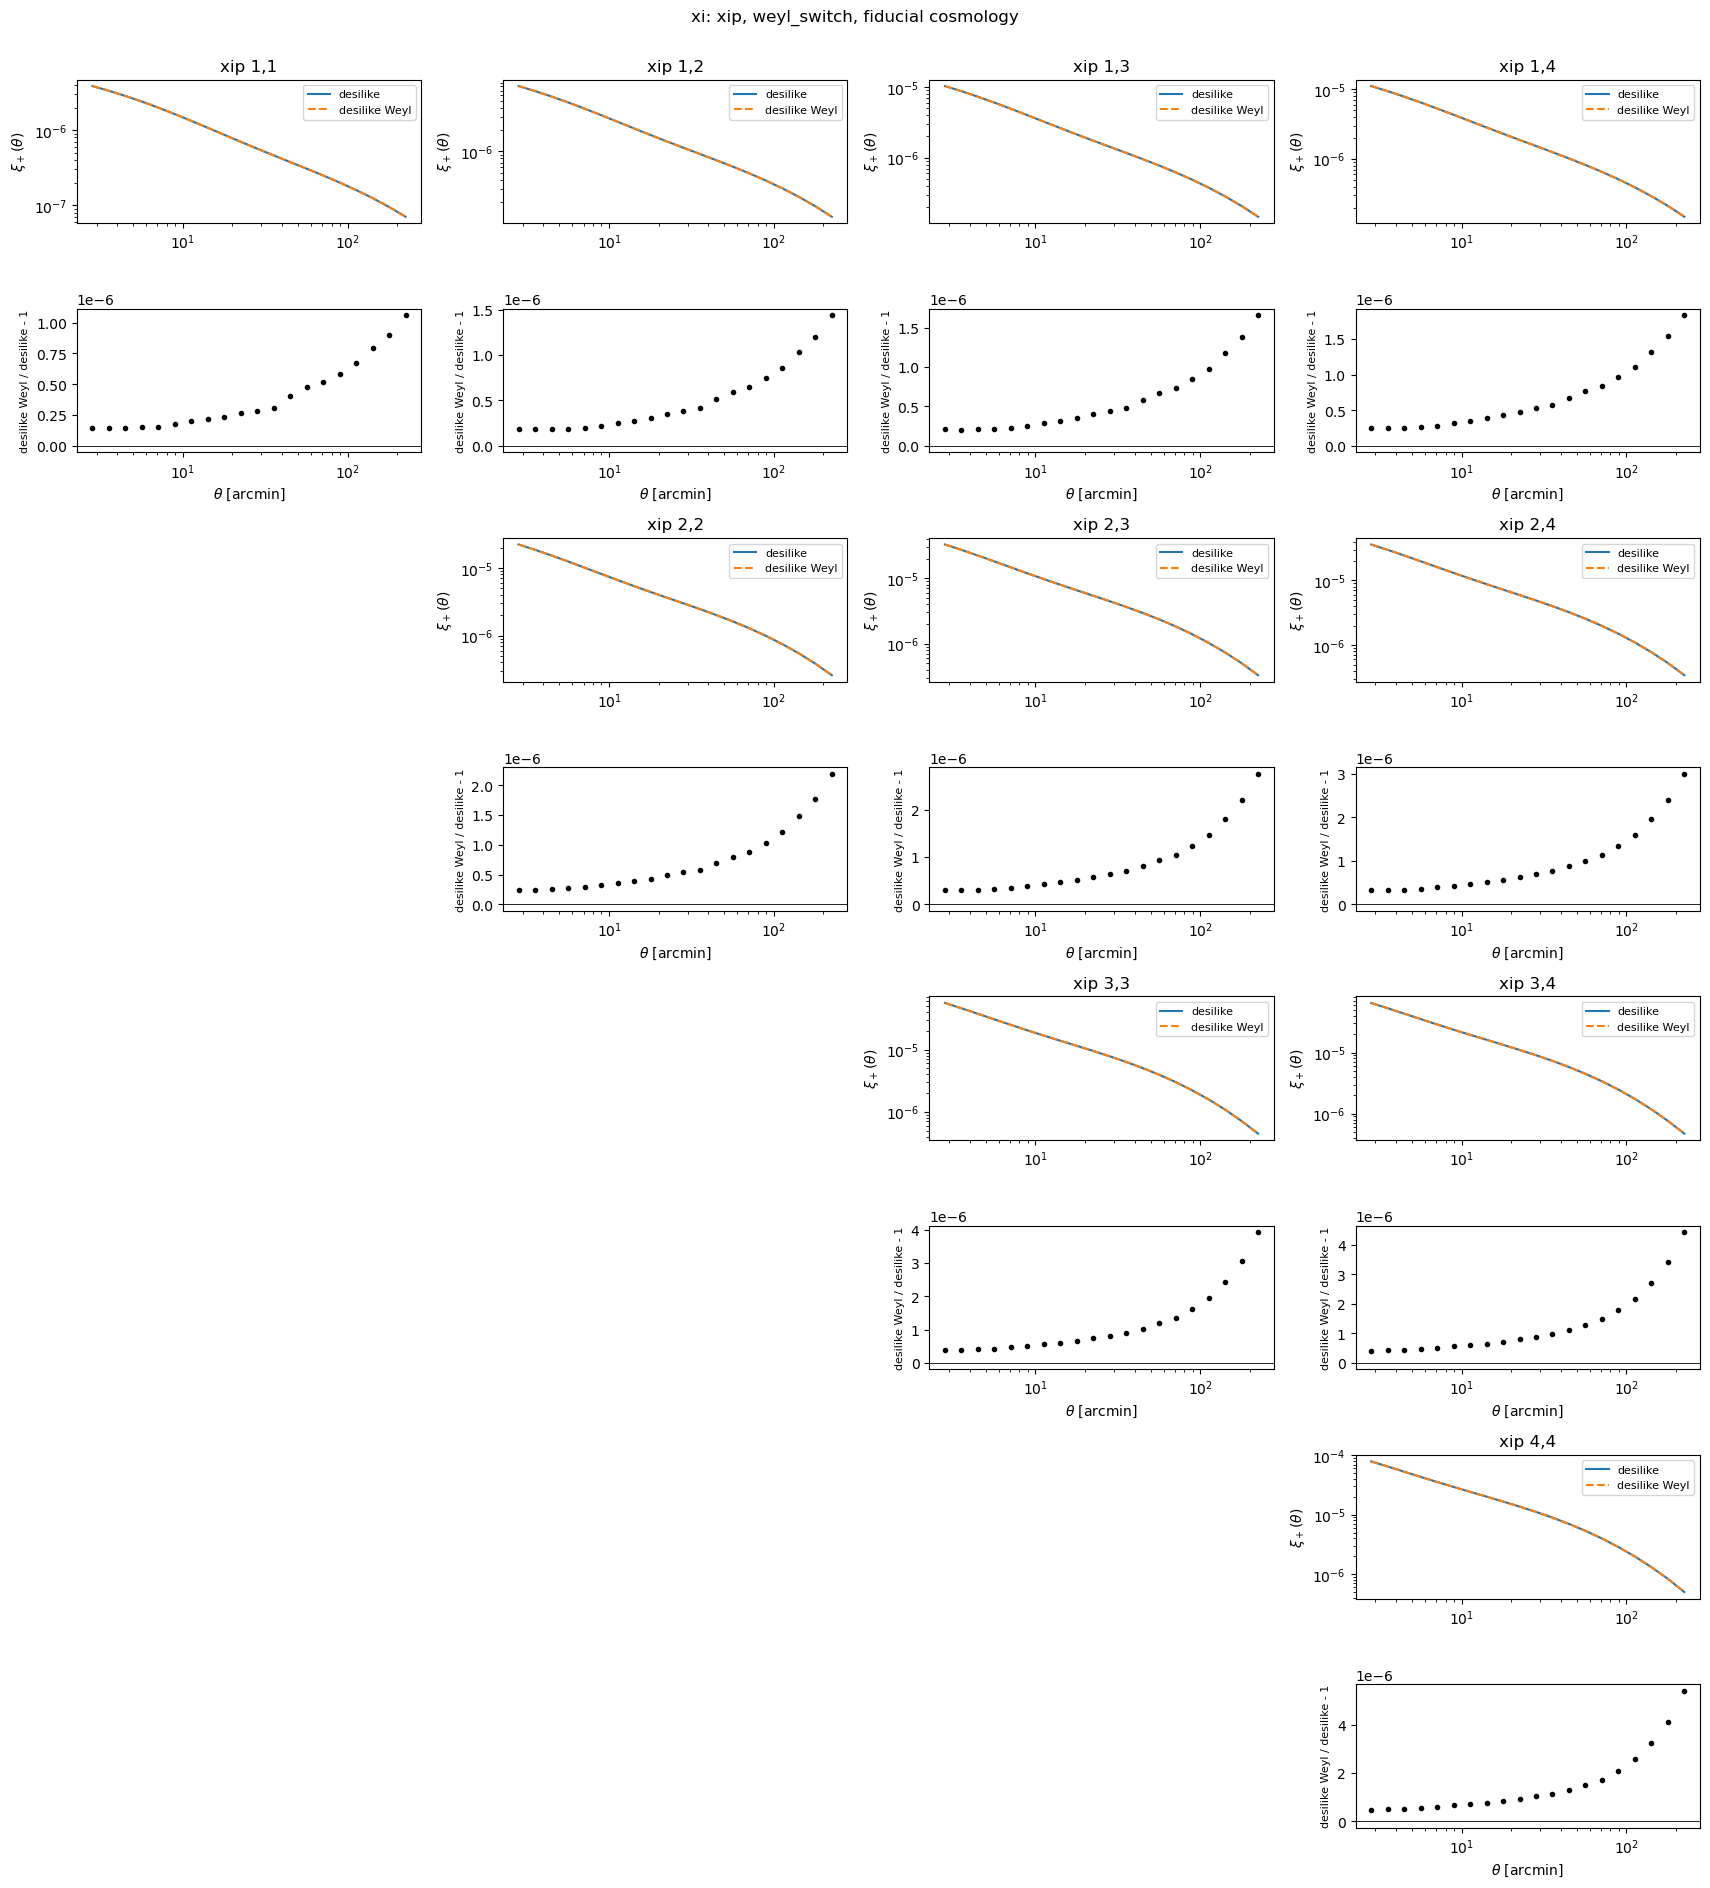

In [47]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xip"]
second = fiducial["predictions"]["density"]["xip"]
pairs = PLOT_PAIRS["xip"]
fig, axes = plt.subplots(8, 4, figsize=(17.2, 18.8), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (i, j)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xip {i+1},{j+1}")
    top.set_ylabel(r"$\xi_+(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xip, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_xip.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


### xim — xi — desilike：Weyl 开 / 关

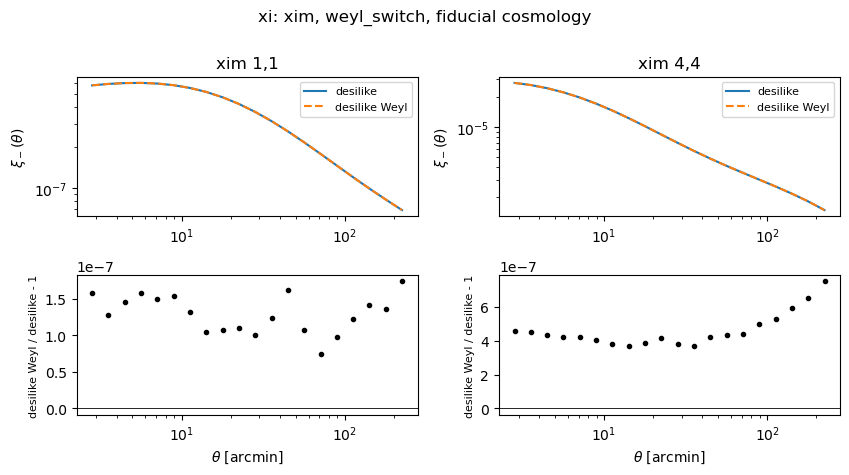

In [48]:
x = np.asarray(theta_bins)
first = fiducial["predictions"]["weyl"]["xim"]
second = fiducial["predictions"]["density"]["xim"]
pairs = PLOT_PAIRS["xim"]
fig, axes = plt.subplots(2, 2, figsize=(8.6, 4.7), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)

for count, (i, j) in enumerate(pairs):
    row, col = (0, count)
    top, bottom = axes[2 * row, col], axes[2 * row + 1, col]
    top.set_visible(True)
    bottom.set_visible(True)
    a = np.asarray(first[i, j])
    b = np.asarray(second[i, j])
    mask = np.ones(x.size, dtype=bool)
    top.plot(x[mask], b[mask], label="desilike")
    top.plot(x[mask], a[mask], "--", label="desilike Weyl")
    top.set_xscale("log")
    # 保留负值；全正时使用原 notebook 的 log-log 坐标。
    if np.any(a[mask] < 0) or np.any(b[mask] < 0):
        top.set_yscale("symlog", linthresh=max(np.max(np.abs(b)) * 1e-5, 1e-300))
    else:
        top.set_yscale("log")
    top.set_title(f"xim {i+1},{j+1}")
    top.set_ylabel(r"$\xi_-(\theta)$")
    top.legend(fontsize=8)

    valid = mask & (np.abs(b) > max(np.max(np.abs(b)) * 1e-12, 1e-300))
    delta = np.full_like(b, np.nan, dtype=float)
    np.divide(a - b, b, out=delta, where=valid)  # 分母过零处不画比值
    axes[2 * row + 1, col].semilogx(x[valid], delta[valid], "ko", ms=3)
    bottom.axhline(0, color="black", lw=0.6)
    bottom.set_xlabel(r"$\theta$ [arcmin]")
    bottom.set_ylabel("desilike Weyl / desilike - 1", fontsize=8)
    bottom.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

fig.suptitle("xi: xim, weyl_switch, fiducial cosmology", y=1.002)
fig.tight_layout()
fig.savefig(OUT / "xi_weyl_switch_xim.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)


## 7. 基准点的 likelihood

拆开显示 3×2pt 与 shear-ratio χ²；点质量边缘化已包含在 3×2pt 中。

,case,mode,chi2_des,chi2_ref,delta_chi2,des_3x2,ref_3x2,des_sr,ref_sr
0,fiducial,density,765.574133,765.574128,0.000005,526.897205,526.89720,238.676928,238.676928
1,fiducial,weyl,765.574206,765.574201,0.000005,526.897265,526.89726,238.676941,238.676941


,worst
model_delta_chi2,4.655349e-13
precision_relative_norm,1.807329e-14
sigma_crit_relative_norm,3.446221e-16


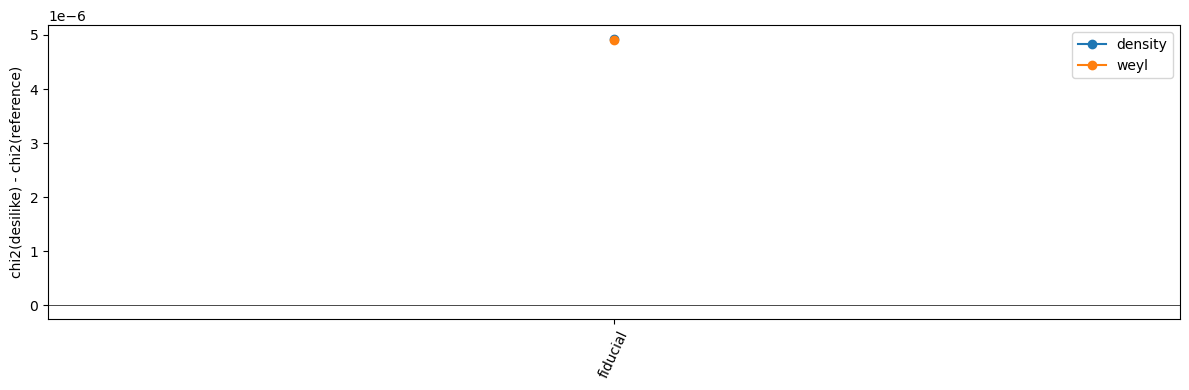

In [49]:
display(
    chi2_df[
        [
            "case",
            "mode",
            "chi2_des",
            "chi2_ref",
            "delta_chi2",
            "des_3x2",
            "ref_3x2",
            "des_sr",
            "ref_sr",
        ]
    ]
)
display(
    chi2_df[["model_delta_chi2", "precision_relative_norm", "sigma_crit_relative_norm"]]
    .max()
    .to_frame("worst")
)
assert np.isfinite(chi2_df.select_dtypes("number").to_numpy()).all()
assert chi2_df.delta_chi2.abs().max() < 1e-3
assert chi2_df.model_delta_chi2.max() < 1e-6
fig, ax = plt.subplots(figsize=(12, 4))
for mode, rows in chi2_df.groupby("mode"):
    ax.plot(rows.case, rows.delta_chi2, "o-", label=mode)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("chi2(desilike) - chi2(reference)")
ax.tick_params(axis="x", rotation=65)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "chi2_comparison.png", dpi=150)
plt.show()


## 8. 批量复核：13 组 LCDM

前面的图只用基准点。这一节重复相同计算，依次改变六个 LCDM 参数，保留全部误差表和断言。扫描后 `fiducial` 仍是基准点，因此上面的画图单元格可直接重跑。

In [50]:
power_rows, angular_rows, correlation_rows, chi2_rows, switch_rows = [], [], [], [], []
fiducial = {}
camb_template = None

start = time.monotonic()


In [51]:
for case, values in CASES:
    pair = WeylPair(make_cosmo(values))
    pipe = build(pair)
    predictions = jax.tree_util.tree_map(np.asarray, pair.result)  # build 已按当前参数计算整张图
    if camb_template is None:
        camb_template = pair.cosmo._cosmo.engine._camb_params.copy()
    cp = camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    # YHe is a BBN-derived quantity and must follow omega_b, not remain at the template value.
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    results = camb.get_results(cp)  # 独立计算，不使用 cosmoprimo 的 CAMBdata
    provider = CAMBProvider(results)
    kernels = pair.yes.theory.kernels
    iz = np.array([0, 1, 50, 100, 200, len(kernels.z_pk) - 1])
    redshifts = kernels.z_pk[iz]
    physical_k = np.geomspace(1e-4, 7999.0, 501)
    power_curves = {}
    for label, of, nl, camb_pair in [
        ("matter_linear", "delta_m", False, ("delta_tot", "delta_tot")),
        ("matter_nonlinear", "delta_m", True, ("delta_tot", "delta_tot")),
        ("weyl_linear", "phi_plus_psi", False, ("Weyl", "Weyl")),
        ("matter_weyl", ("delta_m", "phi_plus_psi"), False, ("delta_tot", "Weyl")),
    ]:
        table = kernels.spectrum(of, nl)[iz]
        power = (
            np.asarray(
                jnp.exp(
                    spline(jnp.log(physical_k / values["h"]), jnp.log(kernels.k), jnp.log(table).T)
                )
            ).T
            / values["h"] ** 3
        )
        if label == "weyl_linear":
            power = power * physical_k**4 / 4
        if label == "matter_weyl":
            power = -power * physical_k**2 / 2
        target = provider.pk[nl, camb_pair].P(redshifts, physical_k)
        for region, mask in [("sampled", physical_k <= 100), ("extrapolated", physical_k > 100)]:
            power_rows.append(
                dict(
                    case=case,
                    spectrum=label,
                    region=region,
                    **relative_metrics(power[:, mask], target[:, mask]),
                )
            )
        power_curves[label] = (power, target)
    references = {}
    for mode, ref in [("density", ref_no), ("weyl", ref_yes)]:
        target = evaluate_reference(ref, provider, NUISANCE)
        references[mode] = target
        aa, xx, cc = compare_predictions(case, mode, predictions[mode], ref, target)
        angular_rows.extend(aa)
        correlation_rows.extend(xx)
        chi2_rows.append(cc)
    for index, name in enumerate(TYPES):
        pairs = ref_no.bin_pairs[index]
        for space, key in [("Cl", "cl_" + name), ("xi", name)]:
            no = np.array([predictions["density"][key][i, j] for i, j in pairs])
            yes = np.array([predictions["weyl"][key][i, j] for i, j in pairs])
            if space == "Cl":
                rn = np.array(
                    [references["density"]["cls"][name][int(i), int(j)] for i, j in pairs]
                )
                ry = np.array([references["weyl"]["cls"][name][int(i), int(j)] for i, j in pairs])
            else:
                rn = np.array([references["density"]["corrs"][index][i, j] for i, j in pairs])
                ry = np.array([references["weyl"]["corrs"][index][i, j] for i, j in pairs])
            switch_rows.append(
                dict(
                    case=case,
                    space=space,
                    observable=name,
                    des_switch=relative_metrics(yes, no)["max_scaled"],
                    ref_switch=relative_metrics(ry, rn)["max_scaled"],
                    switch_residual=float(
                        np.max(np.abs((yes - no) - (ry - rn))) / np.max(np.abs(rn))
                    ),
                )
            )
    if case == "fiducial":
        fiducial = dict(
            predictions=predictions,
            references=references,
            power=power_curves,
            k=physical_k,
            z=redshifts,
        )
    for name, rows in [
        ("power", power_rows),
        ("angular", angular_rows),
        ("correlation", correlation_rows),
        ("chi2", chi2_rows),
        ("weyl_switch", switch_rows),
    ]:
        pd.DataFrame(rows).to_csv(OUT / f"{name}.csv", index=False)
    (OUT / "progress.json").write_text(
        json.dumps(
            dict(
                case=case,
                completed=len(chi2_rows) // 2,
                total=len(CASES),
                seconds=time.monotonic() - start,
            )
        )
    )
    print(case, "max |Δχ²| =", max(abs(x["delta_chi2"]) for x in chi2_rows[-2:]), flush=True)
    del pair, pipe, predictions, references, results, provider, kernels
    gc.collect()


fiducial max |Δχ²| = 4.934488515573321e-06


h_low max |Δχ²| = 3.658141849882668e-06


h_high max |Δχ²| = 1.7149109226011205e-06


omega_b_low max |Δχ²| = 1.3652238521899562e-06


omega_b_high max |Δχ²| = 7.634076268914214e-06


...

logA_high max |Δχ²| = 6.552745162480278e-06


n_s_low max |Δχ²| = 4.777903200192668e-06


n_s_high max |Δχ²| = 5.109886387799634e-06


tau_reio_low max |Δχ²| = 4.65647678993264e-06


tau_reio_high max |Δχ²| = 4.722880021290621e-06


In [52]:
power_df = pd.DataFrame(power_rows)
angular_df = pd.DataFrame(angular_rows)
correlation_df = pd.DataFrame(correlation_rows)
chi2_df = pd.DataFrame(chi2_rows)
switch_df = pd.DataFrame(switch_rows)
display(
    power_df.groupby(["spectrum", "region"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert power_df.finite.all()
assert power_df.max_scaled.max() < 5e-5


max_scaled    rms_scaled  max_relative
spectrum         region                                                
matter_linear    extrapolated  1.823977e-09  1.927771e-09  5.874966e-08
                 sampled       1.054593e-08  2.328875e-09  1.543219e-07
matter_nonlinear extrapolated  2.178448e-10  1.752168e-10  1.661052e-08
                 sampled       1.056425e-08  2.303380e-09  1.475719e-07
matter_weyl      extrapolated  2.273615e-09  1.982001e-09  2.445149e-08
                 sampled       2.942252e-08  3.851338e-09  1.540164e-07
weyl_linear      extrapolated  1.547826e-10  6.433669e-11  1.966037e-08
                 sampled       9.192366e-08  9.709381e-09  1.541494e-07

In [53]:
display(
    angular_df.groupby(["mode", "observable"])[["max_scaled", "rms_scaled", "max_relative"]].max()
)
assert angular_df.finite.all() and angular_df.max_scaled.max() < 1e-5


max_scaled    rms_scaled  max_relative
mode    observable                                          
density gammat      3.228561e-08  6.653249e-09  3.288793e-08
        wtheta      3.686359e-09  1.132455e-09  2.091304e-08
        xim         1.772442e-08  4.018645e-09  1.913980e-08
        xip         1.772442e-08  4.018645e-09  1.913980e-08
weyl    gammat      1.579123e-08  3.553513e-09  2.306562e-08
        wtheta      3.686359e-09  1.132455e-09  2.091304e-08
        xim         6.423846e-09  1.636302e-09  1.436996e-08
        xip         6.423846e-09  1.636302e-09  1.436996e-08

In [54]:
display(
    correlation_df.groupby(["mode", "observable"])[
        ["max_scaled", "rms_scaled", "max_relative"]
    ].max()
)
assert correlation_df.finite.all() and correlation_df.max_scaled.max() < 1e-5


max_scaled    rms_scaled  max_relative
mode    observable                                          
density gammat      6.782296e-10  6.260672e-10  6.049522e-09
        wtheta      1.155909e-09  1.294753e-09  2.480431e-06
        xim         5.377462e-10  4.807325e-10  5.478195e-09
        xip         8.775540e-10  1.091403e-09  4.570978e-09
weyl    gammat      6.455805e-10  6.198396e-10  5.904314e-09
        wtheta      1.155909e-09  1.294753e-09  2.480431e-06
        xim         5.026044e-10  4.650711e-10  5.386514e-09
        xip         8.610512e-10  1.054517e-09  4.277907e-09

In [55]:
display(
    switch_df.groupby(["space", "observable"])[
        ["des_switch", "ref_switch", "switch_residual"]
    ].max()
)
assert switch_df.switch_residual.max() < 1e-5


des_switch    ref_switch  switch_residual
space observable                                             
Cl    gammat      1.632095e-05  1.632095e-05     1.649436e-08
      wtheta      5.731818e-17  7.771661e-17     1.036222e-16
      xim         4.373518e-05  4.373518e-05     1.759564e-08
      xip         4.373518e-05  4.373518e-05     1.759564e-08
xi    gammat      2.454684e-07  2.454677e-07     1.031196e-10
      wtheta      1.046004e-16  1.061445e-16     1.061445e-16
      xim         4.827981e-07  4.827999e-07     8.790827e-11
      xip         5.227164e-07  5.227329e-07     7.315051e-11

,case,mode,chi2_des,chi2_ref,delta_chi2,des_3x2,ref_3x2,des_sr,ref_sr
0,fiducial,density,765.574133,765.574128,4.934489e-06,526.897205,526.897200,238.676928,238.676928
1,fiducial,weyl,765.574206,765.574201,4.912783e-06,526.897265,526.897260,238.676941,238.676941
2,h_low,density,735.510649,735.510653,-3.658142e-06,482.547563,482.547567,252.963086,252.963086
3,h_low,weyl,735.510838,735.510841,-3.635952e-06,482.547739,482.547743,252.963098,252.963098
4,h_high,density,833.074770,833.074768,1.714911e-06,607.046460,607.046458,226.028310,226.028310
5,h_high,weyl,833.074747,833.074745,1.685720e-06,607.046424,607.046422,226.028323,226.028323
6,omega_b_low,density,778.289426,778.289425,1.364225e-06,540.126585,540.126584,238.162841,238.162841
7,omega_b_low,weyl,778.289500,778.289498,1.365224e-06,540.126647,540.126645,238.162853,238.162853
8,omega_b_high,density,752.271004,752.270997,7.634076e-06,512.952432,512.952424,239.318572,239.318572
9,omega_b_high,weyl,752.271080,752.271073,7.630351e-06,512.952496,512.952488,239.318584,239.318584


,worst
model_delta_chi2,1.141608e-12
precision_relative_norm,1.807329e-14
sigma_crit_relative_norm,3.446221e-16


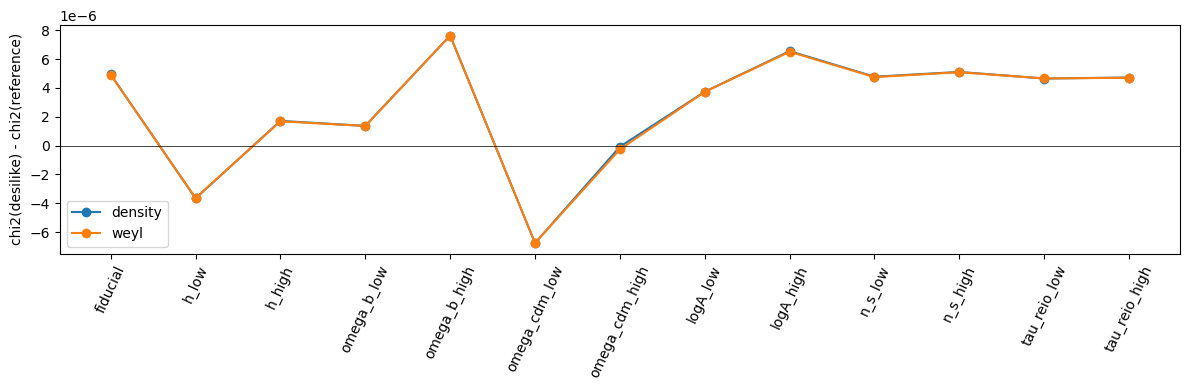

In [56]:
display(
    chi2_df[
        [
            "case",
            "mode",
            "chi2_des",
            "chi2_ref",
            "delta_chi2",
            "des_3x2",
            "ref_3x2",
            "des_sr",
            "ref_sr",
        ]
    ]
)
display(
    chi2_df[["model_delta_chi2", "precision_relative_norm", "sigma_crit_relative_norm"]]
    .max()
    .to_frame("worst")
)
assert np.isfinite(chi2_df.select_dtypes("number").to_numpy()).all()
assert chi2_df.delta_chi2.abs().max() < 1e-3
assert chi2_df.model_delta_chi2.max() < 1e-6
fig, ax = plt.subplots(figsize=(12, 4))
for mode, rows in chi2_df.groupby("mode"):
    ax.plot(rows.case, rows.delta_chi2, "o-", label=mode)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("chi2(desilike) - chi2(reference)")
ax.tick_params(axis="x", rotation=65)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "chi2_comparison.png", dpi=150)
plt.show()


## 9. JAX/JIT 与梯度

NLA redshift kernels、全局三次样条、Limber 积分、角投影和 likelihood（包括点质量修正、shear ratios）为原生 JAX。
CAMB 是外部 Boltzmann 求解器；非 Limber FFTLog 的整数网格长度随宇宙学变化，为保持参考离散化，单独保留外部节点。跨这两类节点的导数由 refactor-jax 的有限差分机制提供；shear calibration 的路径使用原生自动微分。

下面比较 eager/JIT，并将 `jax.grad` 与显式中心差分比较。

In [57]:
cosmo = make_cosmo(BASE)
theory = DESWeakLensing3x2pt(cosmo=cosmo, Weyl=True)
likelihood = BaseDESY3Likelihood(theory=theory, use_sr=True)
loglike = build(likelihood)
eager = float(loglike())
compiled = jax.jit(loglike)
jitted = float(compiled())
print("eager:", eager, "JIT:", jitted, "difference:", jitted - eager)
np.testing.assert_allclose(jitted, eager, rtol=1e-9, atol=1e-5)


eager: -382.7871029943156 JIT: -382.7871029943139 difference: 1.7053025658242404e-12


In [58]:
grad_rows = []
for name, center, step in [("DES_m1", NUISANCE["DES_m1"], 1e-5), ("h", BASE["h"], 1e-4)]:
    fun = lambda value: loglike({name: value})
    gradient = float(jax.grad(fun)(center))
    difference = float(
        (compiled({name: center + step}) - compiled({name: center - step})) / (2 * step)
    )
    error = abs(gradient - difference) / max(abs(difference), 1.0)
    grad_rows.append(
        dict(parameter=name, jax_grad=gradient, central_difference=difference, relative_error=error)
    )
    assert np.isfinite(gradient) and error < 5e-3
grad_df = pd.DataFrame(grad_rows)
display(grad_df)
grad_df.to_csv(OUT / "gradients.csv", index=False)


,parameter,jax_grad,central_difference,relative_error
0,DES_m1,171.928436,171.928436,1.786701e-11
1,h,-732.582608,-732.582608,9.699148e-12


## 汇总与改动记录

对齐了：全局 not-a-knot 三次样条及外推、物理 k=0.05/Mpc 且 z=0 归一化的增长因子、与 CAMB 相同的总物质密度（包含中微子总能量，而非扣除压力后的 Omega_m）、原始 lens n(z) 的 FFTLog 网格宽度、k=8000/Mpc 的积分外推范围、Weyl 的单位/符号约定。CAMB 的实际求解范围也从原默认约 7/Mpc 提高到约 100/Mpc，避免过早高 k 外推。

修正前基线文件记录旧配置下同输入两份实现的差异；与新配置绝对 χ² 不应直接相减，因实际 CAMB 求解范围也提高了。

In [59]:
before = json.loads((OUT / "before_alignment.json").read_text())
print("修正前同输入参考对比 Δχ²:", before["desilike_chi2"] - before["reference_chi2"])
summary = dict(
    cosmologies=len(CASES),
    weyl_modes=2,
    versions=VERSIONS,
    reference_sha256=hashlib.sha256(REFERENCE.read_bytes()).hexdigest(),
    max_power_scaled=float(power_df.max_scaled.max()),
    max_Cl_scaled=float(angular_df.max_scaled.max()),
    max_xi_scaled=float(correlation_df.max_scaled.max()),
    max_abs_delta_chi2=float(chi2_df.delta_chi2.abs().max()),
    max_model_delta_chi2=float(chi2_df.model_delta_chi2.max()),
    max_weyl_switch_residual=float(switch_df.switch_residual.max()),
    jit_loglike_difference=jitted - eager,
    tests_passed=True,
)
(OUT / "summary.json").write_text(json.dumps(summary, indent=2))
display(pd.Series(summary).to_frame("result"))
print("数值表、图和汇总保存到:", OUT)


修正前同输入参考对比 Δχ²: -3.217026216692261


,result
cosmologies,13
weyl_modes,2
versions,"{'jax': '0.6.2', 'jaxlib': '0.6.2', 'interpax'..."
reference_sha256,d997f6a7d49ac677fd8b687e362e18e0e241c56f807f31...
max_power_scaled,0.0
max_Cl_scaled,0.0
max_xi_scaled,0.0
max_abs_delta_chi2,0.000008
max_model_delta_chi2,0.0
max_weyl_switch_residual,0.0


数值表、图和汇总保存到: /Users/illyasviel/Desktop/project/desilike/diagnostics/weak_lensing_consistency


## 10. JAX 与 NumPy/SciPy 的结果和速度


比较三个执行路径：原始 `des.py` 的 **NumPy/SciPy** 路径（关闭其可选 numba）、desilike **JAX eager（不启用 JIT）**、desilike **JAX JIT**。JAX eager 仍然使用 JAX，不能称为 NumPy 后端。此前 13 组宇宙学已比较 eager 与原始实现；这里增加基准宇宙学下 JIT 的全部角功率谱、关联函数与 χ² 一致性检查。

计时不使用提取参考实现内部变量的 `sys.settrace`；每次均等待标量结果就绪，防止异步派发产生虚假的加速。固定 CPU 线程设置，分别报告构建耗时、首次 JIT 调用（含编译）和预热后的中位数/IQR。改变 nuisance 时复用 CAMB；改变 h 时包含 CAMB 重新计算。相同输入另列为缓存开销，不能代表独立采样点速度。

原始参考实现每次 logp 重算弱透镜理论，而 desilike 可以复用未受参数变化影响的节点。因此相对 NumPy 的倍数是**整个实现的运行收益，包含计算图缓存**；同一 desilike 的 eager/JIT 比值更直接反映 JIT 的收益。CAMB 和非 Limber FFTLog 在三条路径中均不是原生 JAX。

In [60]:
validation_pair = WeylPair(make_cosmo(BASE))

validation_pipe = build(validation_pair)

validation_eager = jax.tree_util.tree_map(np.asarray, validation_pair.result)

benchmark_camb_template = validation_pair.cosmo._cosmo.engine._camb_params.copy()

BENCH_PARAMS = {**BASE, **NUISANCE}

validation_jit = jax.jit(validation_pipe)

validation_compiled = jax.tree_util.tree_map(np.asarray, validation_jit(BENCH_PARAMS))


#### 独立 CAMB 的一致参数设置

In [61]:
def benchmark_provider(values):
    cp = benchmark_camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    return CAMBProvider(camb.get_results(cp))


In [62]:
validation_provider = benchmark_provider(BASE)

backend_accuracy_rows = []
backend_chi2_rows = []

backend_accuracy_rows = []
backend_chi2_rows = []

for mode, reference in [("density", ref_no), ("weyl", ref_yes)]:
    target = evaluate_reference(reference, validation_provider, NUISANCE)
    for backend, prediction in [
        ("JAX eager", validation_eager[mode]),
        ("JAX JIT", validation_compiled[mode]),
    ]:
        backend_chi2_rows.append(
            dict(
                mode=mode,
                backend=backend,
                chi2=float(prediction["chi2"]),
                numpy_chi2=target["chi2"],
                delta_chi2=float(prediction["chi2"]) - target["chi2"],
            )
        )
        for index, name in enumerate(TYPES):
            pairs = reference.bin_pairs[index]
            for space, key in [("Cl", "cl_" + name), ("xi", name)]:
                actual = np.array([prediction[key][i, j] for i, j in pairs])
                expected = np.array(
                    [
                        (
                            target["cls"][name][int(i), int(j)]
                            if space == "Cl"
                            else target["corrs"][index][i, j]
                        )
                        for i, j in pairs
                    ]
                )
                backend_accuracy_rows.append(
                    dict(
                        mode=mode,
                        comparison=backend + " vs NumPy",
                        space=space,
                        observable=name,
                        **relative_metrics(actual, expected)
                    )
                )
    for index, name in enumerate(TYPES):
        pairs = reference.bin_pairs[index]
        for space, key in [("Cl", "cl_" + name), ("xi", name)]:
            a = np.array([validation_compiled[mode][key][i, j] for i, j in pairs])
            b = np.array([validation_eager[mode][key][i, j] for i, j in pairs])
            backend_accuracy_rows.append(
                dict(
                    mode=mode,
                    comparison="JAX JIT vs eager",
                    space=space,
                    observable=name,
                    **relative_metrics(a, b)
                )
            )

backend_accuracy = pd.DataFrame(backend_accuracy_rows)

backend_chi2 = pd.DataFrame(backend_chi2_rows)

display(
    backend_accuracy.groupby(["comparison", "space"])[
        ["max_scaled", "rms_scaled", "max_relative"]
    ].max()
)

display(backend_chi2)

assert backend_accuracy.finite.all() and backend_accuracy.max_scaled.max() < 1e-5

assert backend_chi2.delta_chi2.abs().max() < 1e-3

backend_accuracy.to_csv(OUT / "jax_backend_accuracy.csv", index=False)

backend_chi2.to_csv(OUT / "jax_backend_chi2.csv", index=False)

del (
    validation_pair,
    validation_pipe,
    validation_jit,
    validation_compiled,
    validation_eager,
    validation_provider,
)

gc.collect()


max_scaled    rms_scaled  max_relative
comparison         space                                          
JAX JIT vs NumPy   Cl     3.223836e-08  6.560541e-09  3.270554e-08
                   xi     3.502168e-10  5.132666e-10  1.911284e-06
JAX JIT vs eager   Cl     3.819373e-15  9.922649e-16  2.041050e-14
                   xi     4.294376e-16  2.895623e-16  6.438014e-13
JAX eager vs NumPy Cl     3.223836e-08  6.560541e-09  3.270555e-08
                   xi     3.502168e-10  5.132667e-10  1.911283e-06

,mode,backend,chi2,numpy_chi2,delta_chi2
0,density,JAX eager,765.574133,765.574128,0.000005
1,density,JAX JIT,765.574133,765.574128,0.000005
2,weyl,JAX eager,765.574206,765.574201,0.000005
3,weyl,JAX JIT,765.574206,765.574201,0.000005


1400

#### 原始 NumPy/SciPy 执行路径

In [63]:
class NumpyBenchmark:
    def __init__(self, weyl):
        self.reference = make_reference(weyl)
        self.cosmo_key = None

    def __call__(self, values):
        key = tuple(values[name] for name in BASE)
        if key != self.cosmo_key:
            self.reference.provider = benchmark_provider(values)
            self.cosmo_key = key
        return self.reference.logp(**{name: values[name] for name in NUISANCE})


#### 计时并等待计算完成

In [64]:
def timed_scalar(function, values):
    start = time.perf_counter()
    result = float(function(values))  # blocks until JAX device computation is complete
    return time.perf_counter() - start, result


#### 准备单个 desilike likelihood

In [65]:
def make_benchmark_loglike(weyl):
    like = BaseDESY3Likelihood(
        theory=DESWeakLensing3x2pt(cosmo=make_cosmo(BASE), Weyl=weyl), use_sr=True
    )
    pipe = build(like)
    float(like.logpdf)
    return pipe


### 修改计时场景与重复次数

In [66]:
SCENARIOS = [
    ("change_shear_m1", "DES_m1", 0.002, 7),
    ("change_IA_amplitude", "DES_AIA1", 0.02, 7),
    ("change_cosmology_h", "h", 0.0005, 5),
    ("same_input_cache", None, 0.0, 7),
]
benchmark_rows = []
preparation_rows = []


### 执行计时（首次编译与稳定运行分开记录）

In [67]:
for mode, weyl in [("density", False), ("weyl", True)]:
    functions = {}
    start = time.perf_counter()
    native = NumpyBenchmark(weyl)
    setup = time.perf_counter() - start
    first, _ = timed_scalar(native, BENCH_PARAMS)
    preparation_rows.append(
        dict(mode=mode, backend="NumPy/SciPy", setup_s=setup, first_call_s=first)
    )
    functions["NumPy/SciPy"] = native
    for backend in ("JAX eager", "JAX JIT"):
        start = time.perf_counter()
        pipe = make_benchmark_loglike(weyl)
        setup = time.perf_counter() - start
        function = jax.jit(pipe) if backend == "JAX JIT" else pipe
        first, _ = timed_scalar(function, BENCH_PARAMS)
        preparation_rows.append(dict(mode=mode, backend=backend, setup_s=setup, first_call_s=first))
        functions[backend] = function
    for scenario, parameter, step, repetitions in SCENARIOS:
        # Identical warm-up and varying input sequence for all three backends.
        for function in functions.values():
            timed_scalar(function, BENCH_PARAMS)
        for sample in range(repetitions):
            values = BENCH_PARAMS.copy()
            if parameter is not None:
                values[parameter] += step * (sample // 2 + 1) * (1 if sample % 2 == 0 else -1)
            order = list(functions)
            order = order[sample % 3 :] + order[: sample % 3]  # rotate order to reduce timing bias
            for backend in order:
                elapsed, result = timed_scalar(functions[backend], values)
                benchmark_rows.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        backend=backend,
                        sample=sample,
                        seconds=elapsed,
                        loglike=result,
                        h=values["h"],
                        DES_m1=values["DES_m1"],
                        DES_AIA1=values["DES_AIA1"],
                    )
                )
        print(mode, scenario, "complete", flush=True)
    del functions, native, pipe, function
    gc.collect()


density change_shear_m1 complete


density change_IA_amplitude complete


density change_cosmology_h complete


density same_input_cache complete


weyl change_shear_m1 complete


weyl change_IA_amplitude complete


weyl change_cosmology_h complete


weyl same_input_cache complete


### 整理耗时与检查每个计时点的 χ²

In [68]:
benchmark_raw = pd.DataFrame(benchmark_rows)
benchmark_preparation = pd.DataFrame(preparation_rows)
benchmark_timing = (
    benchmark_raw.groupby(["mode", "scenario", "backend"])
    .seconds.agg(
        median_s="median",
        q25_s=lambda x: x.quantile(0.25),
        q75_s=lambda x: x.quantile(0.75),
        samples="size",
    )
    .reset_index()
)
benchmark_speed = benchmark_timing.pivot(
    index=["mode", "scenario"], columns="backend", values="median_s"
).reset_index()
benchmark_speed["NumPy_over_JIT"] = benchmark_speed["NumPy/SciPy"] / benchmark_speed["JAX JIT"]
benchmark_speed["eager_over_JIT"] = benchmark_speed["JAX eager"] / benchmark_speed["JAX JIT"]
# Check every timed output, including changing nuisance/cosmological parameters.
benchmark_values = benchmark_raw.pivot(
    index=["mode", "scenario", "sample"], columns="backend", values="loglike"
)
benchmark_values["JIT_minus_NumPy_chi2"] = -2 * (
    benchmark_values["JAX JIT"] - benchmark_values["NumPy/SciPy"]
)
benchmark_values["eager_minus_NumPy_chi2"] = -2 * (
    benchmark_values["JAX eager"] - benchmark_values["NumPy/SciPy"]
)
assert np.isfinite(benchmark_raw[["seconds", "loglike"]].to_numpy()).all()
assert benchmark_values[["JIT_minus_NumPy_chi2", "eager_minus_NumPy_chi2"]].abs().max().max() < 1e-3
benchmark_raw.to_csv(OUT / "jax_benchmark_raw.csv", index=False)
benchmark_preparation.to_csv(OUT / "jax_benchmark_preparation.csv", index=False)
benchmark_timing.to_csv(OUT / "jax_benchmark_timing.csv", index=False)
benchmark_speed.to_csv(OUT / "jax_benchmark_speedup.csv", index=False)
benchmark_values.to_csv(OUT / "jax_benchmark_accuracy.csv")
print(
    "Setup includes build-time cosmology/theory evaluation for desilike; compare setup + first call for preparation."
)
display(benchmark_preparation)
display(benchmark_timing)
print("Speedup > 1 means JIT is faster; same_input_cache is cache overhead, not new-point speed.")
display(benchmark_speed)


Setup includes build-time cosmology/theory evaluation for desilike; compare setup + first call for preparation.


,mode,backend,setup_s,first_call_s
0,density,NumPy/SciPy,0.220223,1.554742
1,density,JAX eager,3.659953,3.217875
2,density,JAX JIT,3.686060,4.137471
3,weyl,NumPy/SciPy,0.160658,1.448740
4,weyl,JAX eager,3.639702,2.988509
5,weyl,JAX JIT,3.544114,4.141392


,mode,scenario,backend,median_s,q25_s,q75_s,samples
0,density,change_IA_amplitude,JAX JIT,0.031891,0.030458,0.038438,7
1,density,change_IA_amplitude,JAX eager,0.346445,0.316784,0.359962,7
2,density,change_IA_amplitude,NumPy/SciPy,0.147483,0.146422,0.152466,7
3,density,change_cosmology_h,JAX JIT,2.526171,2.492516,2.645376,5
4,density,change_cosmology_h,JAX eager,2.840789,2.794365,2.871852,5
5,density,change_cosmology_h,NumPy/SciPy,1.350760,1.335909,1.366791,5
6,density,change_shear_m1,JAX JIT,0.044475,0.032608,0.046957,7
7,density,change_shear_m1,JAX eager,0.108684,0.106376,0.111642,7
8,density,change_shear_m1,NumPy/SciPy,0.155476,0.152025,0.160790,7
9,density,same_input_cache,JAX JIT,0.044200,0.043597,0.045960,7


Speedup > 1 means JIT is faster; same_input_cache is cache overhead, not new-point speed.


backend,mode,scenario,JAX JIT,JAX eager,NumPy/SciPy,NumPy_over_JIT,eager_over_JIT
0,density,change_IA_amplitude,0.031891,0.346445,0.147483,4.624611,10.863434
1,density,change_cosmology_h,2.526171,2.840789,1.350760,0.534707,1.124543
2,density,change_shear_m1,0.044475,0.108684,0.155476,3.495847,2.443738
3,density,same_input_cache,0.044200,0.007151,0.154712,3.500230,0.161790
4,weyl,change_IA_amplitude,0.040641,0.406049,0.184413,4.537597,9.991099
5,weyl,change_cosmology_h,2.569982,2.921290,1.384438,0.538696,1.136697
6,weyl,change_shear_m1,0.057402,0.107862,0.197658,3.443410,1.879077
7,weyl,same_input_cache,0.058900,0.010480,0.201288,3.417443,0.177927


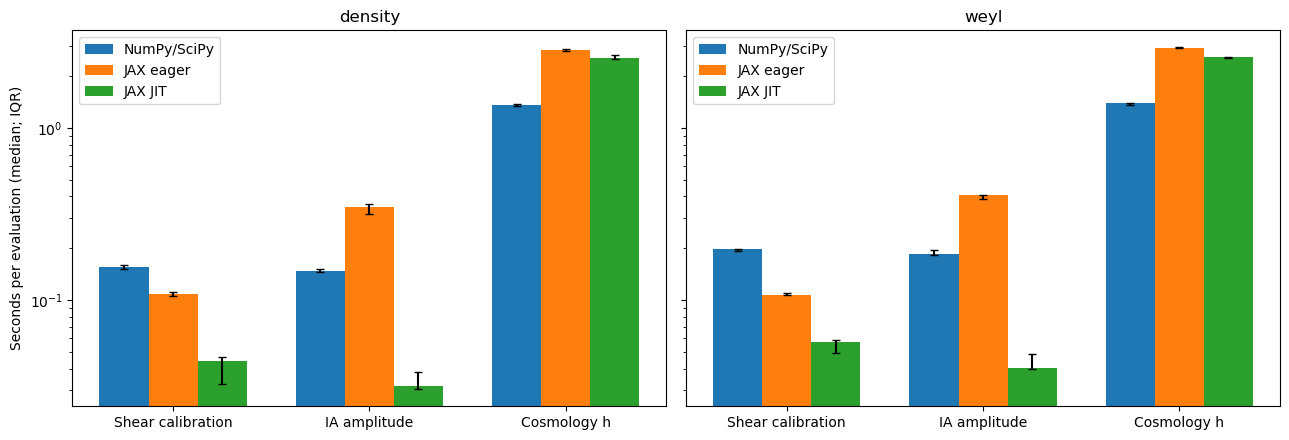

Measured on: macOS-15.8.1-arm64-arm-64bit CPU: arm devices: [CpuDevice(id=0)]
Thread limits: {'OMP_NUM_THREADS': '4', 'OPENBLAS_NUM_THREADS': '4', 'MKL_NUM_THREADS': '4'}
Versions: {'jax': '0.6.2', 'jaxlib': '0.6.2', 'interpax': '0.3.15', 'equinox': '0.13.8', 'numpy': '1.26.4', 'scipy': '1.14.0', 'camb': '1.5.8'}


3824

In [69]:
# Plot the three genuinely changing-input scenarios; exclude the cache-only case.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
scenario_names = [row[0] for row in SCENARIOS if row[1] is not None]
for ax, mode in zip(axes, ["density", "weyl"]):
    positions = np.arange(len(scenario_names))
    for offset, backend in zip([-0.25, 0, 0.25], ["NumPy/SciPy", "JAX eager", "JAX JIT"]):
        rows = (
            benchmark_timing[
                (benchmark_timing["mode"] == mode) & (benchmark_timing.backend == backend)
            ]
            .set_index("scenario")
            .loc[scenario_names]
        )
        ax.bar(positions + offset, rows.median_s, 0.25, label=backend)
        ax.errorbar(
            positions + offset,
            rows.median_s,
            yerr=np.stack([rows.median_s - rows.q25_s, rows.q75_s - rows.median_s]),
            fmt="none",
            ecolor="black",
            capsize=3,
        )
    ax.set_xticks(positions, ["Shear calibration", "IA amplitude", "Cosmology h"])
    ax.set_yscale("log")
    ax.set_title(mode)
    ax.legend()
axes[0].set_ylabel("Seconds per evaluation (median; IQR)")
fig.tight_layout()
fig.savefig(OUT / "jax_benchmark.png", dpi=150)
plt.show()
print("Measured on:", platform.platform(), "CPU:", platform.processor(), "devices:", jax.devices())
print(
    "Thread limits:",
    {
        name: os.environ.get(name)
        for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS")
    },
)
print("Versions:", VERSIONS)
benchmark_summary = dict(
    versions=VERSIONS,
    platform=platform.platform(),
    devices=[str(x) for x in jax.devices()],
    preparation=benchmark_preparation.to_dict("records"),
    speed=benchmark_speed.to_dict("records"),
    max_abs_timed_delta_chi2=float(
        benchmark_values[["JIT_minus_NumPy_chi2", "eager_minus_NumPy_chi2"]].abs().max().max()
    ),
    max_JIT_vs_eager_scaled=float(
        backend_accuracy[backend_accuracy.comparison == "JAX JIT vs eager"].max_scaled.max()
    ),
    interpretation="Warm timings exclude compilation. CAMB is cached only when cosmology is unchanged. NumPy/JIT speed includes graph caching and implementation differences; eager/JIT compares the same desilike implementation. Same-input rows measure cache overhead, not independent evaluation speed.",
)
(OUT / "jax_benchmark_summary.json").write_text(json.dumps(benchmark_summary, indent=2))


### 如何读速度表

`NumPy_over_JIT > 1` 表示 JIT 路径比原始实现快；`eager_over_JIT` 比较同一 desilike 的两种执行方式。`same_input_cache` 只表示缓存开销。首次调用含编译和外部节点准备，不是全新进程的冷启动。具体倍数以本次输出为准。

## 11. 完整观测量＋likelihood 的总耗时


一次调用返回全部实际使用的 bin pair 的 20 个角度点（ξ₊、ξ₋、γₜ、w）以及 log-likelihood。内部包含红移核、Limber / non-Limber 角功率谱、关联函数变换、点质量边缘化、3×2pt 与 shear-ratio likelihood。数据读取、静态矩阵准备与首次编译另列；计时同步读取全部输出到 NumPy。

**固定 CAMB**：联合改变 DzL1、DzS1、b1、AIA1、m1，使弱透镜理论与非 Limber 节点重算。**包含 CAMB**：改变 h，重算 CAMB、弱透镜理论和 likelihood。每个后端使用独立实例、相同输入序列；预热后重复 5 次，轮换执行顺序。不会分别重复计算一次 theory 和一次 likelihood，而是测量一次实际完整调用。

In [70]:
TOTAL_PAIRS = [
    sorted({(int(i), int(j)) for typ, i, j, _ in ref_no.used_items if typ == index})
    for index in range(len(TYPES))
]

TOTAL_PARAMS = {**BASE, **NUISANCE}

_total_seed = make_cosmo(BASE)

_total_seed_pipe = build(
    BaseDESY3Likelihood(theory=DESWeakLensing3x2pt(cosmo=_total_seed, Weyl=True), use_sr=True)
)

total_camb_template = _total_seed._cosmo.engine._camb_params.copy()


#### 完整调用的独立 CAMB provider

In [71]:
def total_provider(values):
    cp = total_camb_template.copy()
    cp.H0 = 100 * values["h"]
    cp.ombh2 = values["omega_b"]
    cp.omch2 = values["omega_cdm"]
    cp.InitPower.set_params(As=np.exp(values["logA"]) * 1e-10, ns=values["n_s"])
    cp.Reion.optical_depth = values["tau_reio"]
    cp.Transfer.kmax = 150 * values["h"]
    cp.YHe = camb.bbn.get_predictor().Y_He(
        values["omega_b"] * (camb.constants.COBE_CMBTemp / cp.TCMB) ** 3,
        FIXED["N_eff"] - camb.constants.default_nnu,
    )
    return CAMBProvider(camb.get_results(cp))


#### NumPy：一次返回观测量和 likelihood

In [72]:
class NumpyTotal:
    def __init__(self, weyl):
        self.ref = make_reference(weyl)
        self.cosmo_key = None
        original = self.ref.get_theory

        def capture(*args, **kwargs):
            result = original(*args, **kwargs)
            self.correlations = result
            return result

        self.ref.get_theory = capture  # one ordinary wrapper, no tracing or duplicate calculation

    def __call__(self, values):
        key = tuple(values[name] for name in BASE)
        if key != self.cosmo_key:
            self.ref.provider = total_provider(values)
            self.cosmo_key = key
        loglike = self.ref.logp(**{name: values[name] for name in NUISANCE})
        return dict(
            loglike=loglike,
            observables=np.concatenate(
                [
                    self.correlations[index][i, j]
                    for index, pairs in enumerate(TOTAL_PAIRS)
                    for i, j in pairs
                ]
            ),
        )


#### JAX：一次返回观测量和 likelihood

In [73]:
def total_jax_pipe(weyl):
    like = BaseDESY3Likelihood(
        theory=DESWeakLensing3x2pt(cosmo=make_cosmo(BASE), Weyl=weyl), use_sr=True
    )

    def output():
        return dict(
            loglike=like.logpdf,
            observables=jnp.concatenate(
                [
                    getattr(like.theory, name)[i, j]
                    for name, pairs in zip(TYPES, TOTAL_PAIRS)
                    for i, j in pairs
                ]
            ),
        )

    pipe = build(like, output=output)
    jax.tree_util.tree_map(np.asarray, output())
    return pipe


#### 计时终点：全部数组已计算完成

In [74]:
def total_timed(function, values):
    start = time.perf_counter()
    result = jax.tree_util.tree_map(
        np.asarray, function(values)
    )  # wait for ALL outputs, including transfer
    return time.perf_counter() - start, result


In [75]:
total_rows = []
total_checks = []
total_preparation = []


### 测量固定 CAMB 与 CAMB 重算

In [76]:
for mode, weyl in [("density", False), ("weyl", True)]:
    runners = {}
    for backend in ("NumPy/SciPy", "JAX eager", "JAX JIT"):
        start = time.perf_counter()
        runner = NumpyTotal(weyl) if backend == "NumPy/SciPy" else total_jax_pipe(weyl)
        if backend == "JAX JIT":
            runner = jax.jit(runner)
        setup = time.perf_counter() - start
        first, _ = total_timed(runner, TOTAL_PARAMS)
        total_preparation.append(
            dict(
                mode=mode,
                backend=backend,
                setup_s=setup,
                first_call_s=first,
                preparation_total_s=setup + first,
            )
        )
        runners[backend] = runner
    for scenario in ("fixed_CAMB_full_WL", "CAMB_plus_full_WL"):
        for runner in runners.values():
            total_timed(runner, TOTAL_PARAMS)
        for sample in range(5):
            values = TOTAL_PARAMS.copy()
            offset = (sample // 2 + 1) * (1 if sample % 2 == 0 else -1)
            if scenario == "fixed_CAMB_full_WL":
                for name, step in [
                    ("DES_DzL1", 0.001),
                    ("DES_DzS1", 0.001),
                    ("DES_b1", 0.01),
                    ("DES_AIA1", 0.02),
                    ("DES_m1", 0.002),
                ]:
                    values[name] += offset * step
            else:
                values["h"] += offset * 0.0005
            order = list(runners)
            order = order[sample % 3 :] + order[: sample % 3]
            predictions = {}
            for backend in order:
                elapsed, result = total_timed(runners[backend], values)
                predictions[backend] = result
                total_rows.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        sample=sample,
                        backend=backend,
                        seconds=elapsed,
                        loglike=float(result["loglike"]),
                        n_observable_values=result["observables"].size,
                    )
                )
            target = predictions["NumPy/SciPy"]
            for backend in ("JAX eager", "JAX JIT"):
                actual = predictions[backend]
                total_checks.append(
                    dict(
                        mode=mode,
                        scenario=scenario,
                        sample=sample,
                        backend=backend,
                        delta_chi2=-2 * float(actual["loglike"] - target["loglike"]),
                        **relative_metrics(actual["observables"], target["observables"])
                    )
                )
        print(mode, scenario, "complete", flush=True)
    # Save progress after each Weyl mode.
    pd.DataFrame(total_rows).to_csv(OUT / "jax_total_raw.csv", index=False)
    del runners, runner, predictions
    gc.collect()


density fixed_CAMB_full_WL complete


density CAMB_plus_full_WL complete


weyl fixed_CAMB_full_WL complete


weyl CAMB_plus_full_WL complete


### 总耗时和结果一致性

In [77]:
total_raw = pd.DataFrame(total_rows)
total_accuracy = pd.DataFrame(total_checks)
total_setup = pd.DataFrame(total_preparation)
total_timing = (
    total_raw.groupby(["mode", "scenario", "backend"])
    .seconds.agg(
        median_s="median",
        q25_s=lambda x: x.quantile(0.25),
        q75_s=lambda x: x.quantile(0.75),
        samples="size",
    )
    .reset_index()
)
total_speed = total_timing.pivot(
    index=["mode", "scenario"], columns="backend", values="median_s"
).reset_index()
total_speed["NumPy_over_JIT"] = total_speed["NumPy/SciPy"] / total_speed["JAX JIT"]
total_speed["eager_over_JIT"] = total_speed["JAX eager"] / total_speed["JAX JIT"]
assert total_accuracy.finite.all() and total_accuracy.max_scaled.max() < 1e-5
assert total_accuracy.delta_chi2.abs().max() < 1e-3
assert total_raw.n_observable_values.nunique() == 1
print("Returned correlation values per complete call:", total_raw.n_observable_values.iloc[0])
display(total_speed)
display(total_timing)
display(total_setup)
print("Maximum |delta chi2|:", total_accuracy.delta_chi2.abs().max())
for name, df in [
    ("timing", total_timing),
    ("speedup", total_speed),
    ("preparation", total_setup),
    ("accuracy", total_accuracy),
]:
    df.to_csv(OUT / f"jax_total_{name}.csv", index=False)
(OUT / "jax_total_summary.json").write_text(
    json.dumps(
        dict(
            versions=VERSIONS,
            speed=total_speed.to_dict("records"),
            preparation=total_setup.to_dict("records"),
            n_observable_values=int(total_raw.n_observable_values.iloc[0]),
            max_abs_delta_chi2=float(total_accuracy.delta_chi2.abs().max()),
            max_observable_scaled=float(total_accuracy.max_scaled.max()),
        ),
        indent=2,
    )
)


Returned correlation values per complete call: 640


backend,mode,scenario,JAX JIT,JAX eager,NumPy/SciPy,NumPy_over_JIT,eager_over_JIT
0,density,CAMB_plus_full_WL,2.559454,2.896512,1.372773,0.536354,1.131692
1,density,fixed_CAMB_full_WL,0.099918,0.419445,0.156409,1.565368,4.197880
2,weyl,CAMB_plus_full_WL,2.574948,2.987246,1.386980,0.538644,1.160119
3,weyl,fixed_CAMB_full_WL,0.109106,0.468874,0.185095,1.696473,4.297432


,mode,scenario,backend,median_s,q25_s,q75_s,samples
0,density,CAMB_plus_full_WL,JAX JIT,2.559454,2.558355,2.562921,5
1,density,CAMB_plus_full_WL,JAX eager,2.896512,2.890413,3.007454,5
2,density,CAMB_plus_full_WL,NumPy/SciPy,1.372773,1.362838,1.385116,5
3,density,fixed_CAMB_full_WL,JAX JIT,0.099918,0.099202,0.111931,5
4,density,fixed_CAMB_full_WL,JAX eager,0.419445,0.398741,0.420240,5
5,density,fixed_CAMB_full_WL,NumPy/SciPy,0.156409,0.155353,0.164682,5
6,weyl,CAMB_plus_full_WL,JAX JIT,2.574948,2.569221,2.684741,5
7,weyl,CAMB_plus_full_WL,JAX eager,2.987246,2.935183,3.064179,5
8,weyl,CAMB_plus_full_WL,NumPy/SciPy,1.386980,1.382973,1.417432,5
9,weyl,fixed_CAMB_full_WL,JAX JIT,0.109106,0.108531,0.109316,5


,mode,backend,setup_s,first_call_s,preparation_total_s
0,density,NumPy/SciPy,0.244035,1.598083,1.842118
1,density,JAX eager,3.548018,2.840715,6.388733
2,density,JAX JIT,3.461850,4.054193,7.516043
3,weyl,NumPy/SciPy,0.160977,1.436786,1.597763
4,weyl,JAX eager,3.715802,2.974105,6.689907
5,weyl,JAX JIT,3.585176,4.045944,7.631120


Maximum |delta chi2|: 8.713489364708948e-06


2617

### 两种总耗时的含义

- **固定 CAMB**：宇宙学不变；更新多个 nuisance 参数，重算弱透镜理论、non-Limber 和 likelihood。
- **CAMB 重算**：更新 h，从 CAMB 开始，一直算到观测量与 likelihood；更接近采样一个新宇宙学点的成本。

默认一次返回 640 个关联函数值与 log-likelihood。所有耗时以刚运行的表格为准，不在文字中写死旧结果。CSV、图和 JSON 均保存到 `OUT`。